In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def plot_retaining_wall(soil_type, density, beta_deg, phi_deg, c, bearing_cap, delta, 
                        water_table, gamma_c, gamma_s, gamma_sub, H, h_toe, mu, 
                        coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width):
    
    # ---------------------------------------------------------
    # 1. Geometry Formulas based on Excel logic
    # ---------------------------------------------------------
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    beta = np.radians(beta_deg)
    phi = np.radians(phi_deg)
    
    # Soil mass height from the back of the heel (H')
    H_prime = H + FG * np.tan(beta)
    
    # Rankine coefficients (using beta for both as per spreadsheet logic)
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = np.nan, np.nan  # Safety limit for inclination
        
    # Example Force Calculation Formulas (using gamma_s)
    Pa = 0.5 * gamma_s * (H**2) * Ka
    Pp = 0.5 * gamma_s * (h_toe**2) * Kp
    
    # ---------------------------------------------------------
    # 2. Sketch Coordinates setup
    # ---------------------------------------------------------
    # Concrete Cantilever Wall Profile
    # Points: Toe end -> Heel end -> Top of Heel Base -> Stem Back Bottom -> 
    #         Stem Back Top -> Stem Front Top -> Stem Front Bottom -> Top of Toe Base
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    # ---------------------------------------------------------
    # 3. Plotting
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Retaining Wall structure
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#b0bec5', label='Concrete Wall')
    
    # Plot Backfill Soil (Heel side)
    # Extends slightly right of the heel for visualization
    ax.plot([EF + DB, BC, BC + 2], [H, H_prime, H_prime + 2 * np.tan(beta)], color='#8d6e63', linewidth=2)
    ax.fill_between([EF + DB, BC, BC + 2], [DE, DE, DE], [H, H_prime, H_prime + 2 * np.tan(beta)], 
                    color='#d7ccc8', alpha=0.6, label='Backfill Soil')
                    
    # Plot Soil on Toe
    ax.plot([-2, EF], [DE + h_toe, DE + h_toe], color='#8d6e63', linewidth=2)
    ax.fill_between([-2, EF], [DE, DE], [DE + h_toe, DE + h_toe], 
                    color='#d7ccc8', alpha=0.6, label='Toe Soil')
                    
    # Plot Base Level
    ax.plot([-2, BC + 2], [0, 0], 'k--', linewidth=1, alpha=0.5)
    
    # Plot Water Table
    water_y = H - water_table
    if water_y > 0 and water_y <= H:
        ax.axhline(water_y, color='blue', linestyle='-.', label='Water Table', alpha=0.6)
        
    # Plot Settings
    ax.set_aspect('equal')
    ax.set_xlim([-1, BC + 2])
    ax.set_ylim([-0.5, max(H, H_prime) + 1.5])
    ax.set_xlabel('Width (m)')
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Retaining Wall Sketch ({soil_type} - {density} Density)', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Insert Dynamic Formula Calculation Information on the plot
    info_text = (f"Geometric Properties:\n"
                 f"Total Base (BC) = {BC:.2f} m\n"
                 f"Base Thick (DE) = {DE:.2f} m\n"
                 f"Toe Width (EF) = {EF:.2f} m\n"
                 f"Stem Base (DB) = {DB:.2f} m\n"
                 f"Heel Width (FG) = {FG:.2f} m\n"
                 f"Total Soil Height (H') = {H_prime:.2f} m\n\n"
                 f"Calculated Forces:\n"
                 f"Rankine Ka = {Ka:.4f}\n"
                 f"Rankine Kp = {Kp:.4f}\n"
                 f"Active Force (Pa) = {Pa:.2f} kN/m\n"
                 f"Passive Force (Pp) = {Pp:.2f} kN/m")
                 
    ax.text(1.05, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
            
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 4. Interactive UI Controls Initialization
# ---------------------------------------------------------
style = {'description_width': 'initial'}
ui = widgets.interact(
    plot_retaining_wall,
    soil_type=widgets.Dropdown(options=['CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'], value='CG', description='Soil type:', style=style),
    density=widgets.Dropdown(options=['Low', 'Medium', 'High'], value='Low', description='Density Type:', style=style),
    beta_deg=widgets.FloatSlider(value=15.0, min=0.0, max=30.0, step=1.0, description='Soil Inclination β (°):', style=style),
    phi_deg=widgets.FloatSlider(value=36.0, min=20.0, max=45.0, step=1.0, description='Friction Angle φ (°):', style=style),
    c=widgets.FloatText(value=0.0, description='Cohesion c:', style=style),
    bearing_cap=widgets.FloatText(value=392.4, description='Bearing Capacity:', style=style),
    delta=widgets.FloatText(value=24.0, description='Friction factor δ:', style=style),
    water_table=widgets.FloatText(value=0.0, description='Water table from top (m):', style=style),
    gamma_c=widgets.FloatText(value=24.0, description='γ Concrete (kN/m³):', style=style),
    gamma_s=widgets.FloatText(value=12.0, description='γ Soil (kN/m³):', style=style),
    gamma_sub=widgets.FloatText(value=11.0, description='γ submerged (kN/m³):', style=style),
    H=widgets.FloatSlider(value=7.0, min=3.0, max=12.0, step=0.1, description='Wall Height H (m):', style=style),
    h_toe=widgets.FloatSlider(value=0.6, min=0.0, max=2.0, step=0.1, description='Toe Soil Height h (m):', style=style),
    mu=widgets.FloatText(value=0.7, description='Friction str/soil µ:', style=style),
    coeff_BC=widgets.FloatSlider(value=0.6, min=0.4, max=1.0, step=0.05, description='Base Coeff (BC):', style=style),
    coeff_DE=widgets.FloatSlider(value=0.1, min=0.05, max=0.2, step=0.01, description='Thick Coeff (DE):', style=style),
    coeff_EF=widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Toe Coeff (EF):', style=style),
    coeff_DB=widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Stem Coeff (DB):', style=style),
    top_width=widgets.FloatSlider(value=0.3, min=0.2, max=0.8, step=0.05, description='Top Width (m):', style=style)
)

interactive(children=(Dropdown(description='Soil type:', options=('CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH')…

In [6]:
!pip install jupyterlab_widgets

In [7]:
jupyter nbextension enable --py widgetsnbextension --sys-prefix

SyntaxError: invalid syntax (4053252937.py, line 1)

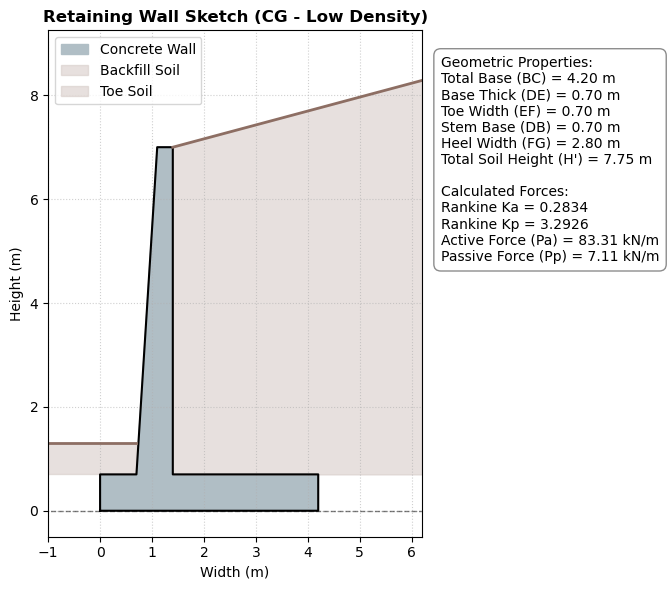

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_retaining_wall_static(soil_type='CG', density='Low', beta_deg=15.0, phi_deg=36.0, 
                        c=0.0, bearing_cap=392.4, delta=24.0, water_table=0.0, 
                        gamma_c=24.0, gamma_s=12.0, gamma_sub=11.0, H=7.0, h_toe=0.6, 
                        mu=0.7, coeff_BC=0.6, coeff_DE=0.1, coeff_EF=0.1, coeff_DB=0.1, 
                        top_width=0.3):
    
    # Geometry Formulas based on Excel logic
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    beta = np.radians(beta_deg)
    phi = np.radians(phi_deg)
    
    # Soil mass height from the back of the heel (H')
    H_prime = H + FG * np.tan(beta)
    
    # Rankine coefficients (using beta for both as per spreadsheet logic)
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = np.nan, np.nan 
        
    # Example Force Calculation Formulas
    Pa = 0.5 * gamma_s * (H**2) * Ka
    Pp = 0.5 * gamma_s * (h_toe**2) * Kp
    
    # Sketch Coordinates setup
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Retaining Wall structure
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#b0bec5', label='Concrete Wall')
    
    # Plot Backfill Soil (Heel side)
    ax.plot([EF + DB, BC, BC + 2], [H, H_prime, H_prime + 2 * np.tan(beta)], color='#8d6e63', linewidth=2)
    ax.fill_between([EF + DB, BC, BC + 2], [DE, DE, DE], [H, H_prime, H_prime + 2 * np.tan(beta)], 
                    color='#d7ccc8', alpha=0.6, label='Backfill Soil')
                    
    # Plot Soil on Toe
    ax.plot([-2, EF], [DE + h_toe, DE + h_toe], color='#8d6e63', linewidth=2)
    ax.fill_between([-2, EF], [DE, DE], [DE + h_toe, DE + h_toe], 
                    color='#d7ccc8', alpha=0.6, label='Toe Soil')
                    
    # Plot Base Level
    ax.plot([-2, BC + 2], [0, 0], 'k--', linewidth=1, alpha=0.5)
        
    # Plot Settings
    ax.set_aspect('equal')
    ax.set_xlim([-1, BC + 2])
    ax.set_ylim([-0.5, max(H, H_prime) + 1.5])
    ax.set_xlabel('Width (m)')
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Retaining Wall Sketch ({soil_type} - {density} Density)', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Insert Dynamic Formula Calculation Information on the plot
    info_text = (f"Geometric Properties:\n"
                 f"Total Base (BC) = {BC:.2f} m\n"
                 f"Base Thick (DE) = {DE:.2f} m\n"
                 f"Toe Width (EF) = {EF:.2f} m\n"
                 f"Stem Base (DB) = {DB:.2f} m\n"
                 f"Heel Width (FG) = {FG:.2f} m\n"
                 f"Total Soil Height (H') = {H_prime:.2f} m\n\n"
                 f"Calculated Forces:\n"
                 f"Rankine Ka = {Ka:.4f}\n"
                 f"Rankine Kp = {Kp:.4f}\n"
                 f"Active Force (Pa) = {Pa:.2f} kN/m\n"
                 f"Passive Force (Pp) = {Pp:.2f} kN/m")
                 
    ax.text(1.05, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
            
    plt.tight_layout()
    plt.show()

# Run the function once to draw the image statically
plot_retaining_wall_static()

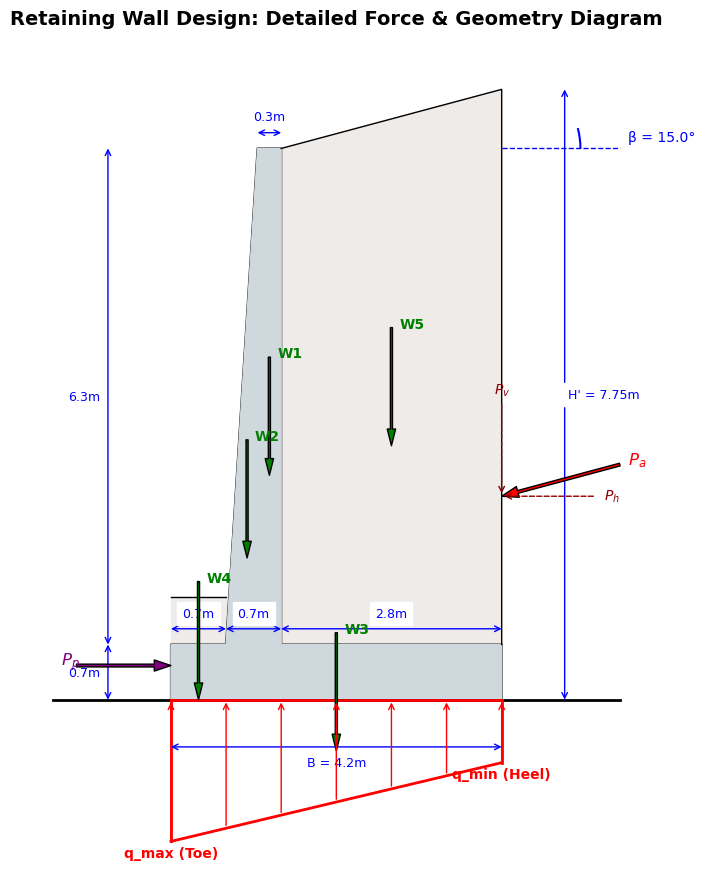

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_detailed_retaining_wall():
    # ---------------------------------------------------------
    # 1. Inputs & Geometry Parameters (from your Excel Data)
    # ---------------------------------------------------------
    H = 7.0               # Total height of retaining structure
    beta_deg = 15.0       # Soil inclination
    h_toe = 0.6           # Height of soil above the toe base
    
    BC = 4.2              # Total Base length
    DE = 0.7              # Base thickness
    EF = 0.7              # Toe width
    DB = 0.7              # Stem base width
    top_width = 0.3       # Top width of stem
    FG = BC - EF - DB     # Heel width (2.8m)
    
    beta = np.radians(beta_deg)
    H_prime = H + FG * np.tan(beta) # Total height of soil at the heel plane
    
    # ---------------------------------------------------------
    # 2. Setup Plot
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.set_aspect('equal')
    ax.axis('off') # Turn off standard grid for a clean engineering drawing
    
    # ---------------------------------------------------------
    # 3. Draw Main Structures
    # ---------------------------------------------------------
    # Concrete Wall Coordinates (Assuming vertical back face)
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    # Plot Concrete
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#cfd8dc', label='Concrete Wall', zorder=2)
    
    # Plot Backfill Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    # Plot Toe Soil
    ax.plot([0, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1)
    ax.fill_between([0, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    
    # Ground/Base Line
    ax.plot([-1.5, BC + 1.5], [0, 0], 'k-', linewidth=2)
    
    # ---------------------------------------------------------
    # 4. Draw Dimension Lines
    # ---------------------------------------------------------
    def draw_dim(x1, y1, x2, y2, text, offset_x=0, offset_y=0):
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2), 
                    arrowprops=dict(arrowstyle='<->', color='blue', shrinkA=0, shrinkB=0))
        ax.text((x1+x2)/2 + offset_x, (y1+y2)/2 + offset_y, text, 
                color='blue', ha='center', va='center', backgroundcolor='white', fontsize=9)

    # Horizontal Dimensions
    draw_dim(0, -0.6, BC, -0.6, f'B = {BC}m', offset_y=-0.2)
    draw_dim(0, DE+0.2, EF, DE+0.2, f'{EF}m', offset_y=0.2)
    draw_dim(EF, DE+0.2, EF+DB, DE+0.2, f'{DB}m', offset_y=0.2)
    draw_dim(EF+DB, DE+0.2, BC, DE+0.2, f'{FG}m', offset_y=0.2)
    draw_dim(EF+DB-top_width, H+0.2, EF+DB, H+0.2, f'{top_width}m', offset_y=0.2)
    
    # Vertical Dimensions
    draw_dim(-0.8, 0, -0.8, DE, f'{DE}m', offset_x=-0.3)
    draw_dim(-0.8, DE, -0.8, H, f'{H-DE}m', offset_x=-0.3)
    draw_dim(BC+0.8, 0, BC+0.8, H_prime, f"H' = {H_prime:.2f}m", offset_x=0.5)

    # ---------------------------------------------------------
    # 5. Draw Weight Vectors (W1 to W5)
    # ---------------------------------------------------------
    # Centroids (approximate for visual representation)
    cg_W_base = (BC/2, DE/2)
    cg_W_stem_rect = (EF + DB - top_width/2, DE + (H-DE)/2)
    cg_W_stem_tri = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    cg_W_heel_soil = (BC - FG/2, DE + (H_prime-DE)/2)
    cg_W_toe_soil = (EF/2, DE + h_toe/2)
    
    weights = {
        'W1': cg_W_stem_rect,
        'W2': cg_W_stem_tri,
        'W3': cg_W_base,
        'W4': cg_W_toe_soil,
        'W5': cg_W_heel_soil
    }
    
    for name, (cx, cy) in weights.items():
        ax.annotate('', xy=(cx, cy - 1), xytext=(cx, cy + 0.5),
                    arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
        ax.text(cx + 0.1, cy + 0.5, name, color='green', fontweight='bold')

    # ---------------------------------------------------------
    # 6. Draw Earth Pressure Vectors (Pa, Pp)
    # ---------------------------------------------------------
    # Active Earth Pressure (Pa) at H'/3 from base
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)),
                arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=8))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), r'$P_a$', color='red', fontsize=12, fontweight='bold')
    
    # Horizontal & Vertical components of Pa
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y),
                arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y, r'$P_h$', color='darkred', va='center')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2),
                arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC, Pa_y + 1.3, r'$P_v$', color='darkred', ha='center')

    # Passive Earth Pressure (Pp) at (DE+h_toe)/3
    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.2, Pp_y),
                arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=8))
    ax.text(-1.4, Pp_y, r'$P_p$', color='purple', fontsize=12, fontweight='bold')

    # Soil Angle Indicator (Beta)
    arc = patches.Arc((BC, H), 2, 2, theta1=0, theta2=beta_deg, color='blue', lw=1.5)
    ax.add_patch(arc)
    ax.plot([BC, BC+1.5], [H, H], 'b--', lw=1)
    ax.text(BC + 1.6, H + 0.1, f'β = {beta_deg}°', color='blue')

    # ---------------------------------------------------------
    # 7. Draw Base Bearing Pressure Distribution
    # ---------------------------------------------------------
    q_max_y, q_min_y = -1.8, -0.8 # arbitrary scale for visual representation
    
    # Pressure trapezoid outline
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [0, 0], 'r-', lw=2)
    
    # Pressure arrows pointing UP
    for x in np.linspace(0, BC, 7):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val),
                    arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.2, 'q_max (Toe)', color='red', ha='center', fontweight='bold')
    ax.text(BC, q_min_y - 0.2, 'q_min (Heel)', color='red', ha='center', fontweight='bold')

    plt.title("Retaining Wall Design: Detailed Force & Geometry Diagram", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Execute the function to draw the diagram
plot_detailed_retaining_wall()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

# --- Soil Database extracted from your Excel file ---
SOIL_DATA = {
    'CG (Well-Graded Sand/Gravel)': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL (Clay - Low Plasticity)': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH (Clay - High Plasticity)': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def plot_comprehensive_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Soil Properties automatically
    soil = SOIL_DATA[soil_type]
    gamma_s = soil['gamma']
    phi_deg = soil['phi']
    allowable_q = soil['bearing'][density]
    
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # 2. Geometry calculations
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations (W1 to W5)
    # W1: Stem Rectangular part
    W1 = top_width * (H - DE) * gamma_c
    cg_W1 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    # W2: Stem Triangular part
    W2 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W2 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    # W3: Base Slab
    W3 = BC * DE * gamma_c
    cg_W3 = (BC/2, DE/2)
    
    # W4: Toe Soil
    W4 = EF * h_toe * gamma_s
    cg_W4 = (EF/2, DE + h_toe/2)
    
    # W5: Heel Soil (Rectangle + Triangle)
    W5_rect = FG * (H - DE) * gamma_s
    W5_tri = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    W5 = W5_rect + W5_tri
    
    # Calculate Center of Gravity for Heel Soil (W5)
    if W5 > 0:
        x5_rect, y5_rect = EF + DB + FG/2, DE + (H-DE)/2
        x5_tri, y5_tri = EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3
        cg_x5 = (W5_rect * x5_rect + W5_tri * x5_tri) / W5
        cg_y5 = (W5_rect * y5_rect + W5_tri * y5_tri) / W5
    else:
        cg_x5, cg_y5 = EF + DB + FG/2, H
    cg_W5 = (cg_x5, cg_y5)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0 # Fallback if angle of repose is exceeded
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph = Pa * np.cos(beta)
    Pv = Pa * np.sin(beta)
    
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Bearing Pressure Calculations
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    
    # Moments about Toe (x=0)
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Wall Coordinates
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Backfill & Toe Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    ax.plot([0, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1)
    ax.fill_between([0, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    ax.plot([-2, BC + 2], [0, 0], 'k-', linewidth=2) # Base line

    # --- Draw Beta Angle at Top Width ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5) # Horizontal ref line
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 1.5, 1.5, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 0.8, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold')

    # --- Plot Forces W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.8), xytext=(cx, cy + 0.8),
                        arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.5, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9)

    # --- Plot Earth Pressures (Pa, Ph, Pv, Pp) ---
    Pa_y = H_prime / 3
    # Pa Vector
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)),
                arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN/m', color='red', fontweight='bold')
    
    # Ph & Pv Components
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=9)
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=9)

    # Pp Vector
    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y),
                arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN/m', color='purple', fontweight='bold', ha='right')

    # --- Plot Bearing Pressures ---
    q_max_y, q_min_y = -1.5, -0.5
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [0, 0], 'r-', lw=2)
    
    for x in np.linspace(0, BC, 6):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.4, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold')
    ax.text(BC, q_min_y - 0.4, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold')

    # Title & Data Info Box
    plt.title(f"Force & Pressure Diagram | Soil: {soil_type} ({density})", fontsize=15, fontweight='bold', pad=10)
    
    info_text = (f"Calculated Parameters:\n"
                 f"Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"Eccentricity (e): {e:.3f} m\n"
                 f"Base Width (B): {BC:.2f} m\n"
                 f"Soil Unit Wt (γ): {gamma_s} kN/m³\n"
                 f"Friction Angle (φ): {phi_deg}°")
    ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    plt.show()

# --- Create Interactive UI ---
style = {'description_width': 'initial'}
ui = widgets.interact(
    plot_comprehensive_wall,
    soil_type=widgets.Dropdown(options=list(SOIL_DATA.keys()), value='CG (Well-Graded Sand/Gravel)', description='Soil Type:', style=style),
    density=widgets.Dropdown(options=['Low', 'Medium', 'High'], value='Low', description='Density Type:', style=style),
    beta_deg=widgets.FloatSlider(value=15.0, min=0.0, max=30.0, step=1.0, description='Soil Angle β (°):', style=style),
    H=widgets.FloatSlider(value=7.0, min=3.0, max=12.0, step=0.1, description='Total Height H (m):', style=style),
    coeff_BC=widgets.FloatSlider(value=0.6, min=0.4, max=1.0, step=0.05, description='Base Coeff (BC):', style=style),
    coeff_DE=widgets.FloatSlider(value=0.1, min=0.05, max=0.2, step=0.01, description='Thick Coeff (DE):', style=style),
    coeff_EF=widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Toe Coeff (EF):', style=style),
    coeff_DB=widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Stem Coeff (DB):', style=style),
    top_width=widgets.FloatSlider(value=0.3, min=0.2, max=0.8, step=0.05, description='Stem Top (m):', style=style),
    h_toe=widgets.FloatSlider(value=0.6, min=0.0, max=2.0, step=0.1, description='Toe Soil h (m):', style=style),
    gamma_c=widgets.FloatText(value=24.0, description='Concrete γ (kN/m³):', style=style)
)

interactive(children=(Dropdown(description='Soil Type:', options=('CG (Well-Graded Sand/Gravel)', 'CG PF', 'CG…

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

# --- Soil Database extracted from your Excel file ---
SOIL_DATA = {
    'CG (Well-Graded Sand/Gravel)': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL (Clay - Low Plasticity)': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH (Clay - High Plasticity)': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def plot_comprehensive_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Soil Properties automatically
    soil = SOIL_DATA[soil_type]
    gamma_s = soil['gamma']
    phi_deg = soil['phi']
    allowable_q = soil['bearing'][density]
    
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # 2. Geometry calculations
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations (W1 to W5)
    # W1: Stem Rectangular part
    W1 = top_width * (H - DE) * gamma_c
    cg_W1 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    # W2: Stem Triangular part
    W2 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W2 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    # W3: Base Slab
    W3 = BC * DE * gamma_c
    cg_W3 = (BC/2, DE/2)
    
    # W4: Toe Soil
    W4 = EF * h_toe * gamma_s
    cg_W4 = (EF/2, DE + h_toe/2)
    
    # W5: Heel Soil (Rectangle + Triangle)
    W5_rect = FG * (H - DE) * gamma_s
    W5_tri = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    W5 = W5_rect + W5_tri
    
    # Calculate Center of Gravity for Heel Soil (W5)
    if W5 > 0:
        x5_rect, y5_rect = EF + DB + FG/2, DE + (H-DE)/2
        x5_tri, y5_tri = EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3
        cg_x5 = (W5_rect * x5_rect + W5_tri * x5_tri) / W5
        cg_y5 = (W5_rect * y5_rect + W5_tri * y5_tri) / W5
    else:
        cg_x5, cg_y5 = EF + DB + FG/2, H
    cg_W5 = (cg_x5, cg_y5)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0 # Fallback if angle of repose is exceeded
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph = Pa * np.cos(beta)
    Pv = Pa * np.sin(beta)
    
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Bearing Pressure Calculations
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    
    # Moments about Toe (x=0)
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Wall Coordinates
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Backfill & Toe Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    ax.plot([0, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1)
    ax.fill_between([0, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    ax.plot([-2, BC + 2], [0, 0], 'k-', linewidth=2) # Base line

    # --- Draw Beta Angle at Top Width ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5) # Horizontal ref line
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 1.5, 1.5, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 0.8, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold')

    # --- Plot Forces W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.8), xytext=(cx, cy + 0.8),
                        arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.5, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9)

    # --- Plot Earth Pressures (Pa, Ph, Pv, Pp) ---
    Pa_y = H_prime / 3
    # Pa Vector
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)),
                arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN/m', color='red', fontweight='bold')
    
    # Ph & Pv Components
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=9)
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=9)

    # Pp Vector
    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y),
                arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN/m', color='purple', fontweight='bold', ha='right')

    # --- Plot Bearing Pressures ---
    q_max_y, q_min_y = -1.5, -0.5
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [0, 0], 'r-', lw=2)
    
    for x in np.linspace(0, BC, 6):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.4, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold')
    ax.text(BC, q_min_y - 0.4, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold')

    # Title & Data Info Box
    plt.title(f"Force & Pressure Diagram | Soil: {soil_type} ({density})", fontsize=15, fontweight='bold', pad=10)
    
    info_text = (f"Calculated Parameters:\n"
                 f"Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"Eccentricity (e): {e:.3f} m\n"
                 f"Base Width (B): {BC:.2f} m\n"
                 f"Soil Unit Wt (γ): {gamma_s} kN/m³\n"
                 f"Friction Angle (φ): {phi_deg}°")
    ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    plt.show()

# --- Create Interactive UI ---
style = {'description_width': 'initial'}
ui = widgets.interact(
    plot_comprehensive_wall,
    soil_type=widgets.Dropdown(options=list(SOIL_DATA.keys()), value='CG (Well-Graded Sand/Gravel)', description='Soil Type:', style=style),
    density=widgets.Dropdown(options=['Low', 'Medium', 'High'], value='Low', description='Density Type:', style=style),
    beta_deg=widgets.FloatSlider(value=15.0, min=0.0, max=30.0, step=1.0, description='Soil Angle β (°):', style=style),
    H=widgets.FloatSlider(value=7.0, min=3.0, max=12.0, step=0.1, description='Total Height H (m):', style=style),
    coeff_BC=widgets.FloatSlider(value=0.6, min=0.4, max=1.0, step=0.05, description='Base Coeff (BC):', style=style),
    coeff_DE=widgets.FloatSlider(value=0.1, min=0.05, max=0.2, step=0.01, description='Thick Coeff (DE):', style=style),
    coeff_EF=widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Toe Coeff (EF):', style=style),
    coeff_DB=widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Stem Coeff (DB):', style=style),
    top_width=widgets.FloatSlider(value=0.3, min=0.2, max=0.8, step=0.05, description='Stem Top (m):', style=style),
    h_toe=widgets.FloatSlider(value=0.6, min=0.0, max=2.0, step=0.1, description='Toe Soil h (m):', style=style),
    gamma_c=widgets.FloatText(value=24.0, description='Concrete γ (kN/m³):', style=style)
)

interactive(children=(Dropdown(description='Soil Type:', options=('CG (Well-Graded Sand/Gravel)', 'CG PF', 'CG…

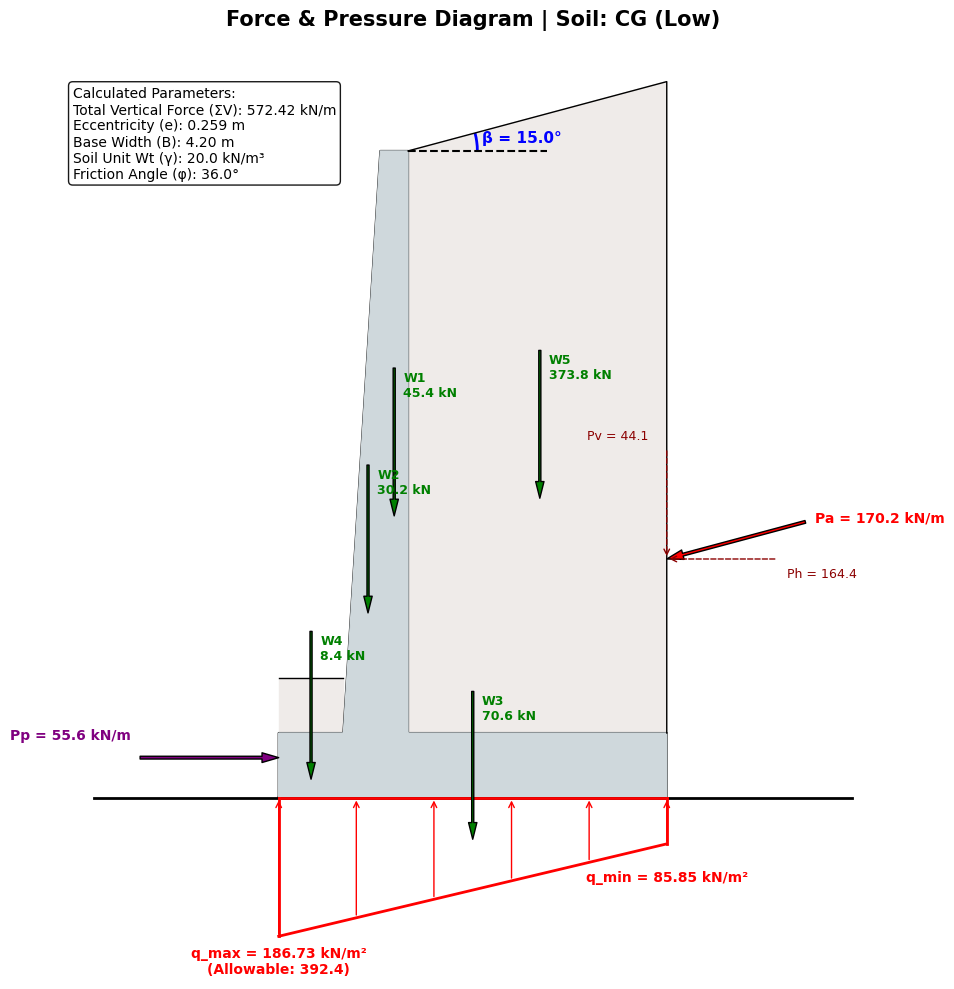

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database extracted from your Excel file ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Soil Properties automatically
    soil = SOIL_DATA[soil_type]
    gamma_s = soil['gamma']
    phi_deg = soil['phi']
    allowable_q = soil['bearing'][density]
    
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # 2. Geometry calculations
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations (W1 to W5)
    W1 = top_width * (H - DE) * gamma_c
    cg_W1 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    W2 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W2 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    W3 = BC * DE * gamma_c
    cg_W3 = (BC/2, DE/2)
    
    W4 = EF * h_toe * gamma_s
    cg_W4 = (EF/2, DE + h_toe/2)
    
    W5_rect = FG * (H - DE) * gamma_s
    W5_tri = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    W5 = W5_rect + W5_tri
    
    if W5 > 0:
        x5_rect, y5_rect = EF + DB + FG/2, DE + (H-DE)/2
        x5_tri, y5_tri = EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3
        cg_x5 = (W5_rect * x5_rect + W5_tri * x5_tri) / W5
        cg_y5 = (W5_rect * y5_rect + W5_tri * y5_tri) / W5
    else:
        cg_x5, cg_y5 = EF + DB + FG/2, H
    cg_W5 = (cg_x5, cg_y5)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph = Pa * np.cos(beta)
    Pv = Pa * np.sin(beta)
    
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Bearing Pressure Calculations
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Wall Coordinates
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Backfill & Toe Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    ax.plot([0, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1)
    ax.fill_between([0, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    ax.plot([-2, BC + 2], [0, 0], 'k-', linewidth=2)

    # --- Draw Beta Angle at Top Width ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 1.5, 1.5, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 0.8, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold')

    # --- Plot Forces W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.8), xytext=(cx, cy + 0.8),
                        arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.5, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9)

    # --- Plot Earth Pressures (Pa, Ph, Pv, Pp) ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)),
                arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN/m', color='red', fontweight='bold')
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=9)
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=9)

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y),
                arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN/m', color='purple', fontweight='bold', ha='right')

    # --- Plot Bearing Pressures ---
    q_max_y, q_min_y = -1.5, -0.5
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [0, 0], 'r-', lw=2)
    
    for x in np.linspace(0, BC, 6):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.4, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold')
    ax.text(BC, q_min_y - 0.4, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold')

    # Title & Data Info Box
    plt.title(f"Force & Pressure Diagram | Soil: {soil_type} ({density})", fontsize=15, fontweight='bold', pad=10)
    
    info_text = (f"Calculated Parameters:\n"
                 f"Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"Eccentricity (e): {e:.3f} m\n"
                 f"Base Width (B): {BC:.2f} m\n"
                 f"Soil Unit Wt (γ): {gamma_s} kN/m³\n"
                 f"Friction Angle (φ): {phi_deg}°")
    ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

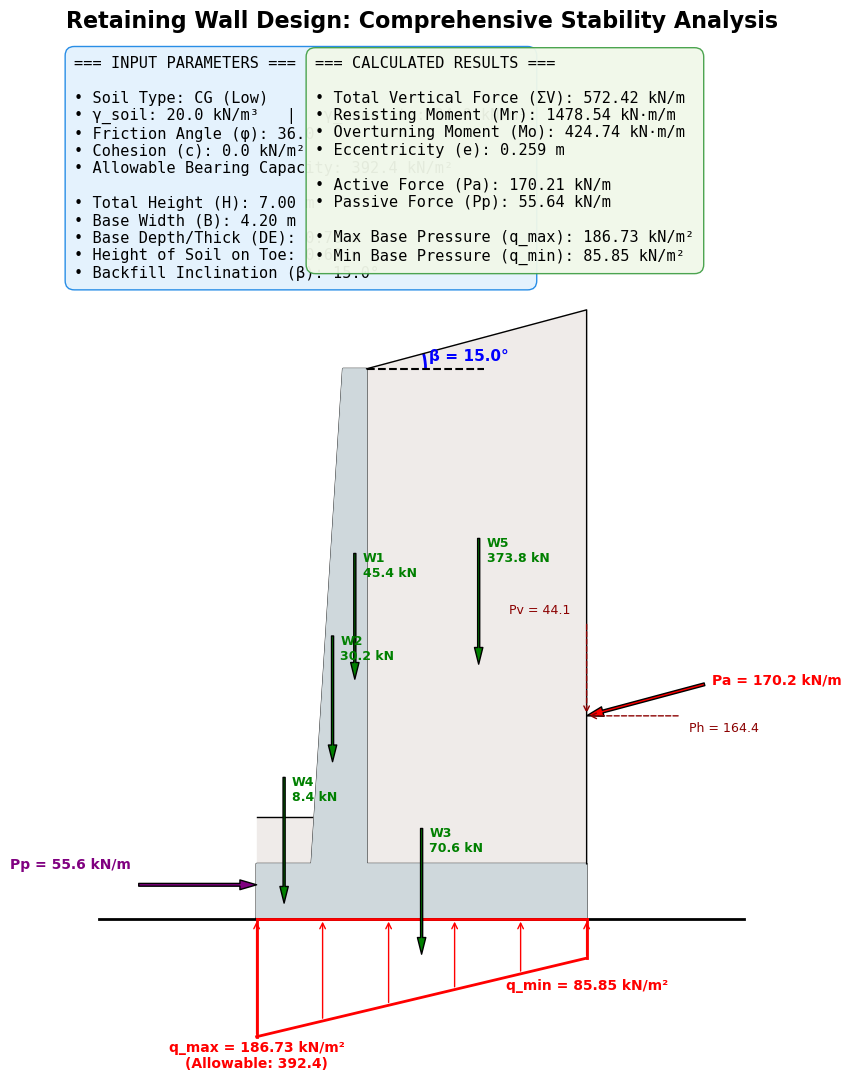

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database extracted from your Excel file ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Soil Properties automatically
    soil = SOIL_DATA[soil_type]
    gamma_s = soil['gamma']
    phi_deg = soil['phi']
    c_val = soil['c']
    allowable_q = soil['bearing'][density]
    
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # 2. Geometry calculations
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations (W1 to W5)
    W1 = top_width * (H - DE) * gamma_c
    cg_W1 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    W2 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W2 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    W3 = BC * DE * gamma_c
    cg_W3 = (BC/2, DE/2)
    
    W4 = EF * h_toe * gamma_s
    cg_W4 = (EF/2, DE + h_toe/2)
    
    W5_rect = FG * (H - DE) * gamma_s
    W5_tri = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    W5 = W5_rect + W5_tri
    
    if W5 > 0:
        x5_rect, y5_rect = EF + DB + FG/2, DE + (H-DE)/2
        x5_tri, y5_tri = EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3
        cg_x5 = (W5_rect * x5_rect + W5_tri * x5_tri) / W5
        cg_y5 = (W5_rect * y5_rect + W5_tri * y5_tri) / W5
    else:
        cg_x5, cg_y5 = EF + DB + FG/2, H
    cg_W5 = (cg_x5, cg_y5)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph = Pa * np.cos(beta)
    Pv = Pa * np.sin(beta)
    
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Bearing Pressure Calculations
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Extend the Y limit significantly to make room for the info boxes at the top
    ax.set_ylim([-2.0, max(H, H_prime) + 3.5])
    
    # Wall Coordinates
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Backfill & Toe Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    ax.plot([0, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1)
    ax.fill_between([0, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    ax.plot([-2, BC + 2], [0, 0], 'k-', linewidth=2)

    # --- Draw Beta Angle at Top Width ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 1.5, 1.5, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 0.8, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold')

    # --- Plot Forces W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.8), xytext=(cx, cy + 0.8),
                        arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.5, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9)

    # --- Plot Earth Pressures (Pa, Ph, Pv, Pp) ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)),
                arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN/m', color='red', fontweight='bold')
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=9)
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=9)

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y),
                arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN/m', color='purple', fontweight='bold', ha='right')

    # --- Plot Bearing Pressures ---
    q_max_y, q_min_y = -1.5, -0.5
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [0, 0], 'r-', lw=2)
    
    for x in np.linspace(0, BC, 6):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.4, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold')
    ax.text(BC, q_min_y - 0.4, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold')

    # ---------------------------------------------------------
    # 7. Add Data Info Boxes at the Top
    # ---------------------------------------------------------
    # Box 1: Input Parameters (Blue Box)
    input_text = (f"=== INPUT PARAMETERS ===\n\n"
                  f"• Soil Type: {soil_type} ({density})\n"
                  f"• γ_soil: {gamma_s} kN/m³   |   γ_concrete: {gamma_c} kN/m³\n"
                  f"• Friction Angle (φ): {phi_deg}°\n"
                  f"• Cohesion (c): {c_val} kN/m²\n"
                  f"• Allowable Bearing Capacity: {allowable_q} kN/m²\n\n"
                  f"• Total Height (H): {H:.2f} m\n"
                  f"• Base Width (B): {BC:.2f} m\n"
                  f"• Base Depth/Thick (DE): {DE:.2f} m\n"
                  f"• Height of Soil on Toe: {h_toe:.2f} m\n"
                  f"• Backfill Inclination (β): {beta_deg}°")
                  
    ax.text(0.01, 0.98, input_text, transform=ax.transAxes, fontsize=11, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#e3f2fd', edgecolor='#1e88e5', alpha=0.95))

    # Box 2: Calculated Results (Green Box)
    calc_text = (f"=== CALCULATED RESULTS ===\n\n"
                 f"• Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"• Resisting Moment (Mr): {M_R:.2f} kN·m/m\n"
                 f"• Overturning Moment (Mo): {M_O:.2f} kN·m/m\n"
                 f"• Eccentricity (e): {e:.3f} m\n\n"
                 f"• Active Force (Pa): {Pa:.2f} kN/m\n"
                 f"• Passive Force (Pp): {Pp:.2f} kN/m\n\n"
                 f"• Max Base Pressure (q_max): {q_max:.2f} kN/m²\n"
                 f"• Min Base Pressure (q_min): {q_min:.2f} kN/m²")
                 
    ax.text(0.35, 0.98, calc_text, transform=ax.transAxes, fontsize=11, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f1f8e9', edgecolor='#43a047', alpha=0.95))

    # Add Title above everything
    plt.title("Retaining Wall Design: Comprehensive Stability Analysis", fontsize=16, fontweight='bold', pad=20, y=0.98)

    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

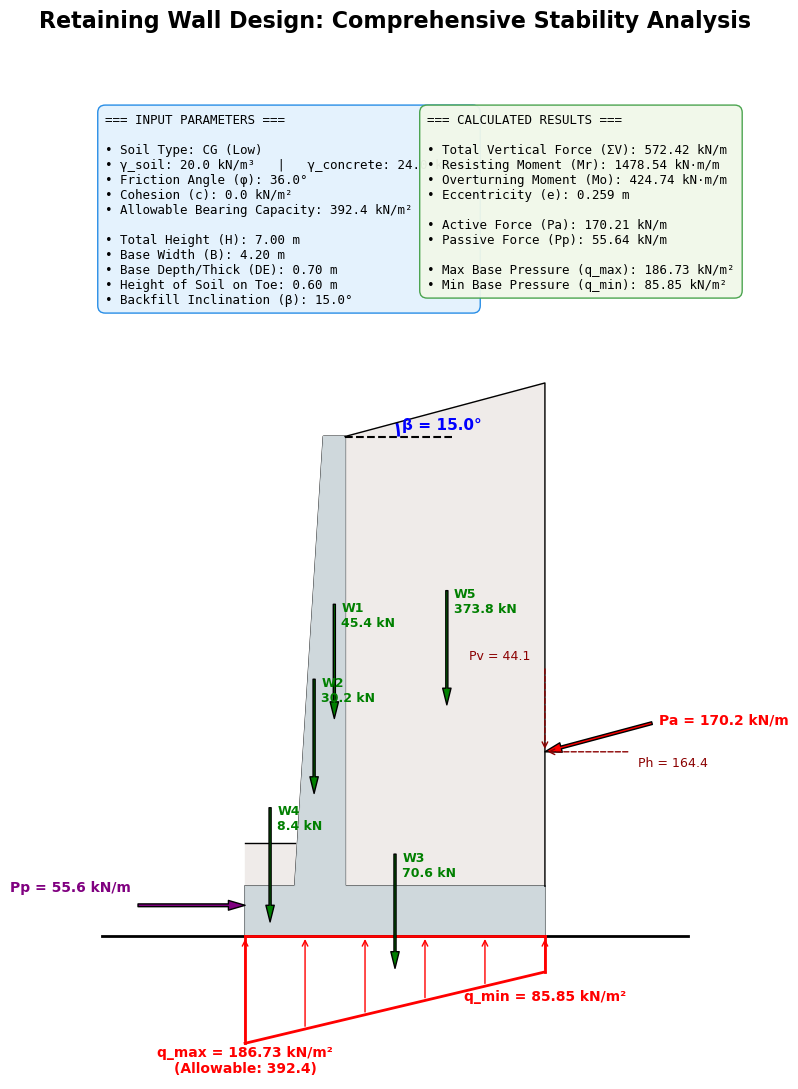

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database extracted from your Excel file ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Soil Properties automatically
    soil = SOIL_DATA[soil_type]
    gamma_s = soil['gamma']
    phi_deg = soil['phi']
    c_val = soil['c']
    allowable_q = soil['bearing'][density]
    
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # 2. Geometry calculations
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations (W1 to W5)
    W1 = top_width * (H - DE) * gamma_c
    cg_W1 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    W2 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W2 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    W3 = BC * DE * gamma_c
    cg_W3 = (BC/2, DE/2)
    
    W4 = EF * h_toe * gamma_s
    cg_W4 = (EF/2, DE + h_toe/2)
    
    W5_rect = FG * (H - DE) * gamma_s
    W5_tri = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    W5 = W5_rect + W5_tri
    
    if W5 > 0:
        x5_rect, y5_rect = EF + DB + FG/2, DE + (H-DE)/2
        x5_tri, y5_tri = EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3
        cg_x5 = (W5_rect * x5_rect + W5_tri * x5_tri) / W5
        cg_y5 = (W5_rect * y5_rect + W5_tri * y5_tri) / W5
    else:
        cg_x5, cg_y5 = EF + DB + FG/2, H
    cg_W5 = (cg_x5, cg_y5)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph = Pa * np.cos(beta)
    Pv = Pa * np.sin(beta)
    
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Bearing Pressure Calculations
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Provide a generous upper margin so boxes don't touch the diagram
    ax.set_ylim([-2.0, max(H, H_prime) + 4.5]) 
    
    # Wall Coordinates
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Backfill & Toe Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    ax.plot([0, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1)
    ax.fill_between([0, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    ax.plot([-2, BC + 2], [0, 0], 'k-', linewidth=2)

    # --- Draw Beta Angle at Top Width ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 1.5, 1.5, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 0.8, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold')

    # --- Plot Forces W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.8), xytext=(cx, cy + 0.8),
                        arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.5, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9)

    # --- Plot Earth Pressures (Pa, Ph, Pv, Pp) ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)),
                arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN/m', color='red', fontweight='bold')
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=9)
    
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=9)

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y),
                arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN/m', color='purple', fontweight='bold', ha='right')

    # --- Plot Bearing Pressures ---
    q_max_y, q_min_y = -1.5, -0.5
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [0, 0], 'r-', lw=2)
    
    for x in np.linspace(0, BC, 6):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.4, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold')
    ax.text(BC, q_min_y - 0.4, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold')

    # ---------------------------------------------------------
    # 7. Add Data Info Boxes at the Top (FIXED POSITIONING)
    # ---------------------------------------------------------
    # Box 1: Input Parameters (Blue Box) - Positioned far left
    input_text = (f"=== INPUT PARAMETERS ===\n\n"
                  f"• Soil Type: {soil_type} ({density})\n"
                  f"• γ_soil: {gamma_s} kN/m³   |   γ_concrete: {gamma_c} kN/m³\n"
                  f"• Friction Angle (φ): {phi_deg}°\n"
                  f"• Cohesion (c): {c_val} kN/m²\n"
                  f"• Allowable Bearing Capacity: {allowable_q} kN/m²\n\n"
                  f"• Total Height (H): {H:.2f} m\n"
                  f"• Base Width (B): {BC:.2f} m\n"
                  f"• Base Depth/Thick (DE): {DE:.2f} m\n"
                  f"• Height of Soil on Toe: {h_toe:.2f} m\n"
                  f"• Backfill Inclination (β): {beta_deg}°")
                  
    ax.text(0.05, 0.95, input_text, transform=ax.transAxes, fontsize=9, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#e3f2fd', edgecolor='#1e88e5', alpha=0.95))

    # Box 2: Calculated Results (Green Box) - Positioned right of center
    calc_text = (f"=== CALCULATED RESULTS ===\n\n"
                 f"• Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"• Resisting Moment (Mr): {M_R:.2f} kN·m/m\n"
                 f"• Overturning Moment (Mo): {M_O:.2f} kN·m/m\n"
                 f"• Eccentricity (e): {e:.3f} m\n\n"
                 f"• Active Force (Pa): {Pa:.2f} kN/m\n"
                 f"• Passive Force (Pp): {Pp:.2f} kN/m\n\n"
                 f"• Max Base Pressure (q_max): {q_max:.2f} kN/m²\n"
                 f"• Min Base Pressure (q_min): {q_min:.2f} kN/m²")
                 
    ax.text(0.55, 0.95, calc_text, transform=ax.transAxes, fontsize=9, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f1f8e9', edgecolor='#43a047', alpha=0.95))

    # Add Title with Standard Padding
    plt.title("Retaining Wall Design: Comprehensive Stability Analysis", fontsize=16, fontweight='bold', pad=25)

    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

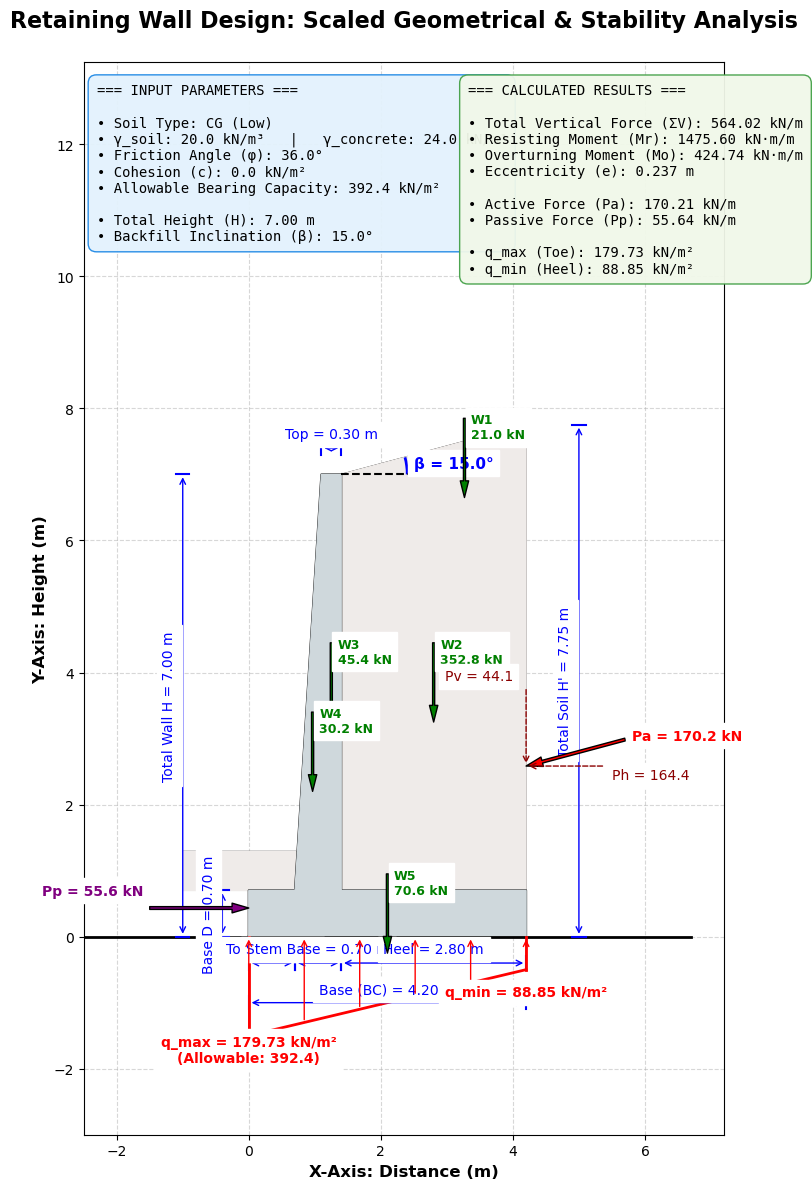

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Properties
    soil = SOIL_DATA[soil_type]
    gamma_s, phi_deg, c_val = soil['gamma'], soil['phi'], soil['c']
    allowable_q = soil['bearing'][density]
    
    phi, beta = np.radians(phi_deg), np.radians(beta_deg)
    
    # 2. Geometry
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations (REASSIGNED W1 - W5)
    
    # W1: Triangular Soil part on Heel
    W1 = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    cg_W1 = (EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3)
    
    # W2: Rectangular Soil part on Heel
    W2 = FG * (H - DE) * gamma_s
    cg_W2 = (EF + DB + FG/2, DE + (H-DE)/2)
    
    # W3: Stem Rectangular concrete
    W3 = top_width * (H - DE) * gamma_c
    cg_W3 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    # W4: Stem Triangular concrete
    W4 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W4 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    # W5: Base Slab concrete
    W5 = BC * DE * gamma_c
    cg_W5 = (BC/2, DE/2)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph, Pv = Pa * np.cos(beta), Pa * np.sin(beta)
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Moments
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram with Grid & Axes
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_aspect('equal')
    
    # Turn on axes and grid
    ax.set_axis_on()
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("X-Axis: Distance (m)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Y-Axis: Height (m)", fontsize=12, fontweight='bold')
    
    # Set proper plot limits to fit everything neatly
    ax.set_xlim([-2.5, BC + 3.0])
    ax.set_ylim([-3.0, max(H, H_prime) + 5.5])
    
    # Plot Wall
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5, zorder=2)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Plot Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1, zorder=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    # Plot Toe Soil
    ax.plot([-1, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1, zorder=1)
    ax.fill_between([-1, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    
    # Base Level Line
    ax.plot([-2.5, BC + 2.5], [0, 0], 'k-', linewidth=2, zorder=2)

    # ---------------------------------------------------------
    # 7. Dimension Lines Helper Functions
    # ---------------------------------------------------------
    def add_h_dim(x_start, x_end, y_pos, text):
        ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), arrowprops=dict(arrowstyle='<->', color='blue'))
        ax.plot([x_start, x_start], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        ax.plot([x_end, x_end], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        ax.text((x_start+x_end)/2, y_pos + 0.1, text, color='blue', ha='center', va='bottom', fontsize=10, backgroundcolor='white')

    def add_v_dim(x_pos, y_start, y_end, text):
        ax.annotate('', xy=(x_pos, y_start), xytext=(x_pos, y_end), arrowprops=dict(arrowstyle='<->', color='blue'))
        ax.plot([x_pos-0.1, x_pos+0.1], [y_start, y_start], 'b-', lw=1.5)
        ax.plot([x_pos-0.1, x_pos+0.1], [y_end, y_end], 'b-', lw=1.5)
        ax.text(x_pos - 0.1, (y_start+y_end)/2, text, color='blue', ha='right', va='center', rotation=90, fontsize=10, backgroundcolor='white')

    # Draw Horizontal Dimensions
    add_h_dim(0, BC, -1.0, f"Base (BC) = {BC:.2f} m")
    add_h_dim(0, EF, -0.4, f"Toe = {EF:.2f} m")
    add_h_dim(EF, EF+DB, -0.4, f"Stem Base = {DB:.2f} m")
    add_h_dim(EF+DB, BC, -0.4, f"Heel = {FG:.2f} m")
    add_h_dim(EF+DB-top_width, EF+DB, H + 0.4, f"Top = {top_width:.2f} m")

    # Draw Vertical Dimensions
    add_v_dim(-1.0, 0, H, f"Total Wall H = {H:.2f} m")
    add_v_dim(-0.4, 0, DE, f"Base D = {DE:.2f} m")
    add_v_dim(BC + 0.8, 0, H_prime, f"Total Soil H' = {H_prime:.2f} m")

    # --- Draw Beta Angle ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 2.0, 2.0, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 1.1, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold', backgroundcolor='white')

    # --- Plot Weights W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.6), xytext=(cx, cy + 0.6), arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.3, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9, backgroundcolor='white')

    # --- Plot Earth Pressures ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)), arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN', color='red', fontweight='bold', backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=10, backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=10, backgroundcolor='white')

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y), arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN', color='purple', fontweight='bold', ha='right', backgroundcolor='white')

    # --- Plot Bearing Pressures ---
    q_max_y, q_min_y = -1.5, -0.5
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [0, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [0, q_min_y], 'r-', lw=2)
    for x in np.linspace(0, BC, 6):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, 0), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.4, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold', backgroundcolor='white')
    ax.text(BC, q_min_y - 0.4, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold', backgroundcolor='white')

    # ---------------------------------------------------------
    # 8. Add Data Info Boxes at the Top
    # ---------------------------------------------------------
    input_text = (f"=== INPUT PARAMETERS ===\n\n"
                  f"• Soil Type: {soil_type} ({density})\n"
                  f"• γ_soil: {gamma_s} kN/m³   |   γ_concrete: {gamma_c} kN/m³\n"
                  f"• Friction Angle (φ): {phi_deg}°\n"
                  f"• Cohesion (c): {c_val} kN/m²\n"
                  f"• Allowable Bearing Capacity: {allowable_q} kN/m²\n\n"
                  f"• Total Height (H): {H:.2f} m\n"
                  f"• Backfill Inclination (β): {beta_deg}°")
                  
    ax.text(0.02, 0.98, input_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#e3f2fd', edgecolor='#1e88e5', alpha=0.95))

    calc_text = (f"=== CALCULATED RESULTS ===\n\n"
                 f"• Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"• Resisting Moment (Mr): {M_R:.2f} kN·m/m\n"
                 f"• Overturning Moment (Mo): {M_O:.2f} kN·m/m\n"
                 f"• Eccentricity (e): {e:.3f} m\n\n"
                 f"• Active Force (Pa): {Pa:.2f} kN/m\n"
                 f"• Passive Force (Pp): {Pp:.2f} kN/m\n\n"
                 f"• q_max (Toe): {q_max:.2f} kN/m²\n"
                 f"• q_min (Heel): {q_min:.2f} kN/m²")
                 
    ax.text(0.60, 0.98, calc_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f1f8e9', edgecolor='#43a047', alpha=0.95))

    plt.title("Retaining Wall Design: Scaled Geometrical & Stability Analysis", fontsize=16, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

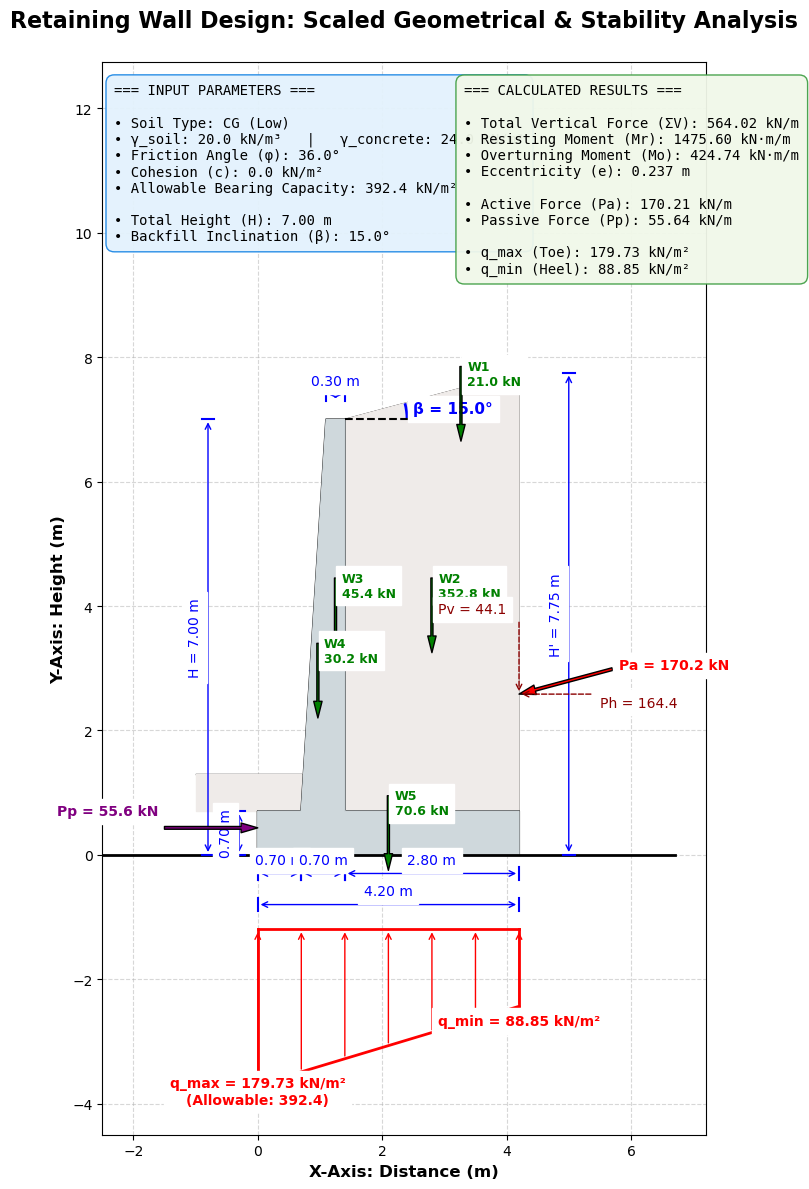

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Properties
    soil = SOIL_DATA[soil_type]
    gamma_s, phi_deg, c_val = soil['gamma'], soil['phi'], soil['c']
    allowable_q = soil['bearing'][density]
    
    phi, beta = np.radians(phi_deg), np.radians(beta_deg)
    
    # 2. Geometry
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations
    W1 = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    cg_W1 = (EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3)
    
    W2 = FG * (H - DE) * gamma_s
    cg_W2 = (EF + DB + FG/2, DE + (H-DE)/2)
    
    W3 = top_width * (H - DE) * gamma_c
    cg_W3 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    W4 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W4 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    W5 = BC * DE * gamma_c
    cg_W5 = (BC/2, DE/2)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph, Pv = Pa * np.cos(beta), Pa * np.sin(beta)
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Moments
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_aspect('equal')
    
    ax.set_axis_on()
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("X-Axis: Distance (m)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Y-Axis: Height (m)", fontsize=12, fontweight='bold')
    
    # Limits with extended bottom margin for proper scaled bearing pressure
    ax.set_xlim([-2.5, BC + 3.0])
    ax.set_ylim([-4.5, max(H, H_prime) + 5.0])
    
    # Plot Wall
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5, zorder=2)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Plot Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1, zorder=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    # Plot Toe Soil
    ax.plot([-1, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1, zorder=1)
    ax.fill_between([-1, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    
    # Base Level Line
    ax.plot([-2.5, BC + 2.5], [0, 0], 'k-', linewidth=2, zorder=2)

    # ---------------------------------------------------------
    # 7. Dimension Lines Helper Functions
    # ---------------------------------------------------------
    def add_h_dim(x_start, x_end, y_pos, text):
        ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), arrowprops=dict(arrowstyle='<->', color='blue'))
        ax.plot([x_start, x_start], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        ax.plot([x_end, x_end], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        ax.text((x_start+x_end)/2, y_pos + 0.1, text, color='blue', ha='center', va='bottom', fontsize=10, backgroundcolor='white')

    def add_v_dim(x_pos, y_start, y_end, text):
        ax.annotate('', xy=(x_pos, y_start), xytext=(x_pos, y_end), arrowprops=dict(arrowstyle='<->', color='blue'))
        ax.plot([x_pos-0.1, x_pos+0.1], [y_start, y_start], 'b-', lw=1.5)
        ax.plot([x_pos-0.1, x_pos+0.1], [y_end, y_end], 'b-', lw=1.5)
        ax.text(x_pos - 0.1, (y_start+y_end)/2, text, color='blue', ha='right', va='center', rotation=90, fontsize=10, backgroundcolor='white')

    # Draw Horizontal Dimensions (Values ONLY)
    add_h_dim(0, BC, -0.8, f"{BC:.2f} m")
    add_h_dim(0, EF, -0.3, f"{EF:.2f} m")
    add_h_dim(EF, EF+DB, -0.3, f"{DB:.2f} m")
    add_h_dim(EF+DB, BC, -0.3, f"{FG:.2f} m")
    add_h_dim(EF+DB-top_width, EF+DB, H + 0.4, f"{top_width:.2f} m")

    # Draw Vertical Dimensions (H and H' ONLY)
    add_v_dim(-0.8, 0, H, f"H = {H:.2f} m")
    add_v_dim(-0.3, 0, DE, f"{DE:.2f} m")
    add_v_dim(BC + 0.8, 0, H_prime, f"H' = {H_prime:.2f} m")

    # --- Draw Beta Angle ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 2.0, 2.0, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 1.1, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold', backgroundcolor='white')

    # --- Plot Weights W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.6), xytext=(cx, cy + 0.6), arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.3, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9, backgroundcolor='white')

    # --- Plot Earth Pressures ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)), arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN', color='red', fontweight='bold', backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=10, backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=10, backgroundcolor='white')

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y), arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN', color='purple', fontweight='bold', ha='right', backgroundcolor='white')

    # --- Plot True-to-Scale Bearing Pressures ---
    # Convert pressure units (kN/m2) to geometric scale (m) so it looks proportional on the plot
    # Using a scale where max pressure equals 2.5 meters on the visual plot
    p_scale = 2.5 / max(q_max, abs(q_min)) if q_max != 0 else 1
    
    q_max_y = -q_max * p_scale - 1.2 # Shifted slightly down below dimension lines
    q_min_y = -q_min * p_scale - 1.2
    
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [-1.2, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [-1.2, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [-1.2, -1.2], 'r-', lw=2) # Datum line for pressure
    
    for x in np.linspace(0, BC, 7):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, -1.2), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.3, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold', backgroundcolor='white')
    ax.text(BC, q_min_y - 0.3, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold', backgroundcolor='white')

    # ---------------------------------------------------------
    # 8. Add Data Info Boxes at the Top
    # ---------------------------------------------------------
    input_text = (f"=== INPUT PARAMETERS ===\n\n"
                  f"• Soil Type: {soil_type} ({density})\n"
                  f"• γ_soil: {gamma_s} kN/m³   |   γ_concrete: {gamma_c} kN/m³\n"
                  f"• Friction Angle (φ): {phi_deg}°\n"
                  f"• Cohesion (c): {c_val} kN/m²\n"
                  f"• Allowable Bearing Capacity: {allowable_q} kN/m²\n\n"
                  f"• Total Height (H): {H:.2f} m\n"
                  f"• Backfill Inclination (β): {beta_deg}°")
                  
    ax.text(0.02, 0.98, input_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#e3f2fd', edgecolor='#1e88e5', alpha=0.95))

    calc_text = (f"=== CALCULATED RESULTS ===\n\n"
                 f"• Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"• Resisting Moment (Mr): {M_R:.2f} kN·m/m\n"
                 f"• Overturning Moment (Mo): {M_O:.2f} kN·m/m\n"
                 f"• Eccentricity (e): {e:.3f} m\n\n"
                 f"• Active Force (Pa): {Pa:.2f} kN/m\n"
                 f"• Passive Force (Pp): {Pp:.2f} kN/m\n\n"
                 f"• q_max (Toe): {q_max:.2f} kN/m²\n"
                 f"• q_min (Heel): {q_min:.2f} kN/m²")
                 
    ax.text(0.60, 0.98, calc_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f1f8e9', edgecolor='#43a047', alpha=0.95))

    plt.title("Retaining Wall Design: Scaled Geometrical & Stability Analysis", fontsize=16, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

,Item,Value
0,Soil type,CG
1,Density type,Low
2,phi (deg),36.0
3,c (kN/m^2),0.0
4,gamma soil (kN/m^3),20.0
5,Bearing (kN/m^2),392.4
6,beta (deg),15
7,delta (deg),24.0
8,H (m),7
9,h toe (m),0.6


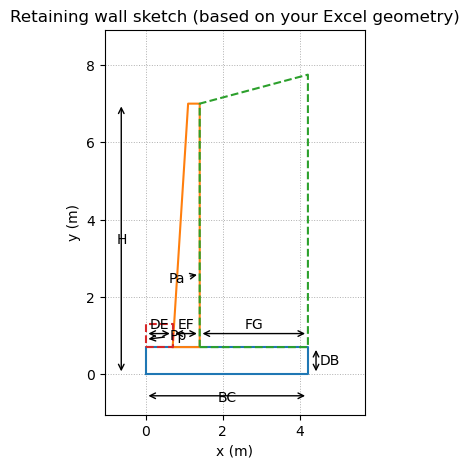

In [18]:
import math
import os
from dataclasses import dataclass, asdict
from typing import Optional, Dict, Any, Tuple

import pandas as pd
import matplotlib.pyplot as plt

try:
    import openpyxl
except ImportError as e:
    raise ImportError(
        "This notebook needs 'openpyxl' to read the Excel soil table.\n"
        "Install it with: pip install openpyxl"
    ) from e

try:
    from IPython.display import display, clear_output
except Exception:
    display = print
    clear_output = lambda **kwargs: None

GAMMA_W = 9.81  # kN/m^3 (unit weight of water)

# -----------------------------
# Soil database (read from Excel)
# -----------------------------
def _find_existing_path(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

def load_soil_database(
    excel_path: str,
    sheet_name: str = "Soil data",
    row_start: int = 3,
    row_end: int = 60,
) -> pd.DataFrame:
    """
    Reads the soil table in your Excel file (sheet: 'Soil data').

    Expected columns (from your file):
      G: soil type (code)
      H: unit weight gamma (kN/m^3)
      J: friction angle phi (deg)
      K: cohesion c (kN/m^2)
      P/Q/R: bearing capacity for Low/Medium/High density (kN/m^2)
    """
    wb = openpyxl.load_workbook(excel_path, data_only=True)
    if sheet_name not in wb.sheetnames:
        raise ValueError(f"Sheet '{sheet_name}' not found. Available: {wb.sheetnames}")

    ws = wb[sheet_name]
    records = []

    for r in range(row_start, row_end + 1):
        soil = ws[f"G{r}"].value
        if soil is None:
            continue
        soil = soil.strip() if isinstance(soil, str) else soil

        gamma = ws[f"H{r}"].value
        phi = ws[f"J{r}"].value
        c = ws[f"K{r}"].value

        b_low = ws[f"P{r}"].value
        b_med = ws[f"Q{r}"].value
        b_high = ws[f"R{r}"].value

        if gamma is None or phi is None or c is None:
            continue

        records.append(
            {
                "soil_type": soil,
                "gamma": float(gamma),
                "gamma_sub": float(gamma) - GAMMA_W,
                "phi": float(phi),
                "cohesion": float(c),
                "bearing_Low": None if b_low is None else float(b_low),
                "bearing_Medium": None if b_med is None else float(b_med),
                "bearing_High": None if b_high is None else float(b_high),
            }
        )

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No soil rows were read. Check the sheet layout in your Excel file.")
    return df.sort_values("soil_type").reset_index(drop=True)

# Try to locate the Excel file (works in local notebook and in ChatGPT notebook)
EXCEL_PATH = _find_existing_path(
    [
        "formula for retaining structure.xlsx",
        "./formula for retaining structure.xlsx",
        "/mnt/data/formula for retaining structure.xlsx",
    ]
)

if EXCEL_PATH is None:
    # Fallback: hard-code the soil table that appears in your file.
    soil_db = pd.DataFrame(
        [
            {"soil_type": "CG", "gamma": 20.0, "phi": 36.0, "cohesion": 0.0,
             "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8},
            {"soil_type": "CG PF", "gamma": 20.0, "phi": 29.0, "cohesion": 12.75,
             "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3},
            {"soil_type": "CG NPF", "gamma": 20.0, "phi": 30.0, "cohesion": 7.5,
             "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3},
            {"soil_type": "Silt", "gamma": 18.5, "phi": 25.0, "cohesion": 7.5,
             "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3},
            {"soil_type": "CL", "gamma": 17.5, "phi": 18.0, "cohesion": 12.75,
             "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4},
            {"soil_type": "CH", "gamma": 19.0, "phi": 15.0, "cohesion": 20.0,
             "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4},
            {"soil_type": "Boulder", "gamma": 20.0, "phi": 60.0, "cohesion": 0.0,
             "bearing_Low": None, "bearing_Medium": None, "bearing_High": None},
        ]
    )
    soil_db["gamma_sub"] = soil_db["gamma"] - GAMMA_W
else:
    soil_db = load_soil_database(EXCEL_PATH)

DENSITY_OPTIONS = ["Low", "Medium", "High"]

def soil_lookup(soil_type: str, density_type: str) -> Dict[str, Any]:
    density_type = density_type.strip().title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    match = soil_db[soil_db["soil_type"] == soil_type]
    if match.empty:
        raise ValueError(f"Soil type '{soil_type}' not found in the soil database.")

    row = match.iloc[0].to_dict()
    row["bearing"] = row.get(f"bearing_{density_type}", None)
    row["density_type"] = density_type
    return row

# -----------------------------
# Retaining wall model (same structure as your Excel sheet)
# -----------------------------
@dataclass(frozen=True)
class WallInputs:
    soil_type: str = "CG"
    density_type: str = "Low"

    beta_deg: float = 15.0   # backfill slope angle beta (deg)
    H: float = 7.0           # total height from base bottom to wall top (m)
    h_toe: float = 0.6       # soil height in toe part used for passive (m)

    gamma_concrete: float = 24.0  # kN/m^3

    # Geometry coefficients (Excel uses these)
    BC_coef: float = 0.6     # BC = X*H
    DE_coef: float = 0.1     # DE = c_coef*H
    EF_coef: float = 0.1     # EF = d_coef*H
    DB_coef: float = 0.1     # DB = 0.1*H (base thickness)

    top_width: float = 0.3   # m

    # δ handling (Excel sets δ = 2/3*phi)
    delta_mode: str = "2/3_phi"   # "2/3_phi" or "manual"
    delta_deg_manual: Optional[float] = None

    # Overrides (if you want to enter values directly instead of soil table)
    phi_override: Optional[float] = None        # degrees
    cohesion_override: Optional[float] = None   # kN/m^2
    gamma_override: Optional[float] = None      # kN/m^3
    bearing_override: Optional[float] = None    # kN/m^2

    # In your sheet this exists, but formulas did not use it.
    # Here it is used for drawing only.
    water_table_from_top: float = 0.0  # m

def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    """
    Rankine Ka and Kp for sloping backfill:
    Ka = cosβ * (cosβ - sqrt(cos^2β - cos^2φ)) / (cosβ + sqrt(cos^2β - cos^2φ))
    Kp = cosβ * (cosβ + sqrt(cos^2β - cos^2φ)) / (cosβ - sqrt(cos^2β - cos^2φ))

    Requires beta <= phi.
    """
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2
    if term_sq < 0:
        raise ValueError(
            f"Invalid angles: need beta <= phi. Got beta={beta_deg}°, phi={phi_deg}°."
        )
    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp

def compute_wall(inputs: WallInputs) -> Dict[str, Any]:
    soil = soil_lookup(inputs.soil_type, inputs.density_type)

    phi = inputs.phi_override if inputs.phi_override is not None else soil["phi"]
    c = inputs.cohesion_override if inputs.cohesion_override is not None else soil["cohesion"]
    gamma = inputs.gamma_override if inputs.gamma_override is not None else soil["gamma"]
    bearing = inputs.bearing_override if inputs.bearing_override is not None else soil.get("bearing", None)

    # δ
    if inputs.delta_mode == "2/3_phi":
        delta_deg = (2.0 / 3.0) * phi
    elif inputs.delta_mode == "manual":
        if inputs.delta_deg_manual is None:
            raise ValueError("delta_deg_manual must be set when delta_mode='manual'.")
        delta_deg = float(inputs.delta_deg_manual)
    else:
        raise ValueError("delta_mode must be '2/3_phi' or 'manual'.")

    # Geometry
    H = float(inputs.H)
    DB = inputs.DB_coef * H
    BC = inputs.BC_coef * H
    DE = inputs.DE_coef * H
    EF = inputs.EF_coef * H
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError(
            f"Geometry invalid: FG must be positive. Got FG={FG:.3f} m. "
            f"Try larger BC_coef or smaller DE/EF."
        )

    beta_rad = math.radians(inputs.beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    # Rankine coefficients
    Ka, Kp = rankine_Ka_Kp_sloping(inputs.beta_deg, phi)

    # Weights (kN/m)
    W1 = 0.5 * (H_prime - H) * FG * gamma
    W2 = FG * (H - DB) * gamma
    W3 = inputs.top_width * (H - DB) * inputs.gamma_concrete
    W4 = 0.5 * (H - DB) * (EF - inputs.top_width) * inputs.gamma_concrete
    W5 = DB * BC * inputs.gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active/Passive forces (kN/m) (same form as your sheet)
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    Pp = 0.5 * Kp * gamma * (inputs.h_toe**2) + 2.0 * c * math.sqrt(Kp) * inputs.h_toe

    # Components
    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe (kN·m per m length)
    M_W1 = W1 * (FG * 2 / 3 + DE + EF)
    M_W2 = W2 * (FG / 2 + DE + EF)
    M_W3 = W3 * (DE + (EF - inputs.top_width) + inputs.top_width / 2)
    M_W4 = W4 * (DE + (EF - inputs.top_width) * 2 / 3)
    M_W5 = W5 * (BC / 2)
    M_Pv = Pv * BC  # same simplification as Excel

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0  # Excel uses H' / 3

    FS_overturning = float("inf") if Mo == 0 else Mr / Mo

    # Sliding
    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = float("inf") if driving == 0 else resisting / driving

    # Bearing
    V = W_total + Pv
    e = (BC / 2.0) - (Mr - Mo) / V
    pmax = (V / BC) * (1.0 + 6.0 * e / BC)
    pmin = (V / BC) * (1.0 - 6.0 * e / BC)

    FS_bearing = None
    if bearing is not None and not (isinstance(bearing, float) and math.isnan(bearing)):
        FS_bearing = float(bearing) / max(pmax, pmin)

    return {
        "inputs": asdict(inputs),
        "soil": soil,
        "phi": phi,
        "cohesion": c,
        "gamma_soil": gamma,
        "bearing_allow": bearing,
        "delta_deg": delta_deg,
        "BC": BC, "DE": DE, "EF": EF, "FG": FG, "DB": DB, "H_prime": H_prime,
        "Ka": Ka, "Kp": Kp,
        "W1": W1, "W2": W2, "W3": W3, "W4": W4, "W5": W5, "W_total": W_total,
        "Pa": Pa, "Pp": Pp, "Ph": Ph, "Pv": Pv,
        "Mr": Mr, "Mo": Mo,
        "FS_overturning": FS_overturning,
        "FS_sliding": FS_sliding,
        "V_total": V,
        "eccentricity_e": e,
        "pmax": pmax, "pmin": pmin,
        "FS_bearing": FS_bearing,
    }

def summarize_results(results: Dict[str, Any]) -> pd.DataFrame:
    rows = [
        ("Soil type", results["soil"]["soil_type"]),
        ("Density type", results["soil"]["density_type"]),
        ("phi (deg)", results["phi"]),
        ("c (kN/m^2)", results["cohesion"]),
        ("gamma soil (kN/m^3)", results["gamma_soil"]),
        ("Bearing (kN/m^2)", results["bearing_allow"]),
        ("beta (deg)", results["inputs"]["beta_deg"]),
        ("delta (deg)", results["delta_deg"]),
        ("H (m)", results["inputs"]["H"]),
        ("h toe (m)", results["inputs"]["h_toe"]),
        ("BC (m)", results["BC"]),
        ("DE (m)", results["DE"]),
        ("EF (m)", results["EF"]),
        ("FG (m)", results["FG"]),
        ("DB (m)", results["DB"]),
        ("H' (m)", results["H_prime"]),
        ("Ka", results["Ka"]),
        ("Kp", results["Kp"]),
        ("Pa (kN/m)", results["Pa"]),
        ("Pp (kN/m)", results["Pp"]),
        ("Ph (kN/m)", results["Ph"]),
        ("Pv (kN/m)", results["Pv"]),
        ("FS overturning", results["FS_overturning"]),
        ("FS sliding", results["FS_sliding"]),
        ("eccentricity e (m)", results["eccentricity_e"]),
        ("pmax (kN/m^2)", results["pmax"]),
        ("pmin (kN/m^2)", results["pmin"]),
        ("FS bearing", results["FS_bearing"]),
    ]
    return pd.DataFrame(rows, columns=["Item", "Value"])

# -----------------------------
# Plotting (diagram sketch)
# -----------------------------
def plot_wall(
    inputs: WallInputs,
    results: Optional[Dict[str, Any]] = None,
    show_forces: bool = True,
    show_dimensions: bool = True,
    ax=None,
):
    if results is None:
        results = compute_wall(inputs)

    BC = results["BC"]
    DB = results["DB"]
    DE = results["DE"]
    EF = results["EF"]
    FG = results["FG"]
    H = inputs.H
    H_prime = results["H_prime"]
    top = inputs.top_width
    beta = math.radians(inputs.beta_deg)

    # Key points (m)
    B = (0.0, 0.0)
    C = (BC, 0.0)
    D = (0.0, DB)
    G = (BC, DB)
    E = (DE, DB)
    F = (DE + EF, DB)

    A_back = (DE + EF, H)          # back face top
    A_front = (DE + EF - top, H)   # front face top

    soil_top_back = (DE + EF, H)
    soil_top_heel = (BC, H_prime)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    # Base slab outline
    ax.plot([B[0], C[0], G[0], D[0], B[0]],
            [B[1], C[1], G[1], D[1], B[1]])

    # Stem outline
    ax.plot([E[0], F[0], A_back[0], A_front[0], E[0]],
            [E[1], F[1], A_back[1], A_front[1], E[1]])

    # Backfill (soil) outline
    ax.plot([F[0], G[0], soil_top_heel[0], soil_top_back[0], F[0]],
            [F[1], G[1], soil_top_heel[1], soil_top_back[1], F[1]],
            linestyle="--")

    # Toe-side soil block (sketch only)
    toe_soil_h = inputs.h_toe
    ax.plot([B[0], E[0], E[0], B[0], B[0]],
            [D[1], D[1], D[1] + toe_soil_h, D[1] + toe_soil_h, D[1]],
            linestyle="--")

    # Water table (draw only)
    if inputs.water_table_from_top is not None and inputs.water_table_from_top > 0:
        y_wt = max(0.0, H - float(inputs.water_table_from_top))
        ax.plot([F[0], BC], [y_wt, y_wt], linestyle=":")

    # Forces
    if show_forces:
        # Active force arrow around H'/3
        y_act = H_prime / 3.0
        x_act = F[0]
        Pa = results["Pa"]
        if abs(Pa) > 1e-9:
            L = 0.2 * BC
            dx = -L * math.cos(beta)
            dy = -L * math.sin(beta)
            ax.annotate("Pa", xy=(x_act, y_act), xytext=(x_act + dx, y_act + dy),
                        arrowprops=dict(arrowstyle="->"))

        # Passive force arrow near toe (to the right)
        x_pp, y_pp = 0.0, DB + toe_soil_h / 3.0
        Pp = results["Pp"]
        if abs(Pp) > 1e-9:
            L = 0.15 * BC
            ax.annotate("Pp", xy=(x_pp, y_pp), xytext=(x_pp + L, y_pp),
                        arrowprops=dict(arrowstyle="->"))

    # Dimensions
    if show_dimensions:
        ax.annotate("", xy=(-0.15 * BC, 0), xytext=(-0.15 * BC, H),
                    arrowprops=dict(arrowstyle="<->"))
        ax.text(-0.18 * BC, H / 2, "H", va="center")

        ax.annotate("", xy=(0, -0.08 * H), xytext=(BC, -0.08 * H),
                    arrowprops=dict(arrowstyle="<->"))
        ax.text(BC / 2, -0.1 * H, "BC", ha="center")

        ax.annotate("", xy=(BC * 1.05, 0), xytext=(BC * 1.05, DB),
                    arrowprops=dict(arrowstyle="<->"))
        ax.text(BC * 1.07, DB / 2, "DB", va="center")

        y_dim = DB + 0.05 * H
        ax.annotate("", xy=(0, y_dim), xytext=(DE, y_dim),
                    arrowprops=dict(arrowstyle="<->"))
        ax.text(DE / 2, y_dim + 0.02 * H, "DE", ha="center")

        ax.annotate("", xy=(DE, y_dim), xytext=(DE + EF, y_dim),
                    arrowprops=dict(arrowstyle="<->"))
        ax.text(DE + EF / 2, y_dim + 0.02 * H, "EF", ha="center")

        ax.annotate("", xy=(DE + EF, y_dim), xytext=(BC, y_dim),
                    arrowprops=dict(arrowstyle="<->"))
        ax.text(DE + EF + FG / 2, y_dim + 0.02 * H, "FG", ha="center")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("Retaining wall sketch (based on your Excel geometry)")
    ax.set_xlim(-0.25 * BC, BC * 1.35)
    ax.set_ylim(-0.15 * H, max(H_prime, H) * 1.15)
    ax.grid(True, linestyle=":", linewidth=0.7)
    return fig, ax

# -----------------------------
# Run once (no widgets)
# -----------------------------
inp = WallInputs(soil_type="CG", density_type="Low", beta_deg=15, H=7, h_toe=0.6)
res = compute_wall(inp)
display(summarize_results(res))
plot_wall(inp, res)
plt.show()

# -----------------------------
# Optional: interactive "options" (Dropdown / sliders)
# -----------------------------
def show_interactive():
    try:
        import ipywidgets as widgets
    except Exception:
        print("ipywidgets not installed. Install with: pip install ipywidgets")
        return

    soil_dd = widgets.Dropdown(
        options=sorted(soil_db["soil_type"].unique()),
        value=sorted(soil_db["soil_type"].unique())[0],
        description="Soil",
    )
    dens_dd = widgets.Dropdown(options=DENSITY_OPTIONS, value="Low", description="Density")

    beta = widgets.FloatSlider(value=15, min=0, max=35, step=1, description="beta (deg)")
    H = widgets.FloatSlider(value=7, min=1, max=15, step=0.1, description="H (m)")
    h_toe = widgets.FloatSlider(value=0.6, min=0, max=3, step=0.05, description="h_toe (m)")

    BCc = widgets.FloatSlider(value=0.6, min=0.3, max=1.0, step=0.05, description="BC/H")
    DEc = widgets.FloatSlider(value=0.1, min=0.05, max=0.4, step=0.05, description="DE/H")
    EFc = widgets.FloatSlider(value=0.1, min=0.05, max=0.6, step=0.05, description="EF/H")
    DBc = widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description="DB/H")

    topw = widgets.FloatSlider(value=0.3, min=0.1, max=1.0, step=0.05, description="top (m)")
    wt = widgets.FloatSlider(value=0.0, min=0.0, max=15.0, step=0.1, description="WT from top")

    out = widgets.Output()

    def _update(*args):
        with out:
            clear_output(wait=True)
            try:
                i = WallInputs(
                    soil_type=soil_dd.value,
                    density_type=dens_dd.value,
                    beta_deg=beta.value,
                    H=H.value,
                    h_toe=h_toe.value,
                    BC_coef=BCc.value,
                    DE_coef=DEc.value,
                    EF_coef=EFc.value,
                    DB_coef=DBc.value,
                    top_width=topw.value,
                    water_table_from_top=wt.value,
                )
                r = compute_wall(i)
                display(summarize_results(r))
                plot_wall(i, r)
                plt.show()
            except Exception as e:
                print("Error:", e)

    for w in [soil_dd, dens_dd, beta, H, h_toe, BCc, DEc, EFc, DBc, topw, wt]:
        w.observe(_update, "value")

    controls = widgets.VBox(
        [
            widgets.HBox([soil_dd, dens_dd]),
            beta, H, h_toe,
            widgets.HBox([BCc, DEc, EFc, DBc]),
            widgets.HBox([topw, wt]),
        ]
    )
    display(controls, out)
    _update()

# Uncomment this line to run the interactive UI:
# show_interactive()


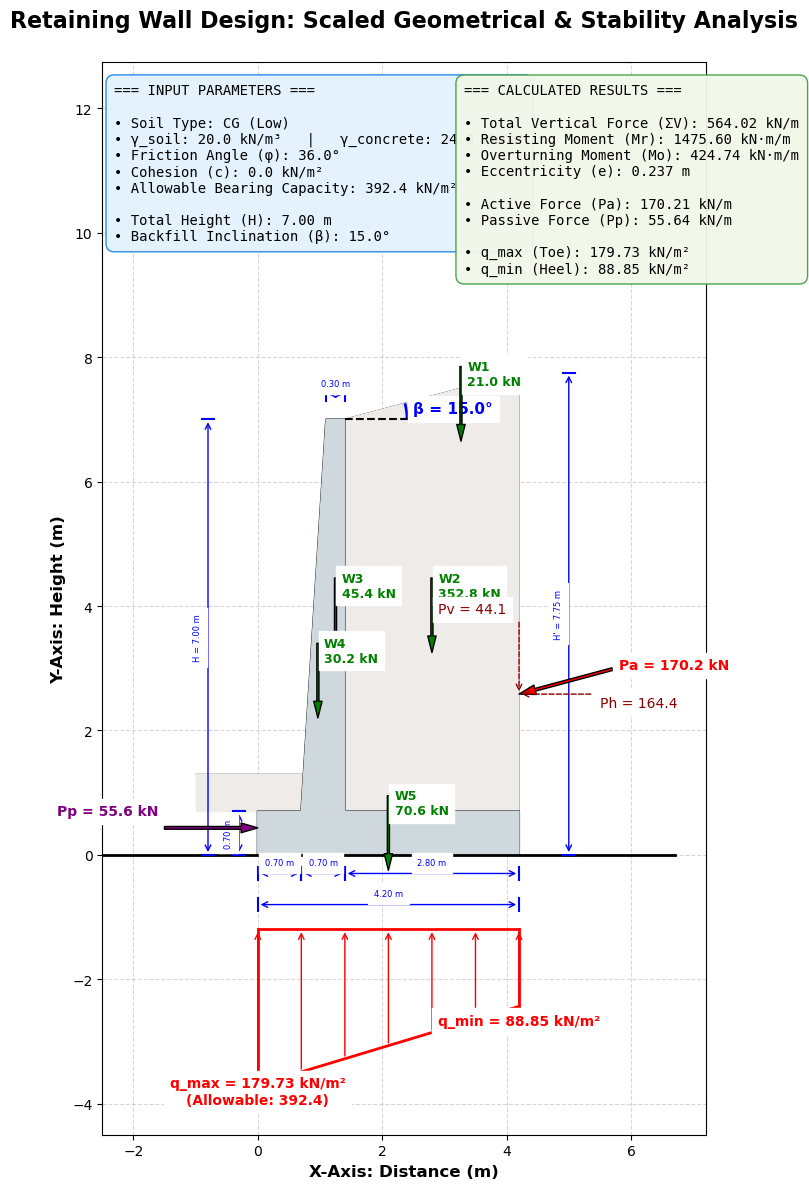

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Properties
    soil = SOIL_DATA[soil_type]
    gamma_s, phi_deg, c_val = soil['gamma'], soil['phi'], soil['c']
    allowable_q = soil['bearing'][density]
    
    phi, beta = np.radians(phi_deg), np.radians(beta_deg)
    
    # 2. Geometry
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations
    W1 = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    cg_W1 = (EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3)
    
    W2 = FG * (H - DE) * gamma_s
    cg_W2 = (EF + DB + FG/2, DE + (H-DE)/2)
    
    W3 = top_width * (H - DE) * gamma_c
    cg_W3 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    W4 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W4 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    W5 = BC * DE * gamma_c
    cg_W5 = (BC/2, DE/2)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph, Pv = Pa * np.cos(beta), Pa * np.sin(beta)
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Moments
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_aspect('equal')
    
    ax.set_axis_on()
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("X-Axis: Distance (m)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Y-Axis: Height (m)", fontsize=12, fontweight='bold')
    
    # Limits with extended bottom margin for proper scaled bearing pressure
    ax.set_xlim([-2.5, BC + 3.0])
    ax.set_ylim([-4.5, max(H, H_prime) + 5.0])
    
    # Plot Wall
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5, zorder=2)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Plot Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1, zorder=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    # Plot Toe Soil
    ax.plot([-1, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1, zorder=1)
    ax.fill_between([-1, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    
    # Base Level Line
    ax.plot([-2.5, BC + 2.5], [0, 0], 'k-', linewidth=2, zorder=2)

    # ---------------------------------------------------------
    # 7. Dimension Lines Helper Functions (REDUCED FONT SIZE)
    # ---------------------------------------------------------
    def add_h_dim(x_start, x_end, y_pos, text):
        ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), arrowprops=dict(arrowstyle='<->', color='blue', lw=1))
        ax.plot([x_start, x_start], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        ax.plot([x_end, x_end], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        # Fontsize reduced to 6
        ax.text((x_start+x_end)/2, y_pos + 0.1, text, color='blue', ha='center', va='bottom', fontsize=6, backgroundcolor='white')

    def add_v_dim(x_pos, y_start, y_end, text):
        ax.annotate('', xy=(x_pos, y_start), xytext=(x_pos, y_end), arrowprops=dict(arrowstyle='<->', color='blue', lw=1))
        ax.plot([x_pos-0.1, x_pos+0.1], [y_start, y_start], 'b-', lw=1.5)
        ax.plot([x_pos-0.1, x_pos+0.1], [y_end, y_end], 'b-', lw=1.5)
        # Fontsize reduced to 6
        ax.text(x_pos - 0.1, (y_start+y_end)/2, text, color='blue', ha='right', va='center', rotation=90, fontsize=6, backgroundcolor='white')

    # Draw Horizontal Dimensions (Values ONLY)
    add_h_dim(0, BC, -0.8, f"{BC:.2f} m")
    add_h_dim(0, EF, -0.3, f"{EF:.2f} m")
    add_h_dim(EF, EF+DB, -0.3, f"{DB:.2f} m")
    add_h_dim(EF+DB, BC, -0.3, f"{FG:.2f} m")
    add_h_dim(EF+DB-top_width, EF+DB, H + 0.4, f"{top_width:.2f} m")

    # Draw Vertical Dimensions (H and H' ONLY)
    add_v_dim(-0.8, 0, H, f"H = {H:.2f} m")
    add_v_dim(-0.3, 0, DE, f"{DE:.2f} m")
    add_v_dim(BC + 0.8, 0, H_prime, f"H' = {H_prime:.2f} m")

    # --- Draw Beta Angle ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 2.0, 2.0, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 1.1, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold', backgroundcolor='white')

    # --- Plot Weights W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.6), xytext=(cx, cy + 0.6), arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.3, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9, backgroundcolor='white')

    # --- Plot Earth Pressures ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)), arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN', color='red', fontweight='bold', backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=10, backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=10, backgroundcolor='white')

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y), arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN', color='purple', fontweight='bold', ha='right', backgroundcolor='white')

    # --- Plot True-to-Scale Bearing Pressures ---
    # Convert pressure units (kN/m2) to geometric scale (m) so it looks proportional on the plot
    p_scale = 2.5 / max(q_max, abs(q_min)) if q_max != 0 else 1
    
    q_max_y = -q_max * p_scale - 1.2 # Shifted slightly down below dimension lines
    q_min_y = -q_min * p_scale - 1.2
    
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [-1.2, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [-1.2, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [-1.2, -1.2], 'r-', lw=2) # Datum line for pressure
    
    for x in np.linspace(0, BC, 7):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, -1.2), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.3, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold', backgroundcolor='white')
    ax.text(BC, q_min_y - 0.3, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold', backgroundcolor='white')

    # ---------------------------------------------------------
    # 8. Add Data Info Boxes at the Top
    # ---------------------------------------------------------
    input_text = (f"=== INPUT PARAMETERS ===\n\n"
                  f"• Soil Type: {soil_type} ({density})\n"
                  f"• γ_soil: {gamma_s} kN/m³   |   γ_concrete: {gamma_c} kN/m³\n"
                  f"• Friction Angle (φ): {phi_deg}°\n"
                  f"• Cohesion (c): {c_val} kN/m²\n"
                  f"• Allowable Bearing Capacity: {allowable_q} kN/m²\n\n"
                  f"• Total Height (H): {H:.2f} m\n"
                  f"• Backfill Inclination (β): {beta_deg}°")
                  
    ax.text(0.02, 0.98, input_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#e3f2fd', edgecolor='#1e88e5', alpha=0.95))

    calc_text = (f"=== CALCULATED RESULTS ===\n\n"
                 f"• Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"• Resisting Moment (Mr): {M_R:.2f} kN·m/m\n"
                 f"• Overturning Moment (Mo): {M_O:.2f} kN·m/m\n"
                 f"• Eccentricity (e): {e:.3f} m\n\n"
                 f"• Active Force (Pa): {Pa:.2f} kN/m\n"
                 f"• Passive Force (Pp): {Pp:.2f} kN/m\n\n"
                 f"• q_max (Toe): {q_max:.2f} kN/m²\n"
                 f"• q_min (Heel): {q_min:.2f} kN/m²")
                 
    ax.text(0.60, 0.98, calc_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f1f8e9', edgecolor='#43a047', alpha=0.95))

    plt.title("Retaining Wall Design: Scaled Geometrical & Stability Analysis", fontsize=16, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

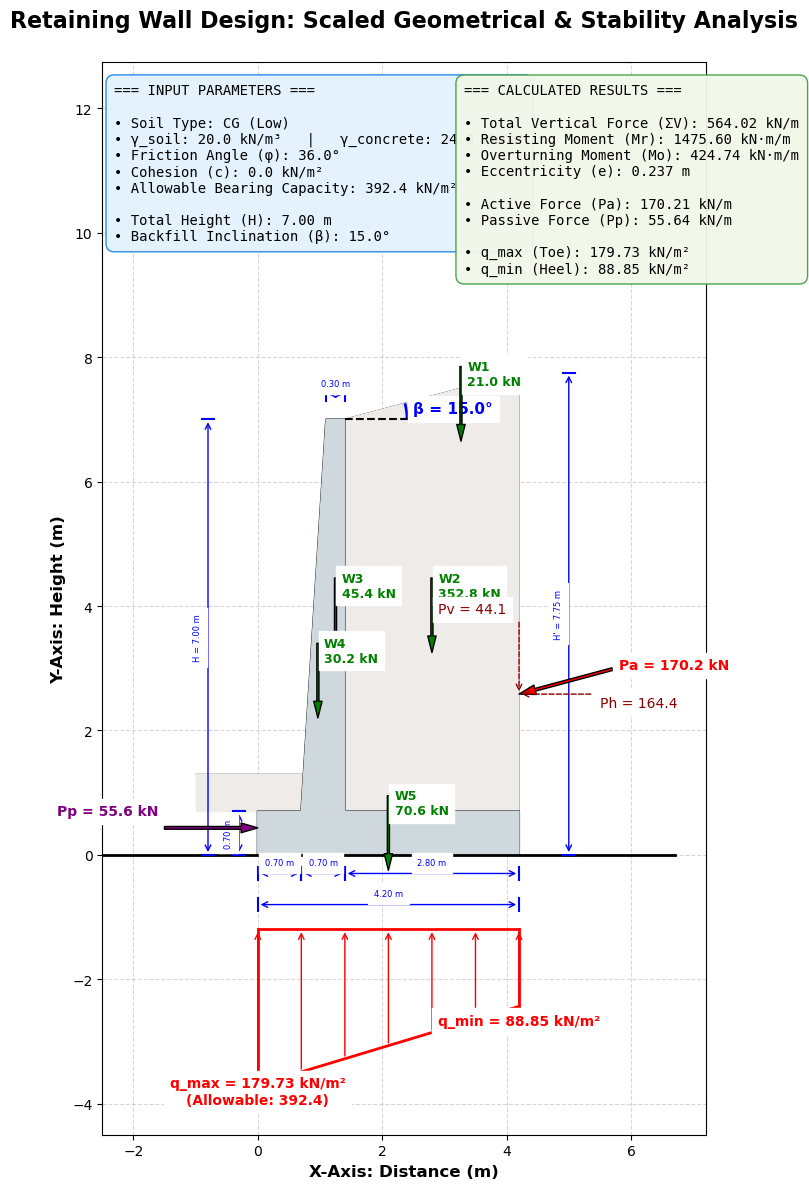

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Soil Database ---
SOIL_DATA = {
    'CG': {'gamma': 20.0, 'phi': 36.0, 'c': 0.0, 'bearing': {'Low': 392.4, 'Medium': 588.6, 'High': 784.8}},
    'CG PF': {'gamma': 20.0, 'phi': 29.0, 'c': 12.75, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'CG NPF': {'gamma': 20.0, 'phi': 30.0, 'c': 7.5, 'bearing': {'Low': 147.15, 'Medium': 245.25, 'High': 294.3}},
    'Silt': {'gamma': 18.5, 'phi': 25.0, 'c': 7.5, 'bearing': {'Low': 49.05, 'Medium': 147.15, 'High': 294.3}},
    'CL': {'gamma': 17.5, 'phi': 18.0, 'c': 12.75, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}},
    'CH': {'gamma': 19.0, 'phi': 15.0, 'c': 20.0, 'bearing': {'Low': 49.05, 'Medium': 196.2, 'High': 392.4}}
}

def draw_retaining_wall(soil_type, density, beta_deg, H, coeff_BC, coeff_DE, coeff_EF, coeff_DB, top_width, h_toe, gamma_c):
    
    # 1. Fetch Properties
    soil = SOIL_DATA[soil_type]
    gamma_s, phi_deg, c_val = soil['gamma'], soil['phi'], soil['c']
    allowable_q = soil['bearing'][density]
    
    phi, beta = np.radians(phi_deg), np.radians(beta_deg)
    
    # 2. Geometry
    BC = coeff_BC * H
    DE = coeff_DE * H
    EF = coeff_EF * H
    DB = coeff_DB * H
    FG = BC - EF - DB
    H_prime = H + FG * np.tan(beta)
    
    # 3. Force & Weight Calculations
    W1 = 0.5 * FG * (FG * np.tan(beta)) * gamma_s
    cg_W1 = (EF + DB + 2*FG/3, H + (FG*np.tan(beta))/3)
    
    W2 = FG * (H - DE) * gamma_s
    cg_W2 = (EF + DB + FG/2, DE + (H-DE)/2)
    
    W3 = top_width * (H - DE) * gamma_c
    cg_W3 = (EF + DB - top_width/2, DE + (H-DE)/2)
    
    W4 = 0.5 * (DB - top_width) * (H - DE) * gamma_c
    cg_W4 = (EF + 2/3 * (DB - top_width), DE + (H-DE)/3)
    
    W5 = BC * DE * gamma_c
    cg_W5 = (BC/2, DE/2)

    # 4. Earth Pressure Calculations
    if phi_deg > beta_deg:
        term1 = np.cos(beta)
        term2 = np.sqrt(np.cos(beta)**2 - np.cos(phi)**2)
        Ka = term1 * (term1 - term2) / (term1 + term2)
        Kp = term1 * (term1 + term2) / (term1 - term2)
    else:
        Ka, Kp = 0, 0
        
    Pa = 0.5 * gamma_s * (H_prime**2) * Ka
    Ph, Pv = Pa * np.cos(beta), Pa * np.sin(beta)
    Pp = 0.5 * gamma_s * ((h_toe + DE)**2) * Kp
    
    # 5. Stability & Moments
    Sum_V = W1 + W2 + W3 + W4 + W5 + Pv
    M_R = (W1*cg_W1[0] + W2*cg_W2[0] + W3*cg_W3[0] + W4*cg_W4[0] + W5*cg_W5[0] + Pv*BC)
    M_O = Ph * (H_prime / 3)
    
    x_bar = (M_R - M_O) / Sum_V if Sum_V != 0 else 0
    e = (BC / 2) - x_bar
    q_max = (Sum_V / BC) * (1 + (6 * e) / BC)
    q_min = (Sum_V / BC) * (1 - (6 * e) / BC)

    # ---------------------------------------------------------
    # 6. Plotting the Diagram
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_aspect('equal')
    
    ax.set_axis_on()
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("X-Axis: Distance (m)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Y-Axis: Height (m)", fontsize=12, fontweight='bold')
    
    # Limits with extended bottom margin for proper scaled bearing pressure
    ax.set_xlim([-2.5, BC + 3.0])
    ax.set_ylim([-4.5, max(H, H_prime) + 5.0])
    
    # Plot Wall
    wall_x = [0, BC, BC, EF + DB, EF + DB, EF + DB - top_width, EF, 0, 0]
    wall_y = [0, 0,  DE, DE,      H,       H,                   DE, DE, 0]
    ax.plot(wall_x, wall_y, 'k-', linewidth=1.5, zorder=2)
    ax.fill(wall_x, wall_y, color='#cfd8dc', zorder=2)
    
    # Plot Soil
    soil_x = [EF + DB, BC, BC, EF + DB]
    soil_y = [DE, DE, H_prime, H]
    ax.plot([EF + DB, BC, BC], [H, H_prime, DE], 'k-', linewidth=1, zorder=1)
    ax.fill(soil_x, soil_y, color='#efebe9', zorder=1)
    
    # Plot Toe Soil
    ax.plot([-1, EF], [DE + h_toe, DE + h_toe], 'k-', linewidth=1, zorder=1)
    ax.fill_between([-1, EF], DE, DE + h_toe, color='#efebe9', zorder=1)
    
    # Base Level Line
    ax.plot([-2.5, BC + 2.5], [0, 0], 'k-', linewidth=2, zorder=2)

    # ---------------------------------------------------------
    # 7. Dimension Lines Helper Functions (REDUCED FONT SIZE)
    # ---------------------------------------------------------
    def add_h_dim(x_start, x_end, y_pos, text):
        ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), arrowprops=dict(arrowstyle='<->', color='blue', lw=1))
        ax.plot([x_start, x_start], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        ax.plot([x_end, x_end], [y_pos-0.1, y_pos+0.1], 'b-', lw=1.5)
        # Fontsize reduced to 6
        ax.text((x_start+x_end)/2, y_pos + 0.1, text, color='blue', ha='center', va='bottom', fontsize=6, backgroundcolor='white')

    def add_v_dim(x_pos, y_start, y_end, text):
        ax.annotate('', xy=(x_pos, y_start), xytext=(x_pos, y_end), arrowprops=dict(arrowstyle='<->', color='blue', lw=1))
        ax.plot([x_pos-0.1, x_pos+0.1], [y_start, y_start], 'b-', lw=1.5)
        ax.plot([x_pos-0.1, x_pos+0.1], [y_end, y_end], 'b-', lw=1.5)
        # Fontsize reduced to 6
        ax.text(x_pos - 0.1, (y_start+y_end)/2, text, color='blue', ha='right', va='center', rotation=90, fontsize=6, backgroundcolor='white')

    # Draw Horizontal Dimensions (Values ONLY)
    add_h_dim(0, BC, -0.8, f"{BC:.2f} m")
    add_h_dim(0, EF, -0.3, f"{EF:.2f} m")
    add_h_dim(EF, EF+DB, -0.3, f"{DB:.2f} m")
    add_h_dim(EF+DB, BC, -0.3, f"{FG:.2f} m")
    add_h_dim(EF+DB-top_width, EF+DB, H + 0.4, f"{top_width:.2f} m")

    # Draw Vertical Dimensions (H and H' ONLY)
    add_v_dim(-0.8, 0, H, f"H = {H:.2f} m")
    add_v_dim(-0.3, 0, DE, f"{DE:.2f} m")
    add_v_dim(BC + 0.8, 0, H_prime, f"H' = {H_prime:.2f} m")

    # --- Draw Beta Angle ---
    stem_back_x = EF + DB
    ax.plot([stem_back_x, stem_back_x + 1.5], [H, H], 'k--', lw=1.5)
    if beta_deg > 0:
        arc = patches.Arc((stem_back_x, H), 2.0, 2.0, theta1=0, theta2=beta_deg, color='blue', lw=2)
        ax.add_patch(arc)
    ax.text(stem_back_x + 1.1, H + 0.1, f'β = {beta_deg}°', color='blue', fontsize=11, fontweight='bold', backgroundcolor='white')

    # --- Plot Weights W1 to W5 ---
    weights = {'W1': (W1, cg_W1), 'W2': (W2, cg_W2), 'W3': (W3, cg_W3), 'W4': (W4, cg_W4), 'W5': (W5, cg_W5)}
    for name, (val, (cx, cy)) in weights.items():
        if val > 0:
            ax.annotate('', xy=(cx, cy - 0.6), xytext=(cx, cy + 0.6), arrowprops=dict(facecolor='green', shrink=0, width=1.5, headwidth=6))
            ax.text(cx + 0.1, cy + 0.3, f"{name}\n{val:.1f} kN", color='green', fontweight='bold', fontsize=9, backgroundcolor='white')

    # --- Plot Earth Pressures ---
    Pa_y = H_prime / 3
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.5, Pa_y + 1.5 * np.tan(beta)), arrowprops=dict(facecolor='red', shrink=0, width=2, headwidth=7))
    ax.text(BC + 1.6, Pa_y + 1.5 * np.tan(beta), f'Pa = {Pa:.1f} kN', color='red', fontweight='bold', backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC + 1.2, Pa_y), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC + 1.3, Pa_y - 0.2, f'Ph = {Ph:.1f}', color='darkred', fontsize=10, backgroundcolor='white')
    ax.annotate('', xy=(BC, Pa_y), xytext=(BC, Pa_y + 1.2), arrowprops=dict(arrowstyle='->', color='darkred', ls='--'))
    ax.text(BC - 0.2, Pa_y + 1.3, f'Pv = {Pv:.1f}', color='darkred', ha='right', fontsize=10, backgroundcolor='white')

    Pp_y = (DE + h_toe) / 3
    ax.annotate('', xy=(0, Pp_y), xytext=(-1.5, Pp_y), arrowprops=dict(facecolor='purple', shrink=0, width=2, headwidth=7))
    ax.text(-1.6, Pp_y + 0.2, f'Pp = {Pp:.1f} kN', color='purple', fontweight='bold', ha='right', backgroundcolor='white')

    # --- Plot True-to-Scale Bearing Pressures ---
    # Convert pressure units (kN/m2) to geometric scale (m) so it looks proportional on the plot
    p_scale = 2.5 / max(q_max, abs(q_min)) if q_max != 0 else 1
    
    q_max_y = -q_max * p_scale - 1.2 # Shifted slightly down below dimension lines
    q_min_y = -q_min * p_scale - 1.2
    
    ax.plot([0, BC], [q_max_y, q_min_y], 'r-', lw=2)
    ax.plot([0, 0], [-1.2, q_max_y], 'r-', lw=2)
    ax.plot([BC, BC], [-1.2, q_min_y], 'r-', lw=2)
    ax.plot([0, BC], [-1.2, -1.2], 'r-', lw=2) # Datum line for pressure
    
    for x in np.linspace(0, BC, 7):
        y_val = q_max_y + (x/BC)*(q_min_y - q_max_y)
        ax.annotate('', xy=(x, -1.2), xytext=(x, y_val), arrowprops=dict(arrowstyle='->', color='red'))
        
    ax.text(0, q_max_y - 0.3, f'q_max = {q_max:.2f} kN/m²\n(Allowable: {allowable_q:.1f})', color='red', ha='center', fontweight='bold', backgroundcolor='white')
    ax.text(BC, q_min_y - 0.3, f'q_min = {q_min:.2f} kN/m²', color='red', ha='center', fontweight='bold', backgroundcolor='white')

    # ---------------------------------------------------------
    # 8. Add Data Info Boxes at the Top
    # ---------------------------------------------------------
    input_text = (f"=== INPUT PARAMETERS ===\n\n"
                  f"• Soil Type: {soil_type} ({density})\n"
                  f"• γ_soil: {gamma_s} kN/m³   |   γ_concrete: {gamma_c} kN/m³\n"
                  f"• Friction Angle (φ): {phi_deg}°\n"
                  f"• Cohesion (c): {c_val} kN/m²\n"
                  f"• Allowable Bearing Capacity: {allowable_q} kN/m²\n\n"
                  f"• Total Height (H): {H:.2f} m\n"
                  f"• Backfill Inclination (β): {beta_deg}°")
                  
    ax.text(0.02, 0.98, input_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#e3f2fd', edgecolor='#1e88e5', alpha=0.95))

    calc_text = (f"=== CALCULATED RESULTS ===\n\n"
                 f"• Total Vertical Force (ΣV): {Sum_V:.2f} kN/m\n"
                 f"• Resisting Moment (Mr): {M_R:.2f} kN·m/m\n"
                 f"• Overturning Moment (Mo): {M_O:.2f} kN·m/m\n"
                 f"• Eccentricity (e): {e:.3f} m\n\n"
                 f"• Active Force (Pa): {Pa:.2f} kN/m\n"
                 f"• Passive Force (Pp): {Pp:.2f} kN/m\n\n"
                 f"• q_max (Toe): {q_max:.2f} kN/m²\n"
                 f"• q_min (Heel): {q_min:.2f} kN/m²")
                 
    ax.text(0.60, 0.98, calc_text, transform=ax.transAxes, fontsize=10, family='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f1f8e9', edgecolor='#43a047', alpha=0.95))

    plt.title("Retaining Wall Design: Scaled Geometrical & Stability Analysis", fontsize=16, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

# =====================================================================
# ⬇️ INPUT PARAMETERS: Change these values to update your diagram ⬇️
# =====================================================================

MY_SOIL_TYPE = 'CG'      # Options: 'CG', 'CG PF', 'CG NPF', 'Silt', 'CL', 'CH'
MY_DENSITY   = 'Low'     # Options: 'Low', 'Medium', 'High'

MY_BETA      = 15.0      # Soil Inclination angle (degrees)
MY_HEIGHT    = 7.0       # Total Wall Height H (meters)
MY_H_TOE     = 0.6       # Height of soil covering the toe (meters)

# Geometry Coefficients (Multipliers of H)
COEFF_BC     = 0.6       # Total Base Length
COEFF_DE     = 0.1       # Base Slab Thickness
COEFF_EF     = 0.1       # Toe Width
COEFF_DB     = 0.1       # Stem Base Width
TOP_WIDTH    = 0.3       # Top width of the stem (meters)

GAMMA_CONCRETE = 24.0    # Unit weight of concrete (kN/m³)

# Run the drawing function
draw_retaining_wall(
    soil_type=MY_SOIL_TYPE, 
    density=MY_DENSITY, 
    beta_deg=MY_BETA, 
    H=MY_HEIGHT, 
    coeff_BC=COEFF_BC, 
    coeff_DE=COEFF_DE, 
    coeff_EF=COEFF_EF, 
    coeff_DB=COEFF_DB, 
    top_width=TOP_WIDTH, 
    h_toe=MY_H_TOE, 
    gamma_c=GAMMA_CONCRETE
)

,Parameter,Value
0,Soil type,Silt
1,Density type,Medium
2,Bulk unit weight γ (kN/m3),18.5
3,Submerged unit weight γ' (kN/m3),8.69
4,Friction angle φ (deg),25.0
5,Cohesion c (kN/m2),7.5
6,Bearing capacity (kN/m2),147.15
7,δ = 2/3 φ (deg),16.666667
8,Ka,0.469456
9,Kp,1.987433


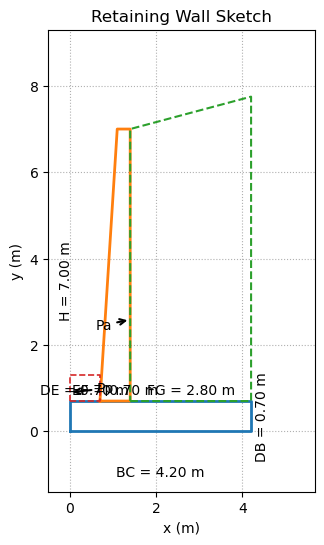

In [21]:
import math
from dataclasses import dataclass, asdict
from typing import Optional, Dict, Any, Tuple

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, clear_output
except Exception:
    display = print
    clear_output = lambda **kwargs: None

# --------------------------------------------------
# CONSTANT
# --------------------------------------------------
GAMMA_W = 9.81  # unit weight of water, kN/m3

# --------------------------------------------------
# SOIL DATABASE (updated from your table)
# --------------------------------------------------
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0,
        "gamma_sub": 10.19,
        "phi": 36.0,
        "cohesion": 0.0,
        "bearing_Low": 392.4,
        "bearing_Medium": 588.6,
        "bearing_High": 784.8,
        "reference": 2
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0,
        "gamma_sub": 10.19,
        "phi": 29.0,
        "cohesion": 12.75,
        "bearing_Low": 147.15,
        "bearing_Medium": 245.25,
        "bearing_High": 294.3,
        "reference": 4
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0,
        "gamma_sub": 10.19,
        "phi": 30.0,
        "cohesion": 7.5,
        "bearing_Low": 147.15,
        "bearing_Medium": 245.25,
        "bearing_High": 294.3,
        "reference": 4
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5,
        "gamma_sub": 8.69,
        "phi": 25.0,
        "cohesion": 7.5,
        "bearing_Low": 49.05,
        "bearing_Medium": 147.15,
        "bearing_High": 294.3,
        "reference": 8
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5,
        "gamma_sub": 7.69,
        "phi": 18.0,
        "cohesion": 12.75,
        "bearing_Low": 49.05,
        "bearing_Medium": 196.2,
        "bearing_High": 392.4,
        "reference": 7
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0,
        "gamma_sub": 9.19,
        "phi": 15.0,
        "cohesion": 20.0,
        "bearing_Low": 49.05,
        "bearing_Medium": 196.2,
        "bearing_High": 392.4,
        "reference": 7
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0,
        "gamma_sub": 10.19,
        "phi": 60.0,
        "cohesion": 0.0,
        "bearing_Low": None,
        "bearing_Medium": None,
        "bearing_High": None,
        "reference": None
    }
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]

def soil_lookup(soil_type: str, density_type: str) -> Dict[str, Any]:
    density_type = density_type.strip().title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    row["density_type"] = density_type
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row

# --------------------------------------------------
# INPUT CLASS
# --------------------------------------------------
@dataclass(frozen=True)
class WallInputs:
    soil_type: str = "CG"
    density_type: str = "Medium"

    beta_deg: float = 15.0
    H: float = 7.0
    h_toe: float = 0.6

    gamma_concrete: float = 24.0
    water_table_from_top: float = 0.0

    friction_wall_soil: float = 0.70

    BC_coef: float = 0.60   # BC = X * H
    DE_coef: float = 0.10   # DE = coeff * H
    EF_coef: float = 0.10   # EF = coeff * H
    DB_coef: float = 0.10   # DB = coeff * H
    top_width: float = 0.30

    use_manual_soil_values: bool = False
    gamma_bulk_override: Optional[float] = None
    gamma_sub_override: Optional[float] = None
    phi_override: Optional[float] = None
    cohesion_override: Optional[float] = None
    bearing_override: Optional[float] = None

# --------------------------------------------------
# GEOTECHNICAL FUNCTIONS
# --------------------------------------------------
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(
            f"Invalid geometry: beta must be <= phi. Given beta={beta_deg}°, phi={phi_deg}°"
        )

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)

    return Ka, Kp

def compute_wall(inputs: WallInputs) -> Dict[str, Any]:
    soil = soil_lookup(inputs.soil_type, inputs.density_type)

    if inputs.use_manual_soil_values:
        gamma_bulk = inputs.gamma_bulk_override if inputs.gamma_bulk_override is not None else soil["gamma_bulk"]
        gamma_sub = inputs.gamma_sub_override if inputs.gamma_sub_override is not None else soil["gamma_sub"]
        phi = inputs.phi_override if inputs.phi_override is not None else soil["phi"]
        cohesion = inputs.cohesion_override if inputs.cohesion_override is not None else soil["cohesion"]
        bearing = inputs.bearing_override if inputs.bearing_override is not None else soil["bearing_capacity"]
    else:
        gamma_bulk = soil["gamma_bulk"]
        gamma_sub = soil["gamma_sub"]
        phi = soil["phi"]
        cohesion = soil["cohesion"]
        bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    H = inputs.H
    BC = inputs.BC_coef * H
    DE = inputs.DE_coef * H
    EF = inputs.EF_coef * H
    DB = inputs.DB_coef * H
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG must be positive. Increase BC or reduce DE/EF.")

    beta_rad = math.radians(inputs.beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(inputs.beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = inputs.top_width * (H - DB) * inputs.gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - inputs.top_width, 0) * inputs.gamma_concrete
    W5 = DB * BC * inputs.gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active and passive forces
    Pa = 0.5 * Ka * gamma_bulk * H**2 - 2.0 * cohesion * math.sqrt(Ka) * H
    Pp = 0.5 * Kp * gamma_bulk * inputs.h_toe**2 + 2.0 * cohesion * math.sqrt(Kp) * inputs.h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe
    M_W1 = W1 * (DE + EF + 2.0 * FG / 3.0)
    M_W2 = W2 * (DE + EF + FG / 2.0)
    M_W3 = W3 * (DE + max(EF - inputs.top_width, 0) + inputs.top_width / 2.0)
    M_W4 = W4 * (DE + 2.0 * max(EF - inputs.top_width, 0) / 3.0) if W4 > 0 else 0.0
    M_W5 = W5 * (BC / 2.0)
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-9 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-9 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V)
    pmax = (V / BC) * (1.0 + 6.0 * e / BC)
    pmin = (V / BC) * (1.0 - 6.0 * e / BC)

    FS_bearing = None
    if bearing is not None and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    return {
        "inputs": asdict(inputs),
        "soil": soil,
        "gamma_bulk": gamma_bulk,
        "gamma_sub": gamma_sub,
        "phi": phi,
        "cohesion": cohesion,
        "bearing_capacity": bearing,
        "delta_deg": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "BC": BC,
        "DE": DE,
        "EF": EF,
        "DB": DB,
        "FG": FG,
        "H_prime": H_prime,
        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,
        "Mr": Mr,
        "Mo": Mo,
        "FS_overturning": FS_overturning,
        "FS_sliding": FS_sliding,
        "V": V,
        "eccentricity_e": e,
        "pmax": pmax,
        "pmin": pmin,
        "FS_bearing": FS_bearing
    }

# --------------------------------------------------
# RESULT TABLE
# --------------------------------------------------
def summarize_results(results: Dict[str, Any]) -> pd.DataFrame:
    rows = [
        ("Soil type", results["soil"]["soil_type"]),
        ("Density type", results["soil"]["density_type"]),
        ("Bulk unit weight γ (kN/m3)", results["gamma_bulk"]),
        ("Submerged unit weight γ' (kN/m3)", results["gamma_sub"]),
        ("Friction angle φ (deg)", results["phi"]),
        ("Cohesion c (kN/m2)", results["cohesion"]),
        ("Bearing capacity (kN/m2)", results["bearing_capacity"]),
        ("δ = 2/3 φ (deg)", results["delta_deg"]),
        ("Ka", results["Ka"]),
        ("Kp", results["Kp"]),
        ("BC (m)", results["BC"]),
        ("DE (m)", results["DE"]),
        ("EF (m)", results["EF"]),
        ("DB (m)", results["DB"]),
        ("FG (m)", results["FG"]),
        ("H' (m)", results["H_prime"]),
        ("Pa (kN/m)", results["Pa"]),
        ("Pp (kN/m)", results["Pp"]),
        ("Ph (kN/m)", results["Ph"]),
        ("Pv (kN/m)", results["Pv"]),
        ("FS overturning", results["FS_overturning"]),
        ("FS sliding", results["FS_sliding"]),
        ("Eccentricity e (m)", results["eccentricity_e"]),
        ("pmax (kN/m2)", results["pmax"]),
        ("pmin (kN/m2)", results["pmin"]),
        ("FS bearing", results["FS_bearing"]),
    ]
    return pd.DataFrame(rows, columns=["Parameter", "Value"])

# --------------------------------------------------
# PLOT SKETCH
# --------------------------------------------------
def plot_wall(inputs: WallInputs, results: Optional[Dict[str, Any]] = None, ax=None):
    if results is None:
        results = compute_wall(inputs)

    BC = results["BC"]
    DB = results["DB"]
    DE = results["DE"]
    EF = results["EF"]
    FG = results["FG"]
    H = inputs.H
    H_prime = results["H_prime"]
    top_width = inputs.top_width
    beta_rad = math.radians(inputs.beta_deg)

    # Coordinates
    B = (0, 0)
    C = (BC, 0)
    D = (0, DB)
    G = (BC, DB)
    E = (DE, DB)
    F = (DE + EF, DB)

    A_back = (DE + EF, H)
    A_front = (DE + EF - top_width, H)

    soil_top_back = (DE + EF, H)
    soil_top_heel = (BC, H_prime)

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 6))
    else:
        fig = ax.figure

    # Base
    ax.plot([B[0], C[0], G[0], D[0], B[0]],
            [B[1], C[1], G[1], D[1], B[1]], linewidth=2)

    # Stem
    ax.plot([E[0], F[0], A_back[0], A_front[0], E[0]],
            [E[1], F[1], A_back[1], A_front[1], E[1]], linewidth=2)

    # Backfill
    ax.plot([F[0], G[0], soil_top_heel[0], soil_top_back[0], F[0]],
            [F[1], G[1], soil_top_heel[1], soil_top_back[1], F[1]],
            linestyle="--", linewidth=1.5)

    # Toe soil
    toe_h = inputs.h_toe
    ax.plot([0, DE, DE, 0, 0],
            [DB, DB, DB + toe_h, DB + toe_h, DB],
            linestyle="--", linewidth=1.2)

    # Water table
    if inputs.water_table_from_top > 0:
        y_wt = max(0, H - inputs.water_table_from_top)
        ax.plot([F[0], BC], [y_wt, y_wt], linestyle=":", linewidth=2)
        ax.text(BC * 0.75, y_wt + 0.05, "Water table", fontsize=10)

    # Force arrows
    y_pa = H_prime / 3
    x_pa = F[0]
    L = 0.20 * BC
    ax.annotate(
        "Pa",
        xy=(x_pa, y_pa),
        xytext=(x_pa - L * math.cos(beta_rad), y_pa - L * math.sin(beta_rad)),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

    y_pp = DB + toe_h / 3
    ax.annotate(
        "Pp",
        xy=(0, y_pp),
        xytext=(0.15 * BC, y_pp),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

    # Dimension labels
    ax.text(BC / 2, -0.15 * H, f"BC = {BC:.2f} m", ha="center")
    ax.text(DE / 2, DB + 0.15, f"DE = {DE:.2f} m", ha="center")
    ax.text(DE + EF / 2, DB + 0.15, f"EF = {EF:.2f} m", ha="center")
    ax.text(DE + EF + FG / 2, DB + 0.15, f"FG = {FG:.2f} m", ha="center")
    ax.text(-0.25, H / 2, f"H = {H:.2f} m", rotation=90, va="center")
    ax.text(BC + 0.10, DB / 2, f"DB = {DB:.2f} m", rotation=90, va="center")

    ax.set_title("Retaining Wall Sketch")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle=":")
    ax.set_xlim(-0.5, BC * 1.35)
    ax.set_ylim(-0.2 * H, max(H_prime, H) * 1.2)

    return fig, ax

# --------------------------------------------------
# NORMAL RUN
# --------------------------------------------------
inp = WallInputs(
    soil_type="Silt",
    density_type="Medium",
    beta_deg=15,
    H=7.0,
    h_toe=0.6
)

res = compute_wall(inp)
display(summarize_results(res))
plot_wall(inp, res)
plt.show()

# --------------------------------------------------
# INTERACTIVE NOTEBOOK WIDGETS
# --------------------------------------------------
def show_interactive():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Install ipywidgets first:")
        print("pip install ipywidgets")
        return

    soil_dd = widgets.Dropdown(
        options=list(soil_db["soil_type"]),
        value="Silt",
        description="Soil Type"
    )

    density_dd = widgets.Dropdown(
        options=DENSITY_OPTIONS,
        value="Medium",
        description="Density"
    )

    beta_sl = widgets.FloatSlider(value=15, min=0, max=35, step=1, description="β (deg)")
    H_sl = widgets.FloatSlider(value=7, min=1, max=15, step=0.1, description="H (m)")
    htoe_sl = widgets.FloatSlider(value=0.6, min=0, max=3, step=0.05, description="h (m)")
    wt_sl = widgets.FloatSlider(value=0, min=0, max=15, step=0.1, description="WT top (m)")

    bc_sl = widgets.FloatSlider(value=0.60, min=0.30, max=1.50, step=0.05, description="BC/H")
    de_sl = widgets.FloatSlider(value=0.10, min=0.05, max=0.50, step=0.05, description="DE/H")
    ef_sl = widgets.FloatSlider(value=0.10, min=0.05, max=0.50, step=0.05, description="EF/H")
    db_sl = widgets.FloatSlider(value=0.10, min=0.05, max=0.30, step=0.01, description="DB/H")
    top_sl = widgets.FloatSlider(value=0.30, min=0.10, max=1.00, step=0.05, description="Top width")

    out = widgets.Output()

    def update(*args):
        with out:
            clear_output(wait=True)
            try:
                inp = WallInputs(
                    soil_type=soil_dd.value,
                    density_type=density_dd.value,
                    beta_deg=beta_sl.value,
                    H=H_sl.value,
                    h_toe=htoe_sl.value,
                    water_table_from_top=wt_sl.value,
                    BC_coef=bc_sl.value,
                    DE_coef=de_sl.value,
                    EF_coef=ef_sl.value,
                    DB_coef=db_sl.value,
                    top_width=top_sl.value
                )
                res = compute_wall(inp)
                display(summarize_results(res))
                plot_wall(inp, res)
                plt.show()
            except Exception as e:
                print("Error:", e)

    for w in [soil_dd, density_dd, beta_sl, H_sl, htoe_sl, wt_sl, bc_sl, de_sl, ef_sl, db_sl, top_sl]:
        w.observe(update, names="value")

    ui = widgets.VBox([
        widgets.HBox([soil_dd, density_dd]),
        widgets.HBox([beta_sl, H_sl, htoe_sl]),
        widgets.HBox([bc_sl, de_sl, ef_sl, db_sl]),
        widgets.HBox([top_sl, wt_sl]),
    ])

    display(ui, out)
    update()

# Run this in notebook:
# show_interactive()

,Parameter,Value
0,Soil type,Silt
1,Density type,Medium
2,Bulk unit weight γ (kN/m³),18.5
3,Submerged unit weight γ' (kN/m³),8.69
4,Friction angle φ (deg),25.0
5,Cohesion c (kN/m²),7.5
6,Bearing capacity (kN/m²),147.15
7,δ = 2/3 φ (deg),16.666667
8,Ka,0.469456
9,Kp,1.987433


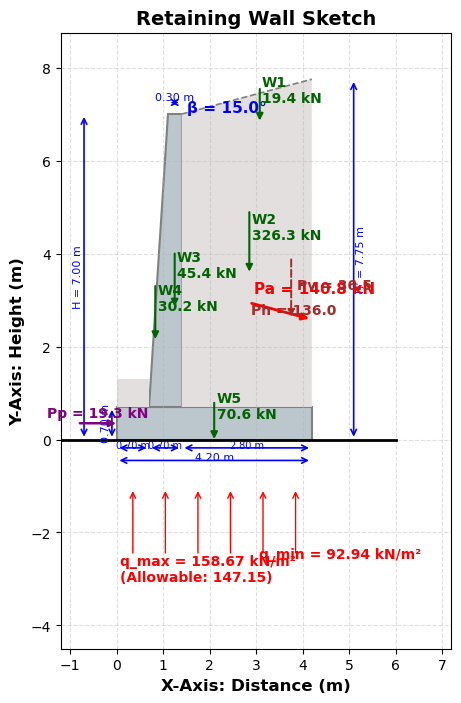

In [22]:
import math
from dataclasses import dataclass, asdict
from typing import Optional, Dict, Any, Tuple

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

try:
    from IPython.display import display, clear_output
except Exception:
    display = print
    clear_output = lambda **kwargs: None

# =========================================================
# CONSTANT
# =========================================================
GAMMA_W = 9.81  # kN/m3

# =========================================================
# SOIL DATABASE (exactly from your table)
# =========================================================
soil_db = pd.DataFrame([
    {"soil_type": "CG",      "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 36.0, "cohesion": 0.0,   "bearing_Low": 392.4,  "bearing_Medium": 588.6,  "bearing_High": 784.8, "reference": 2},
    {"soil_type": "CG PF",   "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 29.0, "cohesion": 12.75, "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "CG NPF",  "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 30.0, "cohesion": 7.5,   "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "Silt",    "gamma_bulk": 18.5, "gamma_sub": 8.69,  "phi": 25.0, "cohesion": 7.5,   "bearing_Low": 49.05,  "bearing_Medium": 147.15, "bearing_High": 294.3, "reference": 8},
    {"soil_type": "CL",      "gamma_bulk": 17.5, "gamma_sub": 7.69,  "phi": 18.0, "cohesion": 12.75, "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "CH",      "gamma_bulk": 19.0, "gamma_sub": 9.19,  "phi": 15.0, "cohesion": 20.0,  "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "Boulder", "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 60.0, "cohesion": 0.0,   "bearing_Low": None,   "bearing_Medium": None,   "bearing_High": None,  "reference": None},
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]

def soil_lookup(soil_type: str, density_type: str) -> Dict[str, Any]:
    density_type = density_type.strip().title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    row["density_type"] = density_type
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# INPUT CLASS
# =========================================================
@dataclass(frozen=True)
class WallInputs:
    soil_type: str = "CG"
    density_type: str = "Medium"

    beta_deg: float = 15.0
    H: float = 7.0
    h_toe: float = 0.6

    gamma_concrete: float = 24.0
    water_table_from_top: float = 0.0

    friction_wall_soil: float = 0.70

    BC_coef: float = 0.60
    DE_coef: float = 0.10
    EF_coef: float = 0.10
    DB_coef: float = 0.10
    top_width: float = 0.30

    use_manual_soil_values: bool = False
    gamma_bulk_override: Optional[float] = None
    gamma_sub_override: Optional[float] = None
    phi_override: Optional[float] = None
    cohesion_override: Optional[float] = None
    bearing_override: Optional[float] = None


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid geometry: beta must be <= phi. Given beta={beta_deg}°, phi={phi_deg}°")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)

    return Ka, Kp


def compute_wall(inputs: WallInputs) -> Dict[str, Any]:
    soil = soil_lookup(inputs.soil_type, inputs.density_type)

    if inputs.use_manual_soil_values:
        gamma_bulk = inputs.gamma_bulk_override if inputs.gamma_bulk_override is not None else soil["gamma_bulk"]
        gamma_sub = inputs.gamma_sub_override if inputs.gamma_sub_override is not None else soil["gamma_sub"]
        phi = inputs.phi_override if inputs.phi_override is not None else soil["phi"]
        cohesion = inputs.cohesion_override if inputs.cohesion_override is not None else soil["cohesion"]
        bearing = inputs.bearing_override if inputs.bearing_override is not None else soil["bearing_capacity"]
    else:
        gamma_bulk = soil["gamma_bulk"]
        gamma_sub = soil["gamma_sub"]
        phi = soil["phi"]
        cohesion = soil["cohesion"]
        bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    H = inputs.H
    BC = inputs.BC_coef * H
    DE = inputs.DE_coef * H
    EF = inputs.EF_coef * H
    DB = inputs.DB_coef * H
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG must be positive. Increase BC or reduce DE/EF.")

    beta_rad = math.radians(inputs.beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(inputs.beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = inputs.top_width * (H - DB) * inputs.gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - inputs.top_width, 0) * inputs.gamma_concrete
    W5 = DB * BC * inputs.gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active and passive forces
    Pa = 0.5 * Ka * gamma_bulk * H**2 - 2.0 * cohesion * math.sqrt(Ka) * H
    Pp = 0.5 * Kp * gamma_bulk * inputs.h_toe**2 + 2.0 * cohesion * math.sqrt(Kp) * inputs.h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe
    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - inputs.top_width, 0) + inputs.top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - inputs.top_width, 0) / 3.0 if W4 > 0 else None
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4 if W4 > 0 else 0.0
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-9 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-9 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V)
    pmax = (V / BC) * (1.0 + 6.0 * e / BC)
    pmin = (V / BC) * (1.0 - 6.0 * e / BC)

    FS_bearing = None
    if bearing is not None and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    return {
        "inputs": asdict(inputs),
        "soil": soil,
        "gamma_bulk": gamma_bulk,
        "gamma_sub": gamma_sub,
        "phi": phi,
        "cohesion": cohesion,
        "bearing_capacity": bearing,
        "delta_deg": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "BC": BC,
        "DE": DE,
        "EF": EF,
        "DB": DB,
        "FG": FG,
        "H_prime": H_prime,
        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "x_W1": x_W1,
        "x_W2": x_W2,
        "x_W3": x_W3,
        "x_W4": x_W4,
        "x_W5": x_W5,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,
        "Mr": Mr,
        "Mo": Mo,
        "FS_overturning": FS_overturning,
        "FS_sliding": FS_sliding,
        "V": V,
        "eccentricity_e": e,
        "pmax": pmax,
        "pmin": pmin,
        "FS_bearing": FS_bearing
    }


# =========================================================
# RESULT TABLE
# =========================================================
def summarize_results(results: Dict[str, Any]) -> pd.DataFrame:
    rows = [
        ("Soil type", results["soil"]["soil_type"]),
        ("Density type", results["soil"]["density_type"]),
        ("Bulk unit weight γ (kN/m³)", results["gamma_bulk"]),
        ("Submerged unit weight γ' (kN/m³)", results["gamma_sub"]),
        ("Friction angle φ (deg)", results["phi"]),
        ("Cohesion c (kN/m²)", results["cohesion"]),
        ("Bearing capacity (kN/m²)", results["bearing_capacity"]),
        ("δ = 2/3 φ (deg)", results["delta_deg"]),
        ("Ka", results["Ka"]),
        ("Kp", results["Kp"]),
        ("BC (m)", results["BC"]),
        ("DE (m)", results["DE"]),
        ("EF (m)", results["EF"]),
        ("DB (m)", results["DB"]),
        ("FG (m)", results["FG"]),
        ("H' (m)", results["H_prime"]),
        ("Pa (kN/m)", results["Pa"]),
        ("Pp (kN/m)", results["Pp"]),
        ("Ph (kN/m)", results["Ph"]),
        ("Pv (kN/m)", results["Pv"]),
        ("FS overturning", results["FS_overturning"]),
        ("FS sliding", results["FS_sliding"]),
        ("Eccentricity e (m)", results["eccentricity_e"]),
        ("q_max (kN/m²)", results["pmax"]),
        ("q_min (kN/m²)", results["pmin"]),
        ("FS bearing", results["FS_bearing"]),
    ]
    return pd.DataFrame(rows, columns=["Parameter", "Value"])


# =========================================================
# DRAWING HELPERS
# =========================================================
def draw_dimension(ax, p1, p2, text, text_offset=(0, 0), color="blue", lw=1.2, fs=8, rotation=0):
    ax.annotate(
        "",
        xy=p1,
        xytext=p2,
        arrowprops=dict(arrowstyle="<->", color=color, lw=lw)
    )
    tx = (p1[0] + p2[0]) / 2 + text_offset[0]
    ty = (p1[1] + p2[1]) / 2 + text_offset[1]
    ax.text(tx, ty, text, color=color, fontsize=fs, ha="center", va="center", rotation=rotation)


def add_force_arrow(ax, x, y_from, y_to, label, color="green", text_dx=0.05, text_dy=0.05):
    ax.annotate(
        "",
        xy=(x, y_to),
        xytext=(x, y_from),
        arrowprops=dict(arrowstyle="-|>", lw=1.5, color=color)
    )
    ax.text(x + text_dx, (y_from + y_to) / 2 + text_dy, label, color=color, fontsize=10, fontweight="bold")


def add_horizontal_arrow(ax, x_from, x_to, y, label, color="purple", text_offset=(0, 0.08)):
    ax.annotate(
        "",
        xy=(x_to, y),
        xytext=(x_from, y),
        arrowprops=dict(arrowstyle="-|>", lw=1.8, color=color)
    )
    ax.text((x_from + x_to)/2 + text_offset[0], y + text_offset[1], label,
            color=color, fontsize=10, fontweight="bold", ha="center")


# =========================================================
# EXACT-STYLE SKETCH
# =========================================================
def plot_wall_exact_style(inputs: WallInputs, results: Optional[Dict[str, Any]] = None):
    if results is None:
        results = compute_wall(inputs)

    BC = results["BC"]
    DE = results["DE"]
    EF = results["EF"]
    DB = results["DB"]
    FG = results["FG"]
    H = inputs.H
    H_prime = results["H_prime"]
    toe_h = inputs.h_toe
    top_w = inputs.top_width
    beta_deg = inputs.beta_deg
    beta_rad = math.radians(beta_deg)

    # Key points
    B = (0.0, 0.0)
    C = (BC, 0.0)
    D = (0.0, DB)
    G = (BC, DB)
    E = (DE, DB)
    F = (DE + EF, DB)

    A_back = (DE + EF, H)
    A_front = (DE + EF - top_w, H)

    heel_top = (BC, H_prime)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Ground line
    ax.plot([-1.2, BC + 1.8], [0, 0], color="black", lw=2)

    # Base slab
    base_poly = Polygon(
        [(0, 0), (BC, 0), (BC, DB), (0, DB)],
        closed=True, facecolor="#bcc7cd", edgecolor="gray", linewidth=1.5
    )
    ax.add_patch(base_poly)

    # Stem trapezoid
    stem_poly = Polygon(
        [E, F, A_back, A_front],
        closed=True, facecolor="#bcc7cd", edgecolor="gray", linewidth=1.5
    )
    ax.add_patch(stem_poly)

    # Backfill soil
    soil_poly = Polygon(
        [F, G, heel_top, A_back],
        closed=True, facecolor="#e3dfdf", edgecolor="none", alpha=1.0
    )
    ax.add_patch(soil_poly)

    # Toe soil block
    toe_poly = Polygon(
        [(0, DB), (DE, DB), (DE, DB + toe_h), (0, DB + toe_h)],
        closed=True, facecolor="#e3dfdf", edgecolor="none", alpha=1.0
    )
    ax.add_patch(toe_poly)

    # Slope line
    ax.plot([A_back[0], heel_top[0]], [A_back[1], heel_top[1]], linestyle="--", color="gray", lw=1.2)

    # Top width dimension
    y_topdim = H + 0.25
    draw_dimension(ax, (A_front[0], y_topdim), (A_back[0], y_topdim),
                   f"{top_w:.2f} m", text_offset=(0, 0.10), color="blue", fs=8)

    # H dimension
    draw_dimension(ax, (-0.7, 0), (-0.7, H), f"H = {H:.2f} m",
                   text_offset=(-0.12, 0), color="blue", fs=8, rotation=90)

    # H' dimension
    draw_dimension(ax, (BC + 0.9, 0), (BC + 0.9, H_prime), f"H' = {H_prime:.2f} m",
                   text_offset=(0.15, 0), color="blue", fs=8, rotation=90)

    # h dimension
    draw_dimension(ax, (-0.1, 0), (-0.1, DB), f"{DB:.2f} m",
                   text_offset=(-0.12, 0), color="blue", fs=8, rotation=90)

    # Bottom dimensions
    y_dim1 = -0.18
    y_dim2 = -0.45
    draw_dimension(ax, (0, y_dim1), (DE, y_dim1), f"{DE:.2f} m", text_offset=(0, 0.06), color="blue", fs=7)
    draw_dimension(ax, (DE, y_dim1), (DE + EF, y_dim1), f"{EF:.2f} m", text_offset=(0, 0.06), color="blue", fs=7)
    draw_dimension(ax, (DE + EF, y_dim1), (BC, y_dim1), f"{FG:.2f} m", text_offset=(0, 0.06), color="blue", fs=7)
    draw_dimension(ax, (0, y_dim2), (BC, y_dim2), f"{BC:.2f} m", text_offset=(0, 0.06), color="blue", fs=8)

    # Beta label
    ax.text(A_back[0] + 0.12, H + 0.03, f"β = {beta_deg:.1f}°",
            color="blue", fontsize=11, fontweight="bold")

    # Weights W1 to W5
    # W1: soil wedge
    x_w1 = A_back[0] + FG * 0.60
    y_w1_top = H_prime - 0.15
    y_w1_bot = H_prime - 0.95
    add_force_arrow(ax, x_w1, y_w1_top, y_w1_bot, f"W1\n{results['W1']:.1f} kN", color="darkgreen")

    # W2: soil rectangle over heel
    x_w2 = DE + EF + FG * 0.52
    y_w2_top = (H + DB) / 2 + 1.1
    y_w2_bot = (H + DB) / 2 - 0.3
    add_force_arrow(ax, x_w2, y_w2_top, y_w2_bot, f"W2\n{results['W2']:.1f} kN", color="darkgreen")

    # W3: stem rectangle
    x_w3 = A_back[0] - top_w / 2
    y_w3_top = H * 0.58
    y_w3_bot = H * 0.40
    add_force_arrow(ax, x_w3, y_w3_top, y_w3_bot, f"W3\n{results['W3']:.1f} kN", color="darkgreen")

    # W4: stem triangle
    if results["W4"] > 0:
        x_w4 = DE + (EF - top_w) / 3
        y_w4_top = H * 0.48
        y_w4_bot = H * 0.30
        add_force_arrow(ax, x_w4, y_w4_top, y_w4_bot, f"W4\n{results['W4']:.1f} kN", color="darkgreen")

    # W5: base slab
    x_w5 = BC / 2
    y_w5_top = DB + 0.15
    y_w5_bot = -0.05
    add_force_arrow(ax, x_w5, y_w5_top, y_w5_bot, f"W5\n{results['W5']:.1f} kN", color="darkgreen")

    # Active force Pa and horizontal component Ph
    y_pa = H_prime / 3.0
    x_pa = BC
    pa_len = 1.4
    x_pa2 = x_pa + pa_len * math.cos(math.pi - beta_rad)
    y_pa2 = y_pa + pa_len * math.sin(math.pi - beta_rad)

    ax.annotate(
        "",
        xy=(x_pa, y_pa),
        xytext=(x_pa2, y_pa2),
        arrowprops=dict(arrowstyle="-|>", color="red", lw=2)
    )
    ax.text(x_pa2 + 0.1, y_pa2 + 0.2, f"Pa = {results['Pa']:.1f} kN", color="red", fontsize=11, fontweight="bold")
    ax.text(x_pa2 + 0.05, y_pa2 - 0.25, f"Ph = {results['Ph']:.1f}", color="brown", fontsize=10, fontweight="bold")

    # Vertical component Pv
    ax.annotate(
        "",
        xy=(x_w2 + 0.9, y_pa),
        xytext=(x_w2 + 0.9, y_pa + 1.35),
        arrowprops=dict(arrowstyle="-|>", color="brown", lw=1.4, linestyle="--")
    )
    ax.text(x_w2 + 1.02, y_pa + 0.65, f"Pv = {results['Pv']:.1f}", color="brown", fontsize=10, fontweight="bold")

    # Passive force Pp
    y_pp = DB / 2
    add_horizontal_arrow(ax, -0.85, 0.05, y_pp, f"Pp = {results['Pp']:.1f} kN", color="purple", text_offset=(0, 0.12))

    # Base pressure arrows
    n_arrows = 6
    xs = [BC * (i + 0.5) / n_arrows for i in range(n_arrows)]
    y_base = -1.05

    for x in xs:
        ax.annotate(
            "",
            xy=(x, y_base),
            xytext=(x, y_base - 1.45),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.0)
        )

    ax.text(BC * 0.73, y_base - 1.5, f"q_min = {results['pmin']:.2f} kN/m²",
            color="red", fontsize=10, fontweight="bold")
    if results["bearing_capacity"] is not None:
        ax.text(BC * 0.02, y_base - 2.0,
                f"q_max = {results['pmax']:.2f} kN/m²\n(Allowable: {results['bearing_capacity']})",
                color="red", fontsize=10, fontweight="bold")
    else:
        ax.text(BC * 0.02, y_base - 2.0,
                f"q_max = {results['pmax']:.2f} kN/m²",
                color="red", fontsize=10, fontweight="bold")

    # Optional water table
    if inputs.water_table_from_top > 0:
        y_wt = max(0, H - inputs.water_table_from_top)
        ax.plot([F[0], BC], [y_wt, y_wt], linestyle=":", color="deepskyblue", lw=2)
        ax.text(BC * 0.7, y_wt + 0.08, "Water table", color="deepskyblue", fontsize=9)

    # Axis labels and layout
    ax.set_xlabel("X-Axis: Distance (m)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Y-Axis: Height (m)", fontsize=12, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlim(-1.2, BC + 3.0)
    ax.set_ylim(-4.5, max(H_prime + 1.0, H + 1.0))
    ax.set_title("Retaining Wall Sketch", fontsize=14, fontweight="bold")

    plt.show()


# =========================================================
# NORMAL RUN
# =========================================================
inp = WallInputs(
    soil_type="Silt",
    density_type="Medium",
    beta_deg=15,
    H=7.0,
    h_toe=0.6
)

res = compute_wall(inp)
display(summarize_results(res))
plot_wall_exact_style(inp, res)


# =========================================================
# INTERACTIVE USER OPTIONS
# =========================================================
def show_interactive():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Install ipywidgets first:")
        print("pip install ipywidgets")
        return

    soil_dd = widgets.Dropdown(
        options=list(soil_db["soil_type"]),
        value="Silt",
        description="Soil Type"
    )

    density_dd = widgets.Dropdown(
        options=DENSITY_OPTIONS,
        value="Medium",
        description="Density"
    )

    beta_sl = widgets.FloatSlider(value=15, min=0, max=35, step=1, description="β (deg)")
    H_sl = widgets.FloatSlider(value=7, min=1, max=15, step=0.1, description="H (m)")
    htoe_sl = widgets.FloatSlider(value=0.6, min=0, max=3, step=0.05, description="h (m)")
    wt_sl = widgets.FloatSlider(value=0, min=0, max=15, step=0.1, description="WT top (m)")

    bc_sl = widgets.FloatSlider(value=0.60, min=0.30, max=1.50, step=0.05, description="BC/H")
    de_sl = widgets.FloatSlider(value=0.10, min=0.05, max=0.50, step=0.05, description="DE/H")
    ef_sl = widgets.FloatSlider(value=0.10, min=0.05, max=0.50, step=0.05, description="EF/H")
    db_sl = widgets.FloatSlider(value=0.10, min=0.05, max=0.30, step=0.01, description="DB/H")
    top_sl = widgets.FloatSlider(value=0.30, min=0.10, max=1.00, step=0.05, description="Top width")

    out = widgets.Output()

    def update(*args):
        with out:
            clear_output(wait=True)
            try:
                inp = WallInputs(
                    soil_type=soil_dd.value,
                    density_type=density_dd.value,
                    beta_deg=beta_sl.value,
                    H=H_sl.value,
                    h_toe=htoe_sl.value,
                    water_table_from_top=wt_sl.value,
                    BC_coef=bc_sl.value,
                    DE_coef=de_sl.value,
                    EF_coef=ef_sl.value,
                    DB_coef=db_sl.value,
                    top_width=top_sl.value
                )
                res = compute_wall(inp)
                display(summarize_results(res))
                plot_wall_exact_style(inp, res)
            except Exception as e:
                print("Error:", e)

    for w in [soil_dd, density_dd, beta_sl, H_sl, htoe_sl, wt_sl, bc_sl, de_sl, ef_sl, db_sl, top_sl]:
        w.observe(update, names="value")

    ui = widgets.VBox([
        widgets.HBox([soil_dd, density_dd]),
        widgets.HBox([beta_sl, H_sl, htoe_sl]),
        widgets.HBox([bc_sl, de_sl, ef_sl, db_sl]),
        widgets.HBox([top_sl, wt_sl]),
    ])

    display(ui, out)
    update()

# Run this in notebook:
# show_interactive()


RETAINING WALL CALCULATOR - INTERACTIVE MODE

Available Soil Types in Database:
soil_type  phi  cohesion
       CG 36.0      0.00
    CG PF 29.0     12.75
   CG NPF 30.0      7.50
     Silt 25.0      7.50
       CL 18.0     12.75
       CH 15.0     20.00
  Boulder 60.0      0.00



Enter Soil Type (or type 'Manual' to enter own values):  CH



Density Options: Low, Medium, High


Enter Density (Low/Medium/High):  High



--- Wall Geometry ---


Total Wall Height H (m) [Default 7.0]:  9
Backfill Slope beta (deg) [Default 15]:  9
Depth of soil at toe (m) [Default 0.6]:  .8



       CALCULATION RESULTS
                       Parameter       Value
                       Soil type          CH
                    Density type        High
      Bulk unit weight γ (kN/m³)        19.0
Submerged unit weight γ' (kN/m³)        9.19
          Friction angle φ (deg)        15.0
              Cohesion c (kN/m²)        20.0
        Bearing capacity (kN/m²)       392.4
                 δ = 2/3 φ (deg)        10.0
                              Ka    0.646525
                              Kp     1.50888
                          BC (m)         5.4
                          DE (m)         0.9
                          EF (m)         0.9
                          DB (m)         0.9
                          FG (m)         3.6
                          H' (m)    9.570184
                       Pa (kN/m)  208.036444
                       Pp (kN/m)   48.481663
                       Ph (kN/m)   205.47517
                       Pv (kN/m)    32.54407
                  FS overtu

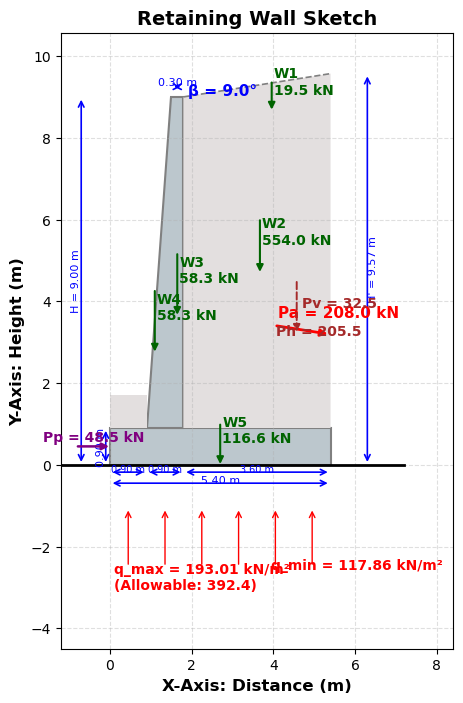

In [25]:
import math
import pandas as pd
# ... (Keeping your existing imports and constants)

def interactive_terminal_session():
    """
    A terminal-based interactive session for users to query soil types,
    set densities, and run calculations.
    """
    print("\n" + "="*50)
    print("RETAINING WALL CALCULATOR - INTERACTIVE MODE")
    print("="*50)

    # 1. Show available soil types
    print("\nAvailable Soil Types in Database:")
    print(soil_db[["soil_type", "phi", "cohesion"]].to_string(index=False))
    
    # 2. Get Soil Type
    soil_choice = input("\nEnter Soil Type (or type 'Manual' to enter own values): ").strip()
    
    # 3. Get Density
    print(f"\nDensity Options: {', '.join(DENSITY_OPTIONS)}")
    density_choice = input("Enter Density (Low/Medium/High): ").strip().title()
    if density_choice not in DENSITY_OPTIONS:
        print("Invalid density. Defaulting to Medium.")
        density_choice = "Medium"

    # 4. Handle Inputs
    manual_mode = False
    phi_val, coh_val, gamma_b, gamma_s, bearing_val = None, None, None, None, None

    if soil_choice.lower() == 'manual':
        manual_mode = True
        print("\n--- Manual Soil Parameter Entry ---")
        phi_val = float(input("Friction Angle phi (deg): "))
        coh_val = float(input("Cohesion c (kN/m2): "))
        gamma_b = float(input("Bulk Unit Weight (kN/m3): "))
        gamma_s = float(input("Submerged Unit Weight (kN/m3): "))
        bearing_val = float(input("Allowable Bearing Capacity (kN/m2): "))
    else:
        if soil_choice not in soil_db["soil_type"].values:
            print(f"Soil '{soil_choice}' not found. Defaulting to Silt.")
            soil_choice = "Silt"

    # 5. Geometry Inputs
    print("\n--- Wall Geometry ---")
    h_val = float(input("Total Wall Height H (m) [Default 7.0]: ") or 7.0)
    beta_val = float(input("Backfill Slope beta (deg) [Default 15]: ") or 15.0)
    toe_val = float(input("Depth of soil at toe (m) [Default 0.6]: ") or 0.6)

    # 6. Create Input Object
    inp = WallInputs(
        soil_type=soil_choice if not manual_mode else "Silt",
        density_type=density_choice,
        beta_deg=beta_val,
        H=h_val,
        h_toe=toe_val,
        use_manual_soil_values=manual_mode,
        phi_override=phi_val,
        cohesion_override=coh_val,
        gamma_bulk_override=gamma_b,
        gamma_sub_override=gamma_s,
        bearing_override=bearing_val
    )

    # 7. Calculate and Display
    try:
        results = compute_wall(inp)
        print("\n" + "="*30)
        print("       CALCULATION RESULTS")
        print("="*30)
        summary = summarize_results(results)
        print(summary.to_string(index=False))
        
        # Check Safety Factors
        print("\n--- Safety Check ---")
        fs_s = results["FS_sliding"]
        fs_o = results["FS_overturning"]
        
        print(f"Sliding FS: {fs_s:.2f} " + ("✅" if fs_s > 1.5 else "❌ (Req. > 1.5)"))
        print(f"Overturning FS: {fs_o:.2f} " + ("✅" if fs_o > 2.0 else "❌ (Req. > 2.0)"))
        
        # Plot
        plot_wall_exact_style(inp, results)
        
    except Exception as e:
        print(f"\nCalculation Error: {e}")

# To run the interactive terminal version:
if __name__ == "__main__":
    # You can still run the Jupyter widgets if in a notebook:
    # show_interactive()
    
    # Or run the terminal version:
    interactive_terminal_session()

In [28]:
import math
import itertools
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

import pandas as pd

# =========================================================
# SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {"soil_type": "CG",      "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 36.0, "cohesion": 0.0,   "bearing_Low": 392.4,  "bearing_Medium": 588.6,  "bearing_High": 784.8, "reference": 2},
    {"soil_type": "CG PF",   "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 29.0, "cohesion": 12.75, "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "CG NPF",  "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 30.0, "cohesion": 7.5,   "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "Silt",    "gamma_bulk": 18.5, "gamma_sub": 8.69,  "phi": 25.0, "cohesion": 7.5,   "bearing_Low": 49.05,  "bearing_Medium": 147.15, "bearing_High": 294.3, "reference": 8},
    {"soil_type": "CL",      "gamma_bulk": 17.5, "gamma_sub": 7.69,  "phi": 18.0, "cohesion": 12.75, "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "CH",      "gamma_bulk": 19.0, "gamma_sub": 9.19,  "phi": 15.0, "cohesion": 20.0,  "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "Boulder", "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 60.0, "cohesion": 0.0,   "bearing_Low": None,   "bearing_Medium": None,   "bearing_High": None,  "reference": None},
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}  # use old active pressure formula
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

# =========================================================
# USER INPUT HELPERS
# =========================================================
def ask_values(label: str, example: str, cast_func=float, allow_text=False) -> List[Any]:
    print(f"\n{label}")
    print(f"Example: {example}")
    n = int(input("How many values? : ").strip())
    raw = input("What are they? (comma separated) : ").strip()

    parts = [x.strip() for x in raw.split(",") if x.strip()]
    if len(parts) != n:
        raise ValueError(f"You said {n} values, but entered {len(parts)} values.")

    if allow_text:
        return parts
    return [cast_func(x) for x in parts]

def ask_single_text(label: str, example: str, allowed: Optional[List[str]] = None) -> str:
    print(f"\n{label}")
    print(f"Example: {example}")
    value = input("Enter value: ").strip()
    if allowed is not None and value.title() not in allowed:
        raise ValueError(f"Value must be one of {allowed}")
    return value.title()

def ask_yes_no(label: str, example: str = "Yes") -> bool:
    print(f"\n{label}")
    print(f"Example: {example}")
    value = input("Enter Yes or No: ").strip().lower()
    return value in {"yes", "y", "true", "1"}

# =========================================================
# SOIL LOOKUP
# =========================================================
def soil_lookup(soil_type: str, density_type: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found in database.")

    row = row.iloc[0].to_dict()
    row["density_type"] = density_type
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row

# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)

    return Ka, Kp

def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    # old formula
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)

def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    """
    From user's formula image:
    Zc = 2c / (gamma * sqrt(Ka))
    Pa = 1/2 * (H - Zc) * (gamma * H * Ka - 2c * sqrt(Ka))

    If H <= Zc, take Pa = 0
    """
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))
    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc

def compute_case(
    soil_type: str,
    density_type: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:
    soil = soil_lookup(soil_type, density_type)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi"]           # using intermediate values from your table
    cohesion = soil["cohesion"] # using intermediate values from your table
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    DB = DB_coef * H
    EF = DE  # based on your earlier sketch logic
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active pressure
    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    # Passive pressure
    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe
    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = None
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    all_forces = (
        f"W1={W1:.3f}, W2={W2:.3f}, W3={W3:.3f}, W4={W4:.3f}, W5={W5:.3f}, "
        f"W_total={W_total:.3f}, Pa={Pa:.3f}, Pp={Pp:.3f}, Ph={Ph:.3f}, Pv={Pv:.3f}"
    )

    all_moments = (
        f"M_W1={M_W1:.3f}, M_W2={M_W2:.3f}, M_W3={M_W3:.3f}, "
        f"M_W4={M_W4:.3f}, M_W5={M_W5:.3f}, M_Pv={M_Pv:.3f}, "
        f"Mr={Mr:.3f}, Mo={Mo:.3f}"
    )

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Toe soil height h": h_toe,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi (intermediate)": phi,
        "cohesion (intermediate)": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,
        "All forces": all_forces,
        "All moments": all_moments,
        "eccentricity": e,
        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        # keep separate numeric fields for easier sorting/filtering
        "W1": W1, "W2": W2, "W3": W3, "W4": W4, "W5": W5, "W_total": W_total,
        "Pa": Pa, "Pp": Pp, "Ph": Ph, "Pv": Pv,
        "Mr": Mr, "Mo": Mo, "pmax": pmax, "pmin": pmin
    }

# =========================================================
# EXCEL BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "Toe soil height h",
        "phi (intermediate)",
        "cohesion (intermediate)",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "pmax",
        "pmin",
    ]
    return pd.DataFrame(results)[cols]

def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Creates a wide dataframe where each combination uses 2 columns:
    [Parameter | Value], [Parameter | Value], ...
    """
    wanted_order = [
        "Soil types",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "All forces",
        "All moments",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    max_rows = len(wanted_order)

    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    # concatenate side by side
    out = pd.concat(blocks, axis=1)
    return out

def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        max_len = max(
            len(str(col)),
            *(len(str(x)) for x in df[col].fillna("").astype(str).values)
        )
        worksheet.set_column(idx, idx, min(max_len + 2, 40))

# =========================================================
# MAIN INTERACTIVE FLOW
# =========================================================
def main():
    print("=" * 70)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 70)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FS against overturning, sliding, and bearing,")
    print("and export results to Excel.\n")

    print("Available soil types in database:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("Available density types:")
    print(", ".join(DENSITY_OPTIONS))

    soil_types = ask_values(
        label="1. Soil types",
        example="CG, CG PF, Silt, CL",
        cast_func=str,
        allow_text=True
    )

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="6. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_type = ask_single_text(
        label="7. Density type",
        example="Medium",
        allowed=DENSITY_OPTIONS
    )

    h_toe_values = ask_values(
        label="8. Toe soil height h (m)",
        example="0.6",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="9. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        top_width = float(input("Enter top width (m): ").strip())

    use_default_gamma_conc = ask_yes_no(
        label="10. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())

    output_file = input(f"\n11. Output Excel file name [default: {DEFAULT_OUTPUT_FILE}] : ").strip()
    if output_file == "":
        output_file = DEFAULT_OUTPUT_FILE
    if not output_file.lower().endswith(".xlsx"):
        output_file += ".xlsx"

    # all combinations
    combos = list(itertools.product(
        soil_types,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, H, beta, BCc, DEc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "DB/H": DBc,
                "h": htoe,
                "Error": str(e)
            })

    if not results:
        print("No valid combinations were solved.")
        if errors:
            print("Some errors were found:")
            print(pd.DataFrame(errors).head())
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    # input info sheet
    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density type",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            density_type,
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc"
        ]
    })

    # write excel
    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        autosize_excel_columns(writer, "Inputs_Used", inputs_info)
        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)

        # freeze panes
        writer.sheets["Inputs_Used"].freeze_panes(1, 0)
        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)
        if not errors_df.empty:
            writer.sheets["Errors"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of summary:")
    display(summary_df.head())

# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FS against overturning, sliding, and bearing,
and export results to Excel.

Available soil types in database:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder
Available density types:
Low, Medium, High

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  1
What are they? (comma separated) :  CG



2. Height of structure H (m)
Example: 5, 7, 9


How many values? :  2
What are they? (comma separated) :  4, 7



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


...


7. Density type
Example: Medium


Enter value:  Medium



8. Toe soil height h (m)
Example: 0.6


How many values? :  .6


ValueError: invalid literal for int() with base 10: '.6'

In [32]:
import math
import itertools
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

import pandas as pd

# =========================================================
# SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {"soil_type": "CG",      "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 36.0, "cohesion": 0.0,   "bearing_Low": 392.4,  "bearing_Medium": 588.6,  "bearing_High": 784.8, "reference": 2},
    {"soil_type": "CG PF",   "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 29.0, "cohesion": 12.75, "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "CG NPF",  "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 30.0, "cohesion": 7.5,   "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "Silt",    "gamma_bulk": 18.5, "gamma_sub": 8.69,  "phi": 25.0, "cohesion": 7.5,   "bearing_Low": 49.05,  "bearing_Medium": 147.15, "bearing_High": 294.3, "reference": 8},
    {"soil_type": "CL",      "gamma_bulk": 17.5, "gamma_sub": 7.69,  "phi": 18.0, "cohesion": 12.75, "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "CH",      "gamma_bulk": 19.0, "gamma_sub": 9.19,  "phi": 15.0, "cohesion": 20.0,  "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "Boulder", "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 60.0, "cohesion": 0.0,   "bearing_Low": None,   "bearing_Medium": None,   "bearing_High": None,  "reference": None},
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}  # use old active pressure formula
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

# =========================================================
# USER INPUT HELPERS
# =========================================================
def ask_values(label: str, example: str, cast_func=float, allow_text=False) -> List[Any]:
    print(f"\n{label}")
    print(f"Example: {example}")
    n = int(input("How many values? : ").strip())
    raw = input("What are they? (comma separated) : ").strip()

    parts = [x.strip() for x in raw.split(",") if x.strip()]
    if len(parts) != n:
        raise ValueError(f"You said {n} values, but entered {len(parts)} values.")

    if allow_text:
        return parts
    return [cast_func(x) for x in parts]

def ask_single_text(label: str, example: str, allowed: Optional[List[str]] = None) -> str:
    print(f"\n{label}")
    print(f"Example: {example}")
    value = input("Enter value: ").strip()
    if allowed is not None and value.title() not in allowed:
        raise ValueError(f"Value must be one of {allowed}")
    return value.title()

def ask_yes_no(label: str, example: str = "Yes") -> bool:
    print(f"\n{label}")
    print(f"Example: {example}")
    value = input("Enter Yes or No: ").strip().lower()
    return value in {"yes", "y", "true", "1"}

# =========================================================
# SOIL LOOKUP
# =========================================================
def soil_lookup(soil_type: str, density_type: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found in database.")

    row = row.iloc[0].to_dict()
    row["density_type"] = density_type
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row

# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)

    return Ka, Kp

def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    # old formula
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)

def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    """
    From user's formula image:
    Zc = 2c / (gamma * sqrt(Ka))
    Pa = 1/2 * (H - Zc) * (gamma * H * Ka - 2c * sqrt(Ka))

    If H <= Zc, take Pa = 0
    """
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))
    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc

def compute_case(
    soil_type: str,
    density_type: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:
    soil = soil_lookup(soil_type, density_type)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi"]           # using intermediate values from your table
    cohesion = soil["cohesion"] # using intermediate values from your table
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    DB = DB_coef * H
    EF = DE  # based on your earlier sketch logic
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active pressure
    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    # Passive pressure
    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe
    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = None
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    all_forces = (
        f"W1={W1:.3f}, W2={W2:.3f}, W3={W3:.3f}, W4={W4:.3f}, W5={W5:.3f}, "
        f"W_total={W_total:.3f}, Pa={Pa:.3f}, Pp={Pp:.3f}, Ph={Ph:.3f}, Pv={Pv:.3f}"
    )

    all_moments = (
        f"M_W1={M_W1:.3f}, M_W2={M_W2:.3f}, M_W3={M_W3:.3f}, "
        f"M_W4={M_W4:.3f}, M_W5={M_W5:.3f}, M_Pv={M_Pv:.3f}, "
        f"Mr={Mr:.3f}, Mo={Mo:.3f}"
    )

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Toe soil height h": h_toe,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi (intermediate)": phi,
        "cohesion (intermediate)": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,
        "All forces": all_forces,
        "All moments": all_moments,
        "eccentricity": e,
        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        # keep separate numeric fields for easier sorting/filtering
        "W1": W1, "W2": W2, "W3": W3, "W4": W4, "W5": W5, "W_total": W_total,
        "Pa": Pa, "Pp": Pp, "Ph": Ph, "Pv": Pv,
        "Mr": Mr, "Mo": Mo, "pmax": pmax, "pmin": pmin
    }

# =========================================================
# EXCEL BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "Toe soil height h",
        "phi (intermediate)",
        "cohesion (intermediate)",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "pmax",
        "pmin",
    ]
    return pd.DataFrame(results)[cols]

def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Creates a wide dataframe where each combination uses 2 columns:
    [Parameter | Value], [Parameter | Value], ...
    """
    wanted_order = [
        "Soil types",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "All forces",
        "All moments",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    max_rows = len(wanted_order)

    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    # concatenate side by side
    out = pd.concat(blocks, axis=1)
    return out

def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        max_len = max(
            len(str(col)),
            *(len(str(x)) for x in df[col].fillna("").astype(str).values)
        )
        worksheet.set_column(idx, idx, min(max_len + 2, 40))

# =========================================================
# MAIN INTERACTIVE FLOW
# =========================================================
def main():
    print("=" * 70)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 70)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FS against overturning, sliding, and bearing,")
    print("and export results to Excel.\n")

    print("Available soil types in database:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("Available density types:")
    print(", ".join(DENSITY_OPTIONS))

    soil_types = ask_values(
        label="1. Soil types",
        example="CG, CG PF, Silt, CL",
        cast_func=str,
        allow_text=True
    )

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="6. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_type = ask_single_text(
        label="7. Density type",
        example="Medium",
        allowed=DENSITY_OPTIONS
    )

    h_toe_values = ask_values(
        label="8. Toe soil height h (m)",
        example="0.6",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="9. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        top_width = float(input("Enter top width (m): ").strip())

    use_default_gamma_conc = ask_yes_no(
        label="10. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())

    output_file = input(f"\n11. Output Excel file name [default: {DEFAULT_OUTPUT_FILE}] : ").strip()
    if output_file == "":
        output_file = DEFAULT_OUTPUT_FILE
    if not output_file.lower().endswith(".xlsx"):
        output_file += ".xlsx"

    # all combinations
    combos = list(itertools.product(
        soil_types,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, H, beta, BCc, DEc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "DB/H": DBc,
                "h": htoe,
                "Error": str(e)
            })

    if not results:
        print("No valid combinations were solved.")
        if errors:
            print("Some errors were found:")
            print(pd.DataFrame(errors).head())
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    # input info sheet
    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density type",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            density_type,
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc"
        ]
    })

    # write excel
    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        autosize_excel_columns(writer, "Inputs_Used", inputs_info)
        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)

        # freeze panes
        writer.sheets["Inputs_Used"].freeze_panes(1, 0)
        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)
        if not errors_df.empty:
            writer.sheets["Errors"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of summary:")
    display(summary_df.head())

# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FS against overturning, sliding, and bearing,
and export results to Excel.

Available soil types in database:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder
Available density types:
Low, Medium, High

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  6
What are they? (comma separated) :  CG, CG PF, CG NPF, Silt, CH, CL



2. Height of structure H (m)
Example: 5, 7, 9


How many values? :  3
What are they? (comma separated) :  4, 6, 9



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


How many values? :  4
What are they? (comma separated) :  0, 4


ValueError: You said 4 values, but entered 2 values.

In [ ]:
import math
import itertools
from typing import Dict, Any, List, Tuple, Optional

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {"soil_type": "CG",      "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 36.0, "cohesion": 0.0,   "bearing_Low": 392.4,  "bearing_Medium": 588.6,  "bearing_High": 784.8, "reference": 2},
    {"soil_type": "CG PF",   "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 29.0, "cohesion": 12.75, "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "CG NPF",  "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 30.0, "cohesion": 7.5,   "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3, "reference": 4},
    {"soil_type": "Silt",    "gamma_bulk": 18.5, "gamma_sub": 8.69,  "phi": 25.0, "cohesion": 7.5,   "bearing_Low": 49.05,  "bearing_Medium": 147.15, "bearing_High": 294.3, "reference": 8},
    {"soil_type": "CL",      "gamma_bulk": 17.5, "gamma_sub": 7.69,  "phi": 18.0, "cohesion": 12.75, "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "CH",      "gamma_bulk": 19.0, "gamma_sub": 9.19,  "phi": 15.0, "cohesion": 20.0,  "bearing_Low": 49.05,  "bearing_Medium": 196.2,  "bearing_High": 392.4, "reference": 7},
    {"soil_type": "Boulder", "gamma_bulk": 20.0, "gamma_sub": 10.19, "phi": 60.0, "cohesion": 0.0,   "bearing_Low": None,   "bearing_Medium": None,   "bearing_High": None,  "reference": None},
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"


# =========================================================
# SAFE USER INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3, 4.")


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")

        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = parts
                if allowed_values is not None:
                    bad = [v for v in values if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                return values
            else:
                values = [cast_func(x) for x in parts]
                return values

        except ValueError:
            if allow_text:
                print("Invalid text input. Please enter valid text values.")
            else:
                print("Invalid numeric input. Please enter numbers only, separated by commas.")


def ask_single_text(label: str, example: str, allowed=None) -> str:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter value: ").strip()

        if value == "":
            print("Input cannot be empty. Please enter again.")
            continue

        value_clean = value.title()

        if allowed is not None and value_clean not in allowed:
            print(f"Invalid value. Allowed values are: {allowed}")
            continue

        return value_clean


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            print("Please enter again.")
            continue

        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n11. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def soil_lookup(soil_type: str, density_type: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found in database.")

    row = row.iloc[0].to_dict()
    row["density_type"] = density_type
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)

    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    """
    New formula from your image:
    Zc = 2c / (gamma * sqrt(Ka))
    Pa = 1/2 * (H - Zc) * (gamma*H*Ka - 2c*sqrt(Ka))
    If H <= Zc, take Pa = 0.
    """
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi"]           # intermediate value from your table
    cohesion = soil["cohesion"] # intermediate value from your table
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    DB = DB_coef * H
    EF = DE
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active pressure
    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    # Passive pressure
    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe
    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = None
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    all_forces = (
        f"W1={W1:.3f}, W2={W2:.3f}, W3={W3:.3f}, W4={W4:.3f}, W5={W5:.3f}, "
        f"W_total={W_total:.3f}, Pa={Pa:.3f}, Pp={Pp:.3f}, Ph={Ph:.3f}, Pv={Pv:.3f}"
    )

    all_moments = (
        f"M_W1={M_W1:.3f}, M_W2={M_W2:.3f}, M_W3={M_W3:.3f}, "
        f"M_W4={M_W4:.3f}, M_W5={M_W5:.3f}, M_Pv={M_Pv:.3f}, "
        f"Mr={Mr:.3f}, Mo={Mo:.3f}"
    )

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Toe soil height h": h_toe,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi (intermediate)": phi,
        "cohesion (intermediate)": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,
        "All forces": all_forces,
        "All moments": all_moments,
        "eccentricity": e,
        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,
        "Mr": Mr,
        "Mo": Mo,
        "pmax": pmax,
        "pmin": pmin
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "Toe soil height h",
        "phi (intermediate)",
        "cohesion (intermediate)",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "pmax",
        "pmin",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "All forces",
        "All moments",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    out = pd.concat(blocks, axis=1)
    return out


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 72)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 72)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("Available density types:")
    print(", ".join(DENSITY_OPTIONS))

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="6. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_type = ask_single_text(
        label="7. Density type",
        example="Medium",
        allowed=DENSITY_OPTIONS
    )

    h_toe_values = ask_values(
        label="8. Toe soil height h (m)",
        example="0.6",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="9. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        while True:
            try:
                top_width = float(input("Enter top width (m): ").strip())
                if top_width <= 0:
                    print("Top width must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    use_default_gamma_conc = ask_yes_no(
        label="10. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, H, beta, BCc, DEc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "DB/H": DBc,
                "h": htoe,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            print("\nSome errors were found:")
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density type",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            density_type,
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc"
        ]
    })

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        autosize_excel_columns(writer, "Inputs_Used", inputs_info)
        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)

        writer.sheets["Inputs_Used"].freeze_panes(1, 0)
        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

        if not errors_df.empty:
            writer.sheets["Errors"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder
Available density types:
Low, Medium, High

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  6
What are they? (comma separated) :  CG, CG PF, CG NPF, Silt, CL, CH, Boulder


You said 6 values, but entered 7 values. Please enter again.

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  7
What are they? (comma separated) :  CG, CG PF, CG NPF, Silt, CL, CH, Boulder



2. Height of structure H (m)
Example: 5, 7, 9


...

Invalid input. Please enter Yes or No.

9. Use default top width = 0.30 m ?
Example: Yes


Enter Yes or No:  Yes



10. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

11. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  another 2



Total combinations to evaluate: 39690


In [35]:
import math
import itertools
from typing import Dict, Any, List, Tuple, Optional

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# SOIL DATABASE
# NOTE:
# Replace the low/high phi-c values below with your exact table
# if you have the final values.
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "phi_intermediate": 36.0, "c_intermediate": 0.0,
        "phi_lowc_highphi": 36.0, "c_lowc_highphi": 0.0,
        "phi_highc_lowphi": 36.0, "c_highc_lowphi": 0.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8,
        "reference": 2
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "phi_intermediate": 29.0, "c_intermediate": 12.75,
        "phi_lowc_highphi": 31.0, "c_lowc_highphi": 7.5,
        "phi_highc_lowphi": 27.0, "c_highc_lowphi": 16.5,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3,
        "reference": 4
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "phi_intermediate": 30.0, "c_intermediate": 7.5,
        "phi_lowc_highphi": 34.0, "c_lowc_highphi": 5.0,
        "phi_highc_lowphi": 28.0, "c_highc_lowphi": 10.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3,
        "reference": 4
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "phi_intermediate": 25.0, "c_intermediate": 7.5,
        "phi_lowc_highphi": 27.0, "c_lowc_highphi": 5.0,
        "phi_highc_lowphi": 22.0, "c_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3,
        "reference": 8
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "phi_intermediate": 18.0, "c_intermediate": 12.75,
        "phi_lowc_highphi": 23.0, "c_lowc_highphi": 19.5,
        "phi_highc_lowphi": 15.0, "c_highc_lowphi": 24.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4,
        "reference": 7
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "phi_intermediate": 15.0, "c_intermediate": 20.0,
        "phi_lowc_highphi": 18.0, "c_lowc_highphi": 16.0,
        "phi_highc_lowphi": 12.0, "c_highc_lowphi": 24.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4,
        "reference": 7
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "phi_intermediate": 60.0, "c_intermediate": 0.0,
        "phi_lowc_highphi": 60.0, "c_lowc_highphi": 0.0,
        "phi_highc_lowphi": 60.0, "c_highc_lowphi": 0.0,
        "bearing_Low": None, "bearing_Medium": None, "bearing_High": None,
        "reference": None
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")

def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x) for x in parts]
                if allowed_values is not None:
                    bad = [v for v in values if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                return values
            else:
                return [cast_func(x) for x in parts]
        except ValueError:
            print("Invalid input. Please enter again.")

def ask_single_text(label: str, example: str, allowed=None) -> str:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter value: ").strip()

        if value == "":
            print("Input cannot be empty. Please enter again.")
            continue

        # normalize
        value_norm = " ".join(value.split()).title()

        if allowed is not None and value_norm not in allowed:
            print(f"Invalid value. Allowed values are: {allowed}")
            continue

        return value_norm

def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        if value in {"no", "n", "false", "0"}:
            return False
        print("Invalid input. Please enter Yes or No.")

def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )
        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values

def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n12. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")

def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp

def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)

def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc

def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    DB = DB_coef * H
    EF = DE
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = None
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    all_forces = (
        f"W1={W1:.3f}, W2={W2:.3f}, W3={W3:.3f}, W4={W4:.3f}, W5={W5:.3f}, "
        f"W_total={W_total:.3f}, Pa={Pa:.3f}, Pp={Pp:.3f}, Ph={Ph:.3f}, Pv={Pv:.3f}"
    )

    all_moments = (
        f"M_W1={M_W1:.3f}, M_W2={M_W2:.3f}, M_W3={M_W3:.3f}, "
        f"M_W4={M_W4:.3f}, M_W5={M_W5:.3f}, M_Pv={M_Pv:.3f}, "
        f"Mr={Mr:.3f}, Mo={Mo:.3f}"
    )

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Toe soil height h": h_toe,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,
        "All forces": all_forces,
        "All moments": all_moments,
        "eccentricity": e,
        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "W1": W1, "W2": W2, "W3": W3, "W4": W4, "W5": W5, "W_total": W_total,
        "Pa": Pa, "Pp": Pp, "Ph": Ph, "Pv": Pv,
        "Mr": Mr, "Mo": Mo, "pmax": pmax, "pmin": pmin
    }


# =========================================================
# OUTPUT TABLE BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "Toe soil height h",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "pmax",
        "pmin",
    ]
    return pd.DataFrame(results)[cols]

def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "All forces",
        "All moments",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)

def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 72)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 72)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("Available density types:")
    print(", ".join(DENSITY_OPTIONS))
    print("Available strength states:")
    print(", ".join(STRENGTH_STATE_OPTIONS))

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="6. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_type = ask_single_text(
        label="7. Density type",
        example="Medium",
        allowed=DENSITY_OPTIONS
    )

    strength_state = ask_single_text(
        label="8. Soil strength state",
        example="Intermediate",
        allowed=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="9. Toe soil height h (m)",
        example="0.6",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="10. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        while True:
            try:
                top_width = float(input("Enter top width (m): ").strip())
                if top_width <= 0:
                    print("Top width must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    use_default_gamma_conc = ask_yes_no(
        label="11. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, H, beta, BCc, DEc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "DB/H": DBc,
                "h": htoe,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density type",
            "Strength state",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            density_type,
            strength_state,
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)
        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 28)
        ws_inputs.set_column(1, 1, 45)
        ws_inputs.freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)
        if not errors_df.empty:
            writer.sheets["Errors"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder
Available density types:
Low, Medium, High
Available strength states:
Intermediate, Low C High Phi, High C Low Phi

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  7
What are they? (comma separated) :  CG, CG PF, CG NPF, Silt, CL, CH, Boulder



2. Height of structure H (m)
Example: 5, 7, 9


How many values? :  3
What are they? (comma separated) :  5, 7,9



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


...

Enter Yes or No:  Yes



11. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

12. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  xxxx



Total combinations to evaluate: 3780

Done.
Valid combinations solved: 3024
Failed combinations: 756
Excel file created: xxxx.xlsx

Preview of Summary sheet:


,Soil types,Density type,Strength state,Height of structure,inclination of soil,Coefficient of length (BC/H),Coefficient of base (DE/H),Coefficient of height of toe (DB/H),Length BC,Length DE,...,Ka,Kp,Zc,Active formula used,eccentricity,FOS_against Overturning,FOS_against Sliding,FOS_against Bearing,pmax,pmin
0,CG,Medium,High C Low Phi,5.0,0.0,0.3,0.1,0.10,1.5,0.5,...,0.259616,3.85184,0.0,Old formula,0.788074,0.962621,0.942159,2.002160,293.982426,-152.382426
1,CG,Medium,High C Low Phi,5.0,0.0,0.3,0.1,0.10,1.5,0.5,...,0.259616,3.85184,0.0,Old formula,0.788074,0.962621,1.019309,2.002160,293.982426,-152.382426
2,CG,Medium,High C Low Phi,5.0,0.0,0.3,0.1,0.15,1.5,0.5,...,0.259616,3.85184,0.0,Old formula,0.771110,0.978475,0.970284,1.959763,300.342426,-153.275760
3,CG,Medium,High C Low Phi,5.0,0.0,0.3,0.1,0.15,1.5,0.5,...,0.259616,3.85184,0.0,Old formula,0.771110,0.978475,1.047435,1.959763,300.342426,-153.275760
4,CG,Medium,High C Low Phi,5.0,0.0,0.4,0.1,0.10,2.0,0.5,...,0.259616,3.85184,0.0,Old formula,0.457973,1.787685,1.292008,3.154508,186.590115,-29.390115


In [36]:
import math
import itertools
from typing import Dict, Any, List, Tuple

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# UPDATED SOIL DATABASE (from your latest table)
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 0.0,
        "phi_intermediate": 36.0, "phi_lowc_highphi": 40.0, "phi_highc_lowphi": 32.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 29.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 30.0, "phi_lowc_highphi": 32.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 25.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 20.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 18.0, "phi_lowc_highphi": 27.0, "phi_highc_lowphi": 15.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "c_intermediate": 20.0, "c_lowc_highphi": 10.0, "c_highc_lowphi": 40.0,
        "phi_intermediate": 15.0, "phi_lowc_highphi": 20.0, "phi_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 60.0, "phi_lowc_highphi": 60.0, "phi_highc_lowphi": 37.0,
        "bearing_Low": 981.0, "bearing_Medium": 981.0, "bearing_High": 981.0
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

REQUIRED_FOS_OVERTURNING = 2.0
REQUIRED_FOS_SLIDING = 1.5
REQUIRED_FOS_BEARING = 3.0


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")


def normalize_strength_state(text: str) -> str:
    t = " ".join(text.strip().split()).lower()
    mapping = {
        "intermediate": "Intermediate",
        "low c high phi": "Low C High Phi",
        "low c high p i": "Low C High Phi",
        "high c low phi": "High C Low Phi",
        "high c low p i": "High C Low Phi",
    }
    return mapping.get(t, text.title())


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x).strip() for x in parts]

                if allowed_values is not None:
                    normalized = []
                    for v in values:
                        if allowed_values == STRENGTH_STATE_OPTIONS:
                            vv = normalize_strength_state(v)
                        else:
                            vv = v.title()
                        normalized.append(vv)

                    bad = [v for v in normalized if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                    return normalized

                return values
            else:
                return [cast_func(x) for x in parts]

        except ValueError:
            print("Invalid input. Please enter again.")


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n12. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")


def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    DB = DB_coef * H
    EF = DE
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active pressure
    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    # Passive pressure
    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments about toe
    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = "N/A"
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    all_forces = (
        f"W1={W1:.3f}, W2={W2:.3f}, W3={W3:.3f}, W4={W4:.3f}, W5={W5:.3f}, "
        f"W_total={W_total:.3f}, Pa={Pa:.3f}, Pp={Pp:.3f}, Ph={Ph:.3f}, Pv={Pv:.3f}"
    )

    all_moments = (
        f"M_W1={M_W1:.3f}, M_W2={M_W2:.3f}, M_W3={M_W3:.3f}, "
        f"M_W4={M_W4:.3f}, M_W5={M_W5:.3f}, M_Pv={M_Pv:.3f}, "
        f"Mr={Mr:.3f}, Mo={Mo:.3f}"
    )

    overturning_check = "PASS" if FS_overturning >= REQUIRED_FOS_OVERTURNING else "FAIL"
    sliding_check = "PASS" if FS_sliding >= REQUIRED_FOS_SLIDING else "FAIL"
    if FS_bearing == "N/A":
        bearing_check = "N/A"
    else:
        bearing_check = "PASS" if FS_bearing >= REQUIRED_FOS_BEARING else "FAIL"

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Toe soil height h": h_toe,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,
        "All forces": all_forces,
        "All moments": all_moments,
        "eccentricity": e,
        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "Required FOS Overturning": REQUIRED_FOS_OVERTURNING,
        "Required FOS Sliding": REQUIRED_FOS_SLIDING,
        "Required FOS Bearing": REQUIRED_FOS_BEARING,
        "Overturning Check": overturning_check,
        "Sliding Check": sliding_check,
        "Bearing Check": bearing_check,
        "W1": W1, "W2": W2, "W3": W3, "W4": W4, "W5": W5, "W_total": W_total,
        "Pa": Pa, "Pp": Pp, "Ph": Ph, "Pv": Pv,
        "Mr": Mr, "Mo": Mo, "pmax": pmax, "pmin": pmin
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "Toe soil height h",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "Required FOS Overturning",
        "Required FOS Sliding",
        "Required FOS Bearing",
        "Overturning Check",
        "Sliding Check",
        "Bearing Check",
        "pmax",
        "pmin",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "All forces",
        "All moments",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 74)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 74)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("\nAvailable density types:")
    print("Low, Medium, High")
    print("Example input: Medium, High")
    print("\nAvailable strength states:")
    print("Intermediate, Low C High Phi, High C Low Phi")
    print("Example input: Intermediate, High C Low Phi")

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="6. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_types = ask_values(
        label="7. Soil density type(s)",
        example="Medium, High",
        cast_func=str,
        allow_text=True,
        allowed_values=DENSITY_OPTIONS
    )

    strength_states = ask_values(
        label="8. Soil strength state(s)",
        example="Intermediate, High C Low Phi",
        cast_func=str,
        allow_text=True,
        allowed_values=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="9. Toe soil height h (m)",
        example="0.6, 1.0",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="10. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        while True:
            try:
                top_width = float(input("Enter top width (m): ").strip())
                if top_width <= 0:
                    print("Top width must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    use_default_gamma_conc = ask_yes_no(
        label="11. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        density_types,
        strength_states,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, density_type, strength_state, H, beta, BCc, DEc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "Density": density_type,
                "Strength State": strength_state,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "DB/H": DBc,
                "h": htoe,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density types",
            "Strength states",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils",
            "Required FOS Overturning",
            "Required FOS Sliding",
            "Required FOS Bearing",
            "Bearing selection rule"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            ", ".join(density_types),
            ", ".join(strength_states),
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc",
            REQUIRED_FOS_OVERTURNING,
            REQUIRED_FOS_SLIDING,
            REQUIRED_FOS_BEARING,
            "Low density uses bearing_Low, Medium uses bearing_Medium, High uses bearing_High"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 32)
        ws_inputs.set_column(1, 1, 60)
        ws_inputs.freeze_panes(1, 0)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)
            writer.sheets["Errors"].freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder

Available density types:
Low, Medium, High
Example input: Medium, High

Available strength states:
Intermediate, Low C High Phi, High C Low Phi
Example input: Intermediate, High C Low Phi

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  7
What are they? (comma separated) :  CG, CG PF, Silt, CL, CG NPF, Boulder, CH



2. Height of structure H (m)
Example: 5, 7, 9


How many values? :  3
What are they? (comma separated) :  5, 7, 9



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


...

Enter Yes or No:  Yes



11. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

12. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  hiii



Total combinations to evaluate: 30240


ValueError: This sheet is too large! Your sheet size is: 14, 60480 Max sheet size is: 1048576, 16384

In [2]:
import math
import itertools
from typing import Dict, Any, List, Tuple

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# UPDATED SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 0.0,
        "phi_intermediate": 36.0, "phi_lowc_highphi": 40.0, "phi_highc_lowphi": 32.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 29.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 30.0, "phi_lowc_highphi": 32.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 25.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 20.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 18.0, "phi_lowc_highphi": 27.0, "phi_highc_lowphi": 15.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "c_intermediate": 20.0, "c_lowc_highphi": 10.0, "c_highc_lowphi": 40.0,
        "phi_intermediate": 15.0, "phi_lowc_highphi": 20.0, "phi_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 60.0, "phi_lowc_highphi": 60.0, "phi_highc_lowphi": 37.0,
        "bearing_Low": 981.0, "bearing_Medium": 981.0, "bearing_High": 981.0
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

REQUIRED_FOS_OVERTURNING = 2.0
REQUIRED_FOS_SLIDING = 1.5
REQUIRED_FOS_BEARING = 3.0


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")


def normalize_strength_state(text: str) -> str:
    t = " ".join(text.strip().split()).lower()
    mapping = {
        "intermediate": "Intermediate",
        "low c high phi": "Low C High Phi",
        "high c low phi": "High C Low Phi",
    }
    return mapping.get(t, text.title())


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x).strip() for x in parts]

                if allowed_values is not None:
                    normalized = []
                    for v in values:
                        if allowed_values == STRENGTH_STATE_OPTIONS:
                            vv = normalize_strength_state(v)
                        else:
                            vv = v.title()
                        normalized.append(vv)

                    bad = [v for v in normalized if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                    return normalized

                return values
            else:
                return [cast_func(x) for x in parts]

        except ValueError:
            print("Invalid input. Please enter again.")


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n12. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")


def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    DB = DB_coef * H
    EF = DE
    FG = BC - DE - EF

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = "N/A"
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    all_forces = (
        f"W1={W1:.3f}, W2={W2:.3f}, W3={W3:.3f}, W4={W4:.3f}, W5={W5:.3f}, "
        f"W_total={W_total:.3f}, Pa={Pa:.3f}, Pp={Pp:.3f}, Ph={Ph:.3f}, Pv={Pv:.3f}"
    )

    all_moments = (
        f"M_W1={M_W1:.3f}, M_W2={M_W2:.3f}, M_W3={M_W3:.3f}, "
        f"M_W4={M_W4:.3f}, M_W5={M_W5:.3f}, M_Pv={M_Pv:.3f}, "
        f"Mr={Mr:.3f}, Mo={Mo:.3f}"
    )

    overturning_check = "PASS" if FS_overturning >= REQUIRED_FOS_OVERTURNING else "FAIL"
    sliding_check = "PASS" if FS_sliding >= REQUIRED_FOS_SLIDING else "FAIL"
    if FS_bearing == "N/A":
        bearing_check = "N/A"
    else:
        bearing_check = "PASS" if FS_bearing >= REQUIRED_FOS_BEARING else "FAIL"

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Toe soil height h": h_toe,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,
        "All forces": all_forces,
        "All moments": all_moments,
        "eccentricity": e,
        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "Required FOS Overturning": REQUIRED_FOS_OVERTURNING,
        "Required FOS Sliding": REQUIRED_FOS_SLIDING,
        "Required FOS Bearing": REQUIRED_FOS_BEARING,
        "Overturning Check": overturning_check,
        "Sliding Check": sliding_check,
        "Bearing Check": bearing_check,
        "W1": W1, "W2": W2, "W3": W3, "W4": W4, "W5": W5, "W_total": W_total,
        "Pa": Pa, "Pp": Pp, "Ph": Ph, "Pv": Pv,
        "Mr": Mr, "Mo": Mo, "pmax": pmax, "pmin": pmin
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "Required FOS Overturning",
        "Required FOS Sliding",
        "Required FOS Bearing",
        "Overturning Check",
        "Sliding Check",
        "Bearing Check",
        "pmax",
        "pmin",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "All forces",
        "All moments",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 74)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 74)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("\nAvailable density types:")
    print("Low, Medium, High")
    print("Example input: Medium, High")
    print("\nAvailable strength states:")
    print("Intermediate, Low C High Phi, High C Low Phi")
    print("Example input: Intermediate, High C Low Phi")

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="6. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_types = ask_values(
        label="7. Soil density type(s)",
        example="Medium, High",
        cast_func=str,
        allow_text=True,
        allowed_values=DENSITY_OPTIONS
    )

    strength_states = ask_values(
        label="8. Soil strength state(s)",
        example="Intermediate, High C Low Phi",
        cast_func=str,
        allow_text=True,
        allowed_values=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="9. Toe soil height h (m)",
        example="0.6, 0.7",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="10. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        while True:
            try:
                top_width = float(input("Enter top width (m): ").strip())
                if top_width <= 0:
                    print("Top width must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    use_default_gamma_conc = ask_yes_no(
        label="11. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        density_types,
        strength_states,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, density_type, strength_state, H, beta, BCc, DEc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "Density": density_type,
                "Strength State": strength_state,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "DB/H": DBc,
                "Toe soil height h": htoe,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density types",
            "Strength states",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils",
            "Required FOS Overturning",
            "Required FOS Sliding",
            "Required FOS Bearing",
            "Bearing selection rule"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            ", ".join(density_types),
            ", ".join(strength_states),
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc",
            REQUIRED_FOS_OVERTURNING,
            REQUIRED_FOS_SLIDING,
            REQUIRED_FOS_BEARING,
            "Low density uses bearing_Low, Medium uses bearing_Medium, High uses bearing_High"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 32)
        ws_inputs.set_column(1, 1, 60)
        ws_inputs.freeze_panes(1, 0)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)
            writer.sheets["Errors"].freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder

Available density types:
Low, Medium, High
Example input: Medium, High

Available strength states:
Intermediate, Low C High Phi, High C Low Phi
Example input: Intermediate, High C Low Phi

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  1
What are they? (comma separated) :  CG



2. Height of structure H (m)
Example: 5, 7, 9


How many values? :  5
What are they? (comma separated) :  2, 3, 5, 7, 9



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


...

Enter Yes or No:  Yes



11. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

12. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  CG only without water table



Total combinations to evaluate: 2205

Done.
Valid combinations solved: 2205
Failed combinations: 0
Excel file created: CG only without water table.xlsx

Preview of Summary sheet:


,Soil types,Density type,Strength state,Height of structure,inclination of soil,Coefficient of length (BC/H),Coefficient of base (DE/H),Coefficient of height of toe (DB/H),Toe soil height h,Length BC,...,FOS_against Sliding,FOS_against Bearing,Required FOS Overturning,Required FOS Sliding,Required FOS Bearing,Overturning Check,Sliding Check,Bearing Check,pmax,pmin
0,CG,Medium,Intermediate,2.0,0.0,0.4,0.08,0.08,0.6,0.8,...,2.792322,6.393236,2.0,1.5,3.0,PASS,PASS,PASS,92.066046,-7.106046
1,CG,Medium,Intermediate,2.0,0.0,0.4,0.08,0.10,0.6,0.8,...,2.796438,6.361933,2.0,1.5,3.0,PASS,PASS,PASS,92.519046,-7.319046
2,CG,Medium,Intermediate,2.0,0.0,0.4,0.08,0.12,0.6,0.8,...,2.800553,6.330935,2.0,1.5,3.0,PASS,PASS,PASS,92.972046,-7.532046
3,CG,Medium,Intermediate,2.0,0.0,0.4,0.10,0.08,0.6,0.8,...,2.666101,7.150663,2.0,1.5,3.0,PASS,PASS,PASS,82.314046,-4.714046
4,CG,Medium,Intermediate,2.0,0.0,0.4,0.10,0.10,0.6,0.8,...,2.672961,7.093357,2.0,1.5,3.0,PASS,PASS,PASS,82.979046,-4.979046


In [5]:
import math
import itertools
from typing import Dict, Any, List, Tuple

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# UPDATED SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 0.0,
        "phi_intermediate": 36.0, "phi_lowc_highphi": 40.0, "phi_highc_lowphi": 32.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 29.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 30.0, "phi_lowc_highphi": 32.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 25.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 20.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 18.0, "phi_lowc_highphi": 27.0, "phi_highc_lowphi": 15.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "c_intermediate": 20.0, "c_lowc_highphi": 10.0, "c_highc_lowphi": 40.0,
        "phi_intermediate": 15.0, "phi_lowc_highphi": 20.0, "phi_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 60.0, "phi_lowc_highphi": 60.0, "phi_highc_lowphi": 37.0,
        "bearing_Low": 981.0, "bearing_Medium": 981.0, "bearing_High": 981.0
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

REQUIRED_FOS_OVERTURNING = 2.0
REQUIRED_FOS_SLIDING = 1.5
REQUIRED_FOS_BEARING = 3.0


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")


def normalize_strength_state(text: str) -> str:
    t = " ".join(text.strip().split()).lower()
    mapping = {
        "intermediate": "Intermediate",
        "low c high phi": "Low C High Phi",
        "high c low phi": "High C Low Phi",
    }
    return mapping.get(t, text.title())


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x).strip() for x in parts]

                if allowed_values is not None:
                    normalized = []
                    for v in values:
                        if allowed_values == STRENGTH_STATE_OPTIONS:
                            vv = normalize_strength_state(v)
                        else:
                            vv = v.title()
                        normalized.append(vv)

                    bad = [v for v in normalized if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                    return normalized

                return values
            else:
                return [cast_func(x) for x in parts]

        except ValueError:
            print("Invalid input. Please enter again.")


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n13. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")


def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    EF_coef: float,
    DB_coef: float,
    h_toe: float,
    gamma_concrete: float = 24.0,
    top_width: float = 0.30,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    EF = EF_coef * H
    DB = DB_coef * H
    FG = BC - (DE + EF)

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H and EF/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    # Active pressure
    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    # Passive pressure
    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moment arms and moments
    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = "N/A"
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    overturning_check = "PASS" if FS_overturning >= REQUIRED_FOS_OVERTURNING else "FAIL"
    sliding_check = "PASS" if FS_sliding >= REQUIRED_FOS_SLIDING else "FAIL"
    if FS_bearing == "N/A":
        bearing_check = "N/A"
    else:
        bearing_check = "PASS" if FS_bearing >= REQUIRED_FOS_BEARING else "FAIL"

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of EF (EF/H)": EF_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Toe soil height h": h_toe,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,
        "Top width": top_width,
        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,

        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,

        "x_W1": x_W1,
        "x_W2": x_W2,
        "x_W3": x_W3,
        "x_W4": x_W4,
        "x_W5": x_W5,
        "M_W1": M_W1,
        "M_W2": M_W2,
        "M_W3": M_W3,
        "M_W4": M_W4,
        "M_W5": M_W5,
        "M_Pv": M_Pv,
        "Mr": Mr,
        "Mo": Mo,

        "eccentricity": e,
        "pmax": pmax,
        "pmin": pmin,

        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "Required FOS Overturning": REQUIRED_FOS_OVERTURNING,
        "Required FOS Sliding": REQUIRED_FOS_SLIDING,
        "Required FOS Bearing": REQUIRED_FOS_BEARING,
        "Overturning Check": overturning_check,
        "Sliding Check": sliding_check,
        "Bearing Check": bearing_check,
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",

        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",

        "x_W1",
        "x_W2",
        "x_W3",
        "x_W4",
        "x_W5",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",

        "eccentricity",
        "pmax",
        "pmin",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "Required FOS Overturning",
        "Required FOS Sliding",
        "Required FOS Bearing",
        "Overturning Check",
        "Sliding Check",
        "Bearing Check",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 18 if sheet_name == "Summary" else 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 74)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 74)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("\nAvailable density types:")
    print("Low, Medium, High")
    print("Example input: Medium, High")
    print("\nAvailable strength states:")
    print("Intermediate, Low C High Phi, High C Low Phi")
    print("Example input: Intermediate, High C Low Phi")

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="5, 7, 9",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    EF_coef_values = ask_values(
        label="6. Coefficient of EF (EF/H)",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="7. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_types = ask_values(
        label="8. Soil density type(s)",
        example="Medium, High",
        cast_func=str,
        allow_text=True,
        allowed_values=DENSITY_OPTIONS
    )

    strength_states = ask_values(
        label="9. Soil strength state(s)",
        example="Intermediate, High C Low Phi",
        cast_func=str,
        allow_text=True,
        allowed_values=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="10. Toe soil height h (m)",
        example="0.6, 0.7",
        cast_func=float
    )

    use_default_top = ask_yes_no(
        label="11. Use default top width = 0.30 m ?",
        example="Yes"
    )
    if use_default_top:
        top_width = 0.30
    else:
        while True:
            try:
                top_width = float(input("Enter top width (m): ").strip())
                if top_width <= 0:
                    print("Top width must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    use_default_gamma_conc = ask_yes_no(
        label="12. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        density_types,
        strength_states,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        EF_coef_values,
        DB_coef_values,
        h_toe_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, density_type, strength_state, H, beta, BCc, DEc, EFc, DBc, htoe) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                EF_coef=EFc,
                DB_coef=DBc,
                h_toe=htoe,
                gamma_concrete=gamma_concrete,
                top_width=top_width
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "Density": density_type,
                "Strength State": strength_state,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "EF/H": EFc,
                "DB/H": DBc,
                "Toe soil height h": htoe,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "EF/H values",
            "DB/H values",
            "Toe soil height h values",
            "Density types",
            "Strength states",
            "Top width",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils",
            "Required FOS Overturning",
            "Required FOS Sliding",
            "Required FOS Bearing",
            "Bearing selection rule"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, EF_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            ", ".join(density_types),
            ", ".join(strength_states),
            top_width,
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc",
            REQUIRED_FOS_OVERTURNING,
            REQUIRED_FOS_SLIDING,
            REQUIRED_FOS_BEARING,
            "Low density uses bearing_Low, Medium uses bearing_Medium, High uses bearing_High"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 32)
        ws_inputs.set_column(1, 1, 60)
        ws_inputs.freeze_panes(1, 0)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)
            writer.sheets["Errors"].freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder

Available density types:
Low, Medium, High
Example input: Medium, High

Available strength states:
Intermediate, Low C High Phi, High C Low Phi
Example input: Intermediate, High C Low Phi

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  1
What are they? (comma separated) :  CG



2. Height of structure H (m)
Example: 5, 7, 9


How many values? :  5
What are they? (comma separated) :  2, 3, 5, 7, 9



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


...

Enter Yes or No:  Yes



12. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

13. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  CG only



Total combinations to evaluate: 8820


ValueError: This sheet is too large! Your sheet size is: 32, 17640 Max sheet size is: 1048576, 16384

In [6]:
import math
import itertools
from typing import Dict, Any, List, Tuple

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# UPDATED SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 0.0,
        "phi_intermediate": 36.0, "phi_lowc_highphi": 40.0, "phi_highc_lowphi": 32.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 29.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 30.0, "phi_lowc_highphi": 32.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 25.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 20.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 18.0, "phi_lowc_highphi": 27.0, "phi_highc_lowphi": 15.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "c_intermediate": 20.0, "c_lowc_highphi": 10.0, "c_highc_lowphi": 40.0,
        "phi_intermediate": 15.0, "phi_lowc_highphi": 20.0, "phi_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 60.0, "phi_lowc_highphi": 60.0, "phi_highc_lowphi": 37.0,
        "bearing_Low": 981.0, "bearing_Medium": 981.0, "bearing_High": 981.0
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

REQUIRED_FOS_OVERTURNING = 2.0
REQUIRED_FOS_SLIDING = 1.5
REQUIRED_FOS_BEARING = 3.0

# For H < 3 m, front batter ratio 1:30
ANGLE_RATIO_SMALL_H = 30.0


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")


def normalize_strength_state(text: str) -> str:
    t = " ".join(text.strip().split()).lower()
    mapping = {
        "intermediate": "Intermediate",
        "low c high phi": "Low C High Phi",
        "high c low phi": "High C Low Phi",
    }
    return mapping.get(t, text.title())


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x).strip() for x in parts]

                if allowed_values is not None:
                    normalized = []
                    for v in values:
                        if allowed_values == STRENGTH_STATE_OPTIONS:
                            vv = normalize_strength_state(v)
                        else:
                            vv = v.title()
                        normalized.append(vv)

                    bad = [v for v in normalized if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                    return normalized

                return values
            else:
                return [cast_func(x) for x in parts]

        except ValueError:
            print("Invalid input. Please enter again.")


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n14. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")


def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    EF_coef: float,
    DB_coef: float,
    h_toe: float,
    top_width: float,
    gamma_concrete: float = 24.0,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    EF = EF_coef * H
    DB = DB_coef * H

    # For H < 3 m, enforce minimum EF based on top width + angle displacement
    if H < 3.0:
        angle_displacement = H / ANGLE_RATIO_SMALL_H
        min_ef_required = top_width + angle_displacement
    else:
        angle_displacement = 0.0
        min_ef_required = 0.0

    ef_check = "PASS"
    if H < 3.0:
        ef_check = "PASS" if EF >= min_ef_required else "FAIL"

    FG = BC - (DE + EF)

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H and EF/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    x_W1 = DE + EF + 2.0 * FG / 3.0
    x_W2 = DE + EF + FG / 2.0
    x_W3 = DE + max(EF - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = "N/A"
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    overturning_check = "PASS" if FS_overturning >= REQUIRED_FOS_OVERTURNING else "FAIL"
    sliding_check = "PASS" if FS_sliding >= REQUIRED_FOS_SLIDING else "FAIL"
    if FS_bearing == "N/A":
        bearing_check = "N/A"
    else:
        bearing_check = "PASS" if FS_bearing >= REQUIRED_FOS_BEARING else "FAIL"

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of EF (EF/H)": EF_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Toe soil height h": h_toe,
        "Top width": top_width,
        "Length BC": BC,
        "Length DE": DE,
        "Length EF": EF,
        "Length FG": FG,
        "Height DB": DB,

        "Angle ratio used": f"1:{int(ANGLE_RATIO_SMALL_H)}" if H < 3.0 else "Not used",
        "Angle displacement": angle_displacement,
        "Minimum EF required": min_ef_required,
        "EF Check": ef_check,

        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,

        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,

        "x_W1": x_W1,
        "x_W2": x_W2,
        "x_W3": x_W3,
        "x_W4": x_W4,
        "x_W5": x_W5,
        "M_W1": M_W1,
        "M_W2": M_W2,
        "M_W3": M_W3,
        "M_W4": M_W4,
        "M_W5": M_W5,
        "M_Pv": M_Pv,
        "Mr": Mr,
        "Mo": Mo,

        "eccentricity": e,
        "pmax": pmax,
        "pmin": pmin,

        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "Required FOS Overturning": REQUIRED_FOS_OVERTURNING,
        "Required FOS Sliding": REQUIRED_FOS_SLIDING,
        "Required FOS Bearing": REQUIRED_FOS_BEARING,
        "Overturning Check": overturning_check,
        "Sliding Check": sliding_check,
        "Bearing Check": bearing_check,
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Top width",
        "Length BC",
        "Length DE",
        "Length EF",
        "Length FG",
        "Height DB",
        "Angle ratio used",
        "Angle displacement",
        "Minimum EF required",
        "EF Check",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "x_W1",
        "x_W2",
        "x_W3",
        "x_W4",
        "x_W5",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "pmax",
        "pmin",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "Required FOS Overturning",
        "Required FOS Sliding",
        "Required FOS Bearing",
        "Overturning Check",
        "Sliding Check",
        "Bearing Check",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Top width",
        "Angle ratio used",
        "Angle displacement",
        "Minimum EF required",
        "EF Check",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 18 if sheet_name == "Summary" else 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 74)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 74)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("\nAvailable density types:")
    print("Low, Medium, High")
    print("Example input: Medium, High")
    print("\nAvailable strength states:")
    print("Intermediate, Low C High Phi, High C Low Phi")
    print("Example input: Intermediate, High C Low Phi")
    print("\nDE hint:")
    print("Suggested DE range: 0.13H to 0.23H")
    print("\nFor H < 3 m:")
    print(f"Minimum EF = Top width + H/{int(ANGLE_RATIO_SMALL_H)}")

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="2.5, 5, 7",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.13, 0.18, 0.23",
        cast_func=float
    )

    EF_coef_values = ask_values(
        label="6. Coefficient of EF (EF/H)",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="7. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_types = ask_values(
        label="8. Soil density type(s)",
        example="Medium, High",
        cast_func=str,
        allow_text=True,
        allowed_values=DENSITY_OPTIONS
    )

    strength_states = ask_values(
        label="9. Soil strength state(s)",
        example="Intermediate, High C Low Phi",
        cast_func=str,
        allow_text=True,
        allowed_values=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="10. Toe soil height h (m)",
        example="0.6, 0.7",
        cast_func=float
    )

    top_width_values = ask_values(
        label="11. Top width values (m)",
        example="0.3, 0.4, 0.5",
        cast_func=float
    )

    use_default_gamma_conc = ask_yes_no(
        label="12. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        density_types,
        strength_states,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        EF_coef_values,
        DB_coef_values,
        h_toe_values,
        top_width_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, density_type, strength_state, H, beta, BCc, DEc, EFc, DBc, htoe, topw) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                EF_coef=EFc,
                DB_coef=DBc,
                h_toe=htoe,
                top_width=topw,
                gamma_concrete=gamma_concrete
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "Density": density_type,
                "Strength State": strength_state,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "EF/H": EFc,
                "DB/H": DBc,
                "Toe soil height h": htoe,
                "Top width": topw,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "EF/H values",
            "DB/H values",
            "Toe soil height h values",
            "Top width values",
            "Density types",
            "Strength states",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils",
            "Required FOS Overturning",
            "Required FOS Sliding",
            "Required FOS Bearing",
            "Bearing selection rule",
            "DE hint",
            "Small-height EF rule"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, EF_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            ", ".join(map(str, top_width_values)),
            ", ".join(density_types),
            ", ".join(strength_states),
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc",
            REQUIRED_FOS_OVERTURNING,
            REQUIRED_FOS_SLIDING,
            REQUIRED_FOS_BEARING,
            "Low density uses bearing_Low, Medium uses bearing_Medium, High uses bearing_High",
            "Suggested DE range = 0.13H to 0.23H",
            f"For H < 3 m, minimum EF = Top width + H/{int(ANGLE_RATIO_SMALL_H)}"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 32)
        ws_inputs.set_column(1, 1, 60)
        ws_inputs.freeze_panes(1, 0)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)
            writer.sheets["Errors"].freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder

Available density types:
Low, Medium, High
Example input: Medium, High

Available strength states:
Intermediate, Low C High Phi, High C Low Phi
Example input: Intermediate, High C Low Phi

DE hint:
Suggested DE range: 0.13H to 0.23H

For H < 3 m:
Minimum EF = Top width + H/30

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  1
What are they? (comma separated) :  CG



2. Height of structure H (m)
Example: 2.5, 5, 7


How many values? :  3
What are they? (comma separated) :  2,3,5,7


You said 3 values, but entered 4 values. Please enter again.

2. Height of structure H (m)
Example: 2.5, 5, 7


...

How many values? :  2
What are they? (comma separated) :  .3, .4



12. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

14. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  excel



Total combinations to evaluate: 1296

Done.
Valid combinations solved: 1296
Failed combinations: 0
Excel file created: excel.xlsx

Preview of Summary sheet:


,Soil types,Density type,Strength state,Height of structure,inclination of soil,Coefficient of length (BC/H),Coefficient of base (DE/H),Coefficient of EF (EF/H),Coefficient of height of toe (DB/H),Toe soil height h,...,pmin,FOS_against Overturning,FOS_against Sliding,FOS_against Bearing,Required FOS Overturning,Required FOS Sliding,Required FOS Bearing,Overturning Check,Sliding Check,Bearing Check
0,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.08,0.6,...,1.748954,2.194208,2.634546,7.952867,2.0,1.5,3.0,PASS,PASS,PASS
1,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.08,0.6,...,15.962954,2.583306,2.823877,8.309212,2.0,1.5,3.0,PASS,PASS,PASS
2,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.10,0.6,...,1.343454,2.194740,2.642092,7.863040,2.0,1.5,3.0,PASS,PASS,PASS
3,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.10,0.6,...,15.248454,2.575379,2.827307,8.203308,2.0,1.5,3.0,PASS,PASS,PASS
4,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.12,0.6,...,0.937954,2.195271,2.649638,7.775219,2.0,1.5,3.0,PASS,PASS,PASS


In [7]:
import math
import itertools
from typing import Dict, Any, List, Tuple

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# UPDATED SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 0.0,
        "phi_intermediate": 36.0, "phi_lowc_highphi": 40.0, "phi_highc_lowphi": 32.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 29.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 30.0, "phi_lowc_highphi": 32.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 25.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 20.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 18.0, "phi_lowc_highphi": 27.0, "phi_highc_lowphi": 15.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "c_intermediate": 20.0, "c_lowc_highphi": 10.0, "c_highc_lowphi": 40.0,
        "phi_intermediate": 15.0, "phi_lowc_highphi": 20.0, "phi_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 60.0, "phi_lowc_highphi": 60.0, "phi_highc_lowphi": 37.0,
        "bearing_Low": 981.0, "bearing_Medium": 981.0, "bearing_High": 981.0
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

REQUIRED_FOS_OVERTURNING = 2.0
REQUIRED_FOS_SLIDING = 1.5
REQUIRED_FOS_BEARING = 3.0

ANGLE_RATIO_FRONT_FACE = 30.0  # 1:30


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")


def normalize_strength_state(text: str) -> str:
    t = " ".join(text.strip().split()).lower()
    mapping = {
        "intermediate": "Intermediate",
        "low c high phi": "Low C High Phi",
        "high c low phi": "High C Low Phi",
    }
    return mapping.get(t, text.title())


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x).strip() for x in parts]

                if allowed_values is not None:
                    normalized = []
                    for v in values:
                        if allowed_values == STRENGTH_STATE_OPTIONS:
                            vv = normalize_strength_state(v)
                        else:
                            vv = v.title()
                        normalized.append(vv)

                    bad = [v for v in normalized if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                    return normalized

                return values
            else:
                return [cast_func(x) for x in parts]

        except ValueError:
            print("Invalid input. Please enter again.")


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n14. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")


def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    EF_coef: float,
    DB_coef: float,
    h_toe: float,
    top_width: float,
    gamma_concrete: float = 24.0,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    EF_input = EF_coef * H
    DB = DB_coef * H

    # Always check EF against top width rule
    angle_displacement = (H - DB) / ANGLE_RATIO_FRONT_FACE
    min_ef_required = top_width + angle_displacement

    if EF_input < top_width:
        EF_used = min_ef_required
        ef_rule_applied = "YES"
    else:
        EF_used = EF_input
        ef_rule_applied = "NO"

    ef_check = "PASS" if EF_used >= min_ef_required else "FAIL"

    FG = BC - (DE + EF_used)

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H and EF/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights with corrected EF_used
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF_used - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments with corrected EF_used
    x_W1 = DE + EF_used + 2.0 * FG / 3.0
    x_W2 = DE + EF_used + FG / 2.0
    x_W3 = DE + max(EF_used - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF_used - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = "N/A"
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    overturning_check = "PASS" if FS_overturning >= REQUIRED_FOS_OVERTURNING else "FAIL"
    sliding_check = "PASS" if FS_sliding >= REQUIRED_FOS_SLIDING else "FAIL"
    if FS_bearing == "N/A":
        bearing_check = "N/A"
    else:
        bearing_check = "PASS" if FS_bearing >= REQUIRED_FOS_BEARING else "FAIL"

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of EF (EF/H)": EF_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Toe soil height h": h_toe,
        "Top width": top_width,

        "Length BC": BC,
        "Length DE": DE,
        "Length EF input": EF_input,
        "Length EF used": EF_used,
        "Length FG": FG,
        "Height DB": DB,

        "Angle ratio used": f"1:{int(ANGLE_RATIO_FRONT_FACE)}",
        "Angle displacement": angle_displacement,
        "Minimum EF required": min_ef_required,
        "EF rule applied": ef_rule_applied,
        "EF Check": ef_check,

        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,

        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,

        "x_W1": x_W1,
        "x_W2": x_W2,
        "x_W3": x_W3,
        "x_W4": x_W4,
        "x_W5": x_W5,
        "M_W1": M_W1,
        "M_W2": M_W2,
        "M_W3": M_W3,
        "M_W4": M_W4,
        "M_W5": M_W5,
        "M_Pv": M_Pv,
        "Mr": Mr,
        "Mo": Mo,

        "eccentricity": e,
        "pmax": pmax,
        "pmin": pmin,

        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "Required FOS Overturning": REQUIRED_FOS_OVERTURNING,
        "Required FOS Sliding": REQUIRED_FOS_SLIDING,
        "Required FOS Bearing": REQUIRED_FOS_BEARING,
        "Overturning Check": overturning_check,
        "Sliding Check": sliding_check,
        "Bearing Check": bearing_check,
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Top width",
        "Length BC",
        "Length DE",
        "Length EF input",
        "Length EF used",
        "Length FG",
        "Height DB",
        "Angle ratio used",
        "Angle displacement",
        "Minimum EF required",
        "EF rule applied",
        "EF Check",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "x_W1",
        "x_W2",
        "x_W3",
        "x_W4",
        "x_W5",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "pmax",
        "pmin",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "Required FOS Overturning",
        "Required FOS Sliding",
        "Required FOS Bearing",
        "Overturning Check",
        "Sliding Check",
        "Bearing Check",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Top width",
        "Length EF input",
        "Length EF used",
        "Angle displacement",
        "Minimum EF required",
        "EF rule applied",
        "EF Check",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 18 if sheet_name == "Summary" else 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 74)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 74)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("\nAvailable density types:")
    print("Low, Medium, High")
    print("Example input: Medium, High")
    print("\nAvailable strength states:")
    print("Intermediate, Low C High Phi, High C Low Phi")
    print("Example input: Intermediate, High C Low Phi")
    print("\nDE hint:")
    print("Suggested DE range: 0.13H to 0.23H")
    print(f"\nEF rule:")
    print(f"If EF < top width, use EF = top width + (H-DB)/{int(ANGLE_RATIO_FRONT_FACE)}")

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="2.5, 5, 7",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.13, 0.18, 0.23",
        cast_func=float
    )

    EF_coef_values = ask_values(
        label="6. Coefficient of EF (EF/H)",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="7. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_types = ask_values(
        label="8. Soil density type(s)",
        example="Medium, High",
        cast_func=str,
        allow_text=True,
        allowed_values=DENSITY_OPTIONS
    )

    strength_states = ask_values(
        label="9. Soil strength state(s)",
        example="Intermediate, High C Low Phi",
        cast_func=str,
        allow_text=True,
        allowed_values=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="10. Toe soil height h (m)",
        example="0.6, 0.7",
        cast_func=float
    )

    top_width_values = ask_values(
        label="11. Top width values (m)",
        example="0.3, 0.4, 0.5",
        cast_func=float
    )

    use_default_gamma_conc = ask_yes_no(
        label="12. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        density_types,
        strength_states,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        EF_coef_values,
        DB_coef_values,
        h_toe_values,
        top_width_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, density_type, strength_state, H, beta, BCc, DEc, EFc, DBc, htoe, topw) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                EF_coef=EFc,
                DB_coef=DBc,
                h_toe=htoe,
                top_width=topw,
                gamma_concrete=gamma_concrete
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "Density": density_type,
                "Strength State": strength_state,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "EF/H": EFc,
                "DB/H": DBc,
                "Toe soil height h": htoe,
                "Top width": topw,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "EF/H values",
            "DB/H values",
            "Toe soil height h values",
            "Top width values",
            "Density types",
            "Strength states",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils",
            "Required FOS Overturning",
            "Required FOS Sliding",
            "Required FOS Bearing",
            "Bearing selection rule",
            "DE hint",
            "EF correction rule"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, EF_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            ", ".join(map(str, top_width_values)),
            ", ".join(density_types),
            ", ".join(strength_states),
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc",
            REQUIRED_FOS_OVERTURNING,
            REQUIRED_FOS_SLIDING,
            REQUIRED_FOS_BEARING,
            "Low density uses bearing_Low, Medium uses bearing_Medium, High uses bearing_High",
            "Suggested DE range = 0.13H to 0.23H",
            f"If EF < top width, use EF = top width + (H-DB)/{int(ANGLE_RATIO_FRONT_FACE)}"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 32)
        ws_inputs.set_column(1, 1, 60)
        ws_inputs.freeze_panes(1, 0)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)
            writer.sheets["Errors"].freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()

RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder

Available density types:
Low, Medium, High
Example input: Medium, High

Available strength states:
Intermediate, Low C High Phi, High C Low Phi
Example input: Intermediate, High C Low Phi

DE hint:
Suggested DE range: 0.13H to 0.23H

EF rule:
If EF < top width, use EF = top width + (H-DB)/30

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  CG


Invalid input. Please enter a whole number like 1, 2, 3.


How many values? :  1
What are they? (comma separated) :  CG



2. Height of structure H (m)
Example: 2.5, 5, 7


...

How many values? :  2
What are they? (comma separated) :  0.3,0.4



12. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

14. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  Shoaib khan



Total combinations to evaluate: 2592

Done.
Valid combinations solved: 2592
Failed combinations: 0
Excel file created: Shoaib khan.xlsx

Preview of Summary sheet:


,Soil types,Density type,Strength state,Height of structure,inclination of soil,Coefficient of length (BC/H),Coefficient of base (DE/H),Coefficient of EF (EF/H),Coefficient of height of toe (DB/H),Toe soil height h,...,pmin,FOS_against Overturning,FOS_against Sliding,FOS_against Bearing,Required FOS Overturning,Required FOS Sliding,Required FOS Bearing,Overturning Check,Sliding Check,Bearing Check
0,CG,Medium,Intermediate,2.0,0.0,0.5,0.13,0.1,0.08,0.6,...,12.916778,2.869855,2.723431,11.354699,2.0,1.5,3.0,PASS,PASS,PASS
1,CG,Medium,Intermediate,2.0,0.0,0.5,0.13,0.1,0.08,0.6,...,14.409386,2.941225,2.754986,11.359215,2.0,1.5,3.0,PASS,PASS,PASS
2,CG,Medium,Intermediate,2.0,0.0,0.5,0.13,0.1,0.10,0.6,...,12.754211,2.883218,2.738815,11.165112,2.0,1.5,3.0,PASS,PASS,PASS
3,CG,Medium,Intermediate,2.0,0.0,0.5,0.13,0.1,0.10,0.6,...,14.208611,2.952898,2.769684,11.168162,2.0,1.5,3.0,PASS,PASS,PASS
4,CG,Medium,Intermediate,2.0,0.0,0.5,0.13,0.1,0.12,0.6,...,12.592556,2.896562,2.754163,10.982288,2.0,1.5,3.0,PASS,PASS,PASS


In [8]:
import math
import itertools
from typing import Dict, Any, List, Tuple

import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


# =========================================================
# UPDATED SOIL DATABASE
# =========================================================
soil_db = pd.DataFrame([
    {
        "soil_type": "CG",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 0.0,
        "phi_intermediate": 36.0, "phi_lowc_highphi": 40.0, "phi_highc_lowphi": 32.0,
        "bearing_Low": 392.4, "bearing_Medium": 588.6, "bearing_High": 784.8
    },
    {
        "soil_type": "CG PF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 29.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "CG NPF",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 30.0, "phi_lowc_highphi": 32.0, "phi_highc_lowphi": 29.0,
        "bearing_Low": 147.15, "bearing_Medium": 245.25, "bearing_High": 294.3
    },
    {
        "soil_type": "Silt",
        "gamma_bulk": 18.5, "gamma_sub": 8.69,
        "c_intermediate": 7.5, "c_lowc_highphi": 3.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 25.0, "phi_lowc_highphi": 30.0, "phi_highc_lowphi": 20.0,
        "bearing_Low": 49.05, "bearing_Medium": 147.15, "bearing_High": 294.3
    },
    {
        "soil_type": "CL",
        "gamma_bulk": 17.5, "gamma_sub": 7.69,
        "c_intermediate": 12.75, "c_lowc_highphi": 5.0, "c_highc_lowphi": 15.0,
        "phi_intermediate": 18.0, "phi_lowc_highphi": 27.0, "phi_highc_lowphi": 15.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "CH",
        "gamma_bulk": 19.0, "gamma_sub": 9.19,
        "c_intermediate": 20.0, "c_lowc_highphi": 10.0, "c_highc_lowphi": 40.0,
        "phi_intermediate": 15.0, "phi_lowc_highphi": 20.0, "phi_highc_lowphi": 12.0,
        "bearing_Low": 49.05, "bearing_Medium": 196.2, "bearing_High": 392.4
    },
    {
        "soil_type": "Boulder",
        "gamma_bulk": 20.0, "gamma_sub": 10.19,
        "c_intermediate": 0.0, "c_lowc_highphi": 0.0, "c_highc_lowphi": 12.0,
        "phi_intermediate": 60.0, "phi_lowc_highphi": 60.0, "phi_highc_lowphi": 37.0,
        "bearing_Low": 981.0, "bearing_Medium": 981.0, "bearing_High": 981.0
    },
])

DENSITY_OPTIONS = ["Low", "Medium", "High"]
STRENGTH_STATE_OPTIONS = ["Intermediate", "Low C High Phi", "High C Low Phi"]
OLD_PA_SOILS = {"CG", "CG NPF", "Boulder"}
DEFAULT_OUTPUT_FILE = "retaining_wall_fos_results.xlsx"

REQUIRED_FOS_OVERTURNING = 2.0
REQUIRED_FOS_SLIDING = 1.5
REQUIRED_FOS_BEARING = 3.0

ANGLE_RATIO_FRONT_FACE = 30.0  # 1:30


# =========================================================
# SAFE INPUT HELPERS
# =========================================================
def ask_positive_int(prompt: str) -> int:
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
            if value <= 0:
                print("Please enter a positive whole number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number like 1, 2, 3.")


def normalize_strength_state(text: str) -> str:
    t = " ".join(text.strip().split()).lower()
    mapping = {
        "intermediate": "Intermediate",
        "low c high phi": "Low C High Phi",
        "high c low phi": "High C Low Phi",
    }
    return mapping.get(t, text.title())


def ask_values(label: str, example: str, cast_func=float, allow_text=False, allowed_values=None):
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        n = ask_positive_int("How many values? : ")

        raw = input("What are they? (comma separated) : ").strip()
        if raw == "":
            print("Input cannot be empty. Please try again.")
            continue

        parts = [x.strip() for x in raw.split(",") if x.strip()]

        if len(parts) != n:
            print(f"You said {n} values, but entered {len(parts)} values. Please enter again.")
            continue

        try:
            if allow_text:
                values = [str(x).strip() for x in parts]

                if allowed_values is not None:
                    normalized = []
                    for v in values:
                        if allowed_values == STRENGTH_STATE_OPTIONS:
                            vv = normalize_strength_state(v)
                        else:
                            vv = v.title()
                        normalized.append(vv)

                    bad = [v for v in normalized if v not in allowed_values]
                    if bad:
                        print(f"These values are not allowed: {bad}")
                        print(f"Allowed values are: {allowed_values}")
                        continue
                    return normalized

                return values
            else:
                return [cast_func(x) for x in parts]

        except ValueError:
            print("Invalid input. Please enter again.")


def ask_yes_no(label: str, example: str = "Yes") -> bool:
    while True:
        print(f"\n{label}")
        print(f"Example: {example}")
        value = input("Enter Yes or No: ").strip().lower()

        if value in {"yes", "y", "true", "1"}:
            return True
        elif value in {"no", "n", "false", "0"}:
            return False
        else:
            print("Invalid input. Please enter Yes or No.")


def ask_soil_types(available_soils):
    while True:
        values = ask_values(
            label="1. Soil types",
            example="CG, CG PF, Silt, CL",
            cast_func=str,
            allow_text=True
        )

        bad = [v for v in values if v not in available_soils]
        if bad:
            print(f"These soil types are not in the database: {bad}")
            print(f"Available soil types are: {available_soils}")
            continue
        return values


def ask_output_filename(default_name: str) -> str:
    while True:
        value = input(f"\n14. Output Excel file name [default: {default_name}] : ").strip()
        if value == "":
            return default_name
        if not value.lower().endswith(".xlsx"):
            value += ".xlsx"
        return value


# =========================================================
# SOIL LOOKUP
# =========================================================
def get_phi_c_by_strength_state(row: Dict[str, Any], strength_state: str) -> Tuple[float, float]:
    if strength_state == "Intermediate":
        return row["phi_intermediate"], row["c_intermediate"]
    elif strength_state == "Low C High Phi":
        return row["phi_lowc_highphi"], row["c_lowc_highphi"]
    elif strength_state == "High C Low Phi":
        return row["phi_highc_lowphi"], row["c_highc_lowphi"]
    else:
        raise ValueError(f"Unknown strength state: {strength_state}")


def soil_lookup(soil_type: str, density_type: str, strength_state: str) -> Dict[str, Any]:
    density_type = density_type.title()
    if density_type not in DENSITY_OPTIONS:
        raise ValueError(f"density_type must be one of {DENSITY_OPTIONS}")

    if strength_state not in STRENGTH_STATE_OPTIONS:
        raise ValueError(f"strength_state must be one of {STRENGTH_STATE_OPTIONS}")

    row = soil_db.loc[soil_db["soil_type"] == soil_type]
    if row.empty:
        raise ValueError(f"Soil type '{soil_type}' not found.")

    row = row.iloc[0].to_dict()
    phi, cohesion = get_phi_c_by_strength_state(row, strength_state)

    row["density_type"] = density_type
    row["strength_state"] = strength_state
    row["phi_used"] = phi
    row["cohesion_used"] = cohesion
    row["bearing_capacity"] = row.get(f"bearing_{density_type}")
    return row


# =========================================================
# GEOTECHNICAL FUNCTIONS
# =========================================================
def rankine_Ka_Kp_sloping(beta_deg: float, phi_deg: float) -> Tuple[float, float]:
    beta = math.radians(beta_deg)
    phi = math.radians(phi_deg)

    cosb = math.cos(beta)
    term_sq = cosb**2 - math.cos(phi)**2

    if term_sq < 0:
        raise ValueError(f"Invalid case: beta={beta_deg}° is greater than allowable for phi={phi_deg}°.")

    term = math.sqrt(term_sq)

    Ka = cosb * (cosb - term) / (cosb + term)
    Kp = cosb * (cosb + term) / (cosb - term)
    return Ka, Kp


def active_pressure_old(H: float, gamma: float, c: float, Ka: float) -> float:
    Pa = 0.5 * Ka * gamma * H**2 - 2.0 * c * math.sqrt(Ka) * H
    return max(Pa, 0.0)


def active_pressure_new(H: float, gamma: float, c: float, Ka: float) -> Tuple[float, float]:
    if gamma <= 0 or Ka <= 0:
        return 0.0, 0.0

    Zc = (2.0 * c) / (gamma * math.sqrt(Ka))

    if H <= Zc:
        return 0.0, Zc

    Pa = 0.5 * (H - Zc) * (gamma * H * Ka - 2.0 * c * math.sqrt(Ka))
    return max(Pa, 0.0), Zc


def compute_case(
    soil_type: str,
    density_type: str,
    strength_state: str,
    H: float,
    beta_deg: float,
    BC_coef: float,
    DE_coef: float,
    EF_coef: float,
    DB_coef: float,
    h_toe: float,
    top_width: float,
    gamma_concrete: float = 24.0,
) -> Dict[str, Any]:

    soil = soil_lookup(soil_type, density_type, strength_state)

    gamma_bulk = soil["gamma_bulk"]
    gamma_sub = soil["gamma_sub"]
    phi = soil["phi_used"]
    cohesion = soil["cohesion_used"]
    bearing = soil["bearing_capacity"]

    delta_deg = (2.0 / 3.0) * phi

    BC = BC_coef * H
    DE = DE_coef * H
    EF_input = EF_coef * H
    DB = DB_coef * H

    angle_displacement = (H - DB) / ANGLE_RATIO_FRONT_FACE
    min_ef_required = top_width + angle_displacement

    # UPDATED RULE: if EF <= top width, always use corrected EF
    if EF_input <= top_width:
        EF_used = min_ef_required
        ef_rule_applied = "YES"
    else:
        EF_used = EF_input
        ef_rule_applied = "NO"

    ef_check = "PASS" if EF_used >= min_ef_required else "FAIL"

    FG = BC - (DE + EF_used)

    if FG <= 0:
        raise ValueError("FG <= 0. Increase BC/H or reduce DE/H and EF/H.")

    beta_rad = math.radians(beta_deg)
    H_prime = H + math.tan(beta_rad) * FG

    Ka, Kp = rankine_Ka_Kp_sloping(beta_deg, phi)

    # Weights with corrected EF_used
    W1 = 0.5 * (H_prime - H) * FG * gamma_bulk
    W2 = FG * (H - DB) * gamma_bulk
    W3 = top_width * (H - DB) * gamma_concrete
    W4 = 0.5 * (H - DB) * max(EF_used - top_width, 0.0) * gamma_concrete
    W5 = DB * BC * gamma_concrete
    W_total = W1 + W2 + W3 + W4 + W5

    if soil_type in OLD_PA_SOILS:
        Pa = active_pressure_old(H, gamma_bulk, cohesion, Ka)
        Zc = 0.0
        active_formula_used = "Old formula"
    else:
        Pa, Zc = active_pressure_new(H, gamma_bulk, cohesion, Ka)
        active_formula_used = "New formula with Zc"

    Pp = 0.5 * Kp * gamma_bulk * (h_toe ** 2) + 2.0 * cohesion * math.sqrt(Kp) * h_toe

    Ph = Pa * math.cos(beta_rad)
    Pv = Pa * math.sin(beta_rad)

    # Moments with corrected EF_used
    x_W1 = DE + EF_used + 2.0 * FG / 3.0
    x_W2 = DE + EF_used + FG / 2.0
    x_W3 = DE + max(EF_used - top_width, 0.0) + top_width / 2.0
    x_W4 = DE + 2.0 * max(EF_used - top_width, 0.0) / 3.0 if W4 > 0 else 0.0
    x_W5 = BC / 2.0

    M_W1 = W1 * x_W1
    M_W2 = W2 * x_W2
    M_W3 = W3 * x_W3
    M_W4 = W4 * x_W4
    M_W5 = W5 * x_W5
    M_Pv = Pv * BC

    Mr = M_W1 + M_W2 + M_W3 + M_W4 + M_W5 + M_Pv
    Mo = Ph * H_prime / 3.0

    FS_overturning = Mr / Mo if abs(Mo) > 1e-12 else float("inf")

    delta_rad = math.radians(delta_deg)
    resisting = W_total * math.tan(delta_rad) + Pp
    driving = Ph
    FS_sliding = resisting / driving if abs(driving) > 1e-12 else float("inf")

    V = W_total + Pv
    e = (BC / 2.0) - ((Mr - Mo) / V) if abs(V) > 1e-12 else float("nan")
    pmax = (V / BC) * (1.0 + 6.0 * e / BC) if BC > 0 else float("nan")
    pmin = (V / BC) * (1.0 - 6.0 * e / BC) if BC > 0 else float("nan")

    FS_bearing = "N/A"
    if bearing is not None and not pd.isna(bearing) and max(pmax, pmin) > 0:
        FS_bearing = bearing / max(pmax, pmin)

    overturning_check = "PASS" if FS_overturning >= REQUIRED_FOS_OVERTURNING else "FAIL"
    sliding_check = "PASS" if FS_sliding >= REQUIRED_FOS_SLIDING else "FAIL"
    if FS_bearing == "N/A":
        bearing_check = "N/A"
    else:
        bearing_check = "PASS" if FS_bearing >= REQUIRED_FOS_BEARING else "FAIL"

    return {
        "Soil types": soil_type,
        "Density type": density_type,
        "Strength state": strength_state,
        "Height of structure": H,
        "inclination of soil": beta_deg,
        "Coefficient of length (BC/H)": BC_coef,
        "Coefficient of base (DE/H)": DE_coef,
        "Coefficient of EF (EF/H)": EF_coef,
        "Coefficient of height of toe (DB/H)": DB_coef,
        "Toe soil height h": h_toe,
        "Top width": top_width,

        "Length BC": BC,
        "Length DE": DE,
        "Length EF input": EF_input,
        "Length EF used": EF_used,
        "Length FG": FG,
        "Height DB": DB,

        "Angle ratio used": f"1:{int(ANGLE_RATIO_FRONT_FACE)}",
        "Angle displacement": angle_displacement,
        "Minimum EF required": min_ef_required,
        "EF rule applied": ef_rule_applied,
        "EF Check": ef_check,

        "Bulk unit weight": gamma_bulk,
        "Submerged unit weight": gamma_sub,
        "phi used": phi,
        "cohesion used": cohesion,
        "Bearing capacity": bearing,
        "delta": delta_deg,
        "Ka": Ka,
        "Kp": Kp,
        "Zc": Zc,
        "Active formula used": active_formula_used,

        "W1": W1,
        "W2": W2,
        "W3": W3,
        "W4": W4,
        "W5": W5,
        "W_total": W_total,
        "Pa": Pa,
        "Pp": Pp,
        "Ph": Ph,
        "Pv": Pv,

        "x_W1": x_W1,
        "x_W2": x_W2,
        "x_W3": x_W3,
        "x_W4": x_W4,
        "x_W5": x_W5,
        "M_W1": M_W1,
        "M_W2": M_W2,
        "M_W3": M_W3,
        "M_W4": M_W4,
        "M_W5": M_W5,
        "M_Pv": M_Pv,
        "Mr": Mr,
        "Mo": Mo,

        "eccentricity": e,
        "pmax": pmax,
        "pmin": pmin,

        "FOS_against Overturning": FS_overturning,
        "FOS_against Sliding": FS_sliding,
        "FOS_against Bearing": FS_bearing,
        "Required FOS Overturning": REQUIRED_FOS_OVERTURNING,
        "Required FOS Sliding": REQUIRED_FOS_SLIDING,
        "Required FOS Bearing": REQUIRED_FOS_BEARING,
        "Overturning Check": overturning_check,
        "Sliding Check": sliding_check,
        "Bearing Check": bearing_check,
    }


# =========================================================
# DATAFRAME BUILDERS
# =========================================================
def build_summary_dataframe(results: List[Dict[str, Any]]) -> pd.DataFrame:
    cols = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Top width",
        "Length BC",
        "Length DE",
        "Length EF input",
        "Length EF used",
        "Length FG",
        "Height DB",
        "Angle ratio used",
        "Angle displacement",
        "Minimum EF required",
        "EF rule applied",
        "EF Check",
        "phi used",
        "cohesion used",
        "Bearing capacity",
        "Ka",
        "Kp",
        "Zc",
        "Active formula used",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "x_W1",
        "x_W2",
        "x_W3",
        "x_W4",
        "x_W5",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "pmax",
        "pmin",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
        "Required FOS Overturning",
        "Required FOS Sliding",
        "Required FOS Bearing",
        "Overturning Check",
        "Sliding Check",
        "Bearing Check",
    ]
    return pd.DataFrame(results)[cols]


def build_detailed_2col_sheet(results: List[Dict[str, Any]]) -> pd.DataFrame:
    wanted_order = [
        "Soil types",
        "Density type",
        "Strength state",
        "Height of structure",
        "inclination of soil",
        "Coefficient of length (BC/H)",
        "Coefficient of base (DE/H)",
        "Coefficient of EF (EF/H)",
        "Coefficient of height of toe (DB/H)",
        "Toe soil height h",
        "Top width",
        "Length EF input",
        "Length EF used",
        "Angle displacement",
        "Minimum EF required",
        "EF rule applied",
        "EF Check",
        "W1",
        "W2",
        "W3",
        "W4",
        "W5",
        "W_total",
        "Pa",
        "Pp",
        "Ph",
        "Pv",
        "M_W1",
        "M_W2",
        "M_W3",
        "M_W4",
        "M_W5",
        "M_Pv",
        "Mr",
        "Mo",
        "eccentricity",
        "FOS_against Overturning",
        "FOS_against Sliding",
        "FOS_against Bearing",
    ]

    blocks = []
    for i, res in enumerate(results, start=1):
        block = pd.DataFrame({
            f"Parameter_{i}": wanted_order,
            f"Value_{i}": [res.get(k, "") for k in wanted_order]
        })
        blocks.append(block)

    return pd.concat(blocks, axis=1)


def autosize_excel_columns(writer, sheet_name, df):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].fillna("").astype(str) if col in df.columns else pd.Series(dtype=str)
        max_len = max([len(str(col))] + [len(x) for x in series.tolist()] + [10])
        worksheet.set_column(idx, idx, min(max_len + 2, 18 if sheet_name == "Summary" else 45))


# =========================================================
# MAIN
# =========================================================
def main():
    print("=" * 74)
    print("RETAINING WALL COMBINATION ANALYSIS")
    print("=" * 74)
    print("This script will ask the user for all values, run all combinations,")
    print("calculate FoS against overturning, sliding, and bearing,")
    print("and export the results to Excel.\n")

    print("Available soil types:")
    print(", ".join(soil_db["soil_type"].tolist()))
    print("\nAvailable density types:")
    print("Low, Medium, High")
    print("Example input: Medium, High")
    print("\nAvailable strength states:")
    print("Intermediate, Low C High Phi, High C Low Phi")
    print("Example input: Intermediate, High C Low Phi")
    print("\nDE hint:")
    print("Suggested DE range: 0.13H to 0.23H")
    print(f"\nEF rule:")
    print(f"If EF <= top width, use EF = top width + (H-DB)/{int(ANGLE_RATIO_FRONT_FACE)}")

    soil_types = ask_soil_types(soil_db["soil_type"].tolist())

    H_values = ask_values(
        label="2. Height of structure H (m)",
        example="2.5, 5, 7",
        cast_func=float
    )

    beta_values = ask_values(
        label="3. Inclination of soil β (degree)",
        example="0, 5, 10, 15",
        cast_func=float
    )

    BC_coef_values = ask_values(
        label="4. Coefficient of length BC/H",
        example="0.5, 0.6, 0.7",
        cast_func=float
    )

    DE_coef_values = ask_values(
        label="5. Coefficient of base DE/H",
        example="0.13, 0.18, 0.23",
        cast_func=float
    )

    EF_coef_values = ask_values(
        label="6. Coefficient of EF (EF/H)",
        example="0.1, 0.15, 0.2",
        cast_func=float
    )

    DB_coef_values = ask_values(
        label="7. Coefficient of height of toe DB/H",
        example="0.05, 0.10, 0.15",
        cast_func=float
    )

    density_types = ask_values(
        label="8. Soil density type(s)",
        example="Medium, High",
        cast_func=str,
        allow_text=True,
        allowed_values=DENSITY_OPTIONS
    )

    strength_states = ask_values(
        label="9. Soil strength state(s)",
        example="Intermediate, High C Low Phi",
        cast_func=str,
        allow_text=True,
        allowed_values=STRENGTH_STATE_OPTIONS
    )

    h_toe_values = ask_values(
        label="10. Toe soil height h (m)",
        example="0.6, 0.7",
        cast_func=float
    )

    top_width_values = ask_values(
        label="11. Top width values (m)",
        example="0.3, 0.4, 0.5",
        cast_func=float
    )

    use_default_gamma_conc = ask_yes_no(
        label="12. Use default unit weight of concrete = 24 kN/m3 ?",
        example="Yes"
    )
    if use_default_gamma_conc:
        gamma_concrete = 24.0
    else:
        while True:
            try:
                gamma_concrete = float(input("Enter concrete unit weight (kN/m3): ").strip())
                if gamma_concrete <= 0:
                    print("Unit weight must be positive.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a number.")

    output_file = ask_output_filename(DEFAULT_OUTPUT_FILE)

    combos = list(itertools.product(
        soil_types,
        density_types,
        strength_states,
        H_values,
        beta_values,
        BC_coef_values,
        DE_coef_values,
        EF_coef_values,
        DB_coef_values,
        h_toe_values,
        top_width_values
    ))

    print(f"\nTotal combinations to evaluate: {len(combos)}")

    results = []
    errors = []

    for idx, (soil_type, density_type, strength_state, H, beta, BCc, DEc, EFc, DBc, htoe, topw) in enumerate(combos, start=1):
        try:
            res = compute_case(
                soil_type=soil_type,
                density_type=density_type,
                strength_state=strength_state,
                H=H,
                beta_deg=beta,
                BC_coef=BCc,
                DE_coef=DEc,
                EF_coef=EFc,
                DB_coef=DBc,
                h_toe=htoe,
                top_width=topw,
                gamma_concrete=gamma_concrete
            )
            results.append(res)
        except Exception as e:
            errors.append({
                "Combination No.": idx,
                "Soil": soil_type,
                "Density": density_type,
                "Strength State": strength_state,
                "H": H,
                "beta": beta,
                "BC/H": BCc,
                "DE/H": DEc,
                "EF/H": EFc,
                "DB/H": DBc,
                "Toe soil height h": htoe,
                "Top width": topw,
                "Error": str(e)
            })

    if not results:
        print("\nNo valid combinations were solved.")
        if errors:
            display(pd.DataFrame(errors))
        return

    summary_df = build_summary_dataframe(results)
    detailed_df = build_detailed_2col_sheet(results)
    errors_df = pd.DataFrame(errors)

    inputs_info = pd.DataFrame({
        "Input item": [
            "Soil types",
            "Height values H",
            "Beta values",
            "BC/H values",
            "DE/H values",
            "EF/H values",
            "DB/H values",
            "Toe soil height h values",
            "Top width values",
            "Density types",
            "Strength states",
            "Concrete unit weight",
            "Old active pressure soils",
            "Active pressure rule for other soils",
            "Required FOS Overturning",
            "Required FOS Sliding",
            "Required FOS Bearing",
            "Bearing selection rule",
            "DE hint",
            "EF correction rule"
        ],
        "Value": [
            ", ".join(soil_types),
            ", ".join(map(str, H_values)),
            ", ".join(map(str, beta_values)),
            ", ".join(map(str, BC_coef_values)),
            ", ".join(map(str, DE_coef_values)),
            ", ".join(map(str, EF_coef_values)),
            ", ".join(map(str, DB_coef_values)),
            ", ".join(map(str, h_toe_values)),
            ", ".join(map(str, top_width_values)),
            ", ".join(density_types),
            ", ".join(strength_states),
            gamma_concrete,
            ", ".join(sorted(OLD_PA_SOILS)),
            "Use new formula with Zc",
            REQUIRED_FOS_OVERTURNING,
            REQUIRED_FOS_SLIDING,
            REQUIRED_FOS_BEARING,
            "Low density uses bearing_Low, Medium uses bearing_Medium, High uses bearing_High",
            "Suggested DE range = 0.13H to 0.23H",
            f"If EF <= top width, use EF = top width + (H-DB)/{int(ANGLE_RATIO_FRONT_FACE)}"
        ]
    })

    soil_properties_used = soil_db.copy()

    with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
        inputs_info.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=0)
        soil_properties_used.to_excel(writer, sheet_name="Inputs_Used", index=False, startrow=len(inputs_info) + 3)

        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        detailed_df.to_excel(writer, sheet_name="Detailed_2Col", index=False)

        if not errors_df.empty:
            errors_df.to_excel(writer, sheet_name="Errors", index=False)

        ws_inputs = writer.sheets["Inputs_Used"]
        ws_inputs.set_column(0, 0, 32)
        ws_inputs.set_column(1, 1, 60)
        ws_inputs.freeze_panes(1, 0)

        autosize_excel_columns(writer, "Summary", summary_df)
        autosize_excel_columns(writer, "Detailed_2Col", detailed_df)

        if not errors_df.empty:
            autosize_excel_columns(writer, "Errors", errors_df)
            writer.sheets["Errors"].freeze_panes(1, 0)

        writer.sheets["Summary"].freeze_panes(1, 0)
        writer.sheets["Detailed_2Col"].freeze_panes(1, 0)

    print("\nDone.")
    print(f"Valid combinations solved: {len(results)}")
    print(f"Failed combinations: {len(errors)}")
    print(f"Excel file created: {output_file}")

    print("\nPreview of Summary sheet:")
    display(summary_df.head())


# =========================================================
# RUN
# =========================================================
main()


RETAINING WALL COMBINATION ANALYSIS
This script will ask the user for all values, run all combinations,
calculate FoS against overturning, sliding, and bearing,
and export the results to Excel.

Available soil types:
CG, CG PF, CG NPF, Silt, CL, CH, Boulder

Available density types:
Low, Medium, High
Example input: Medium, High

Available strength states:
Intermediate, Low C High Phi, High C Low Phi
Example input: Intermediate, High C Low Phi

DE hint:
Suggested DE range: 0.13H to 0.23H

EF rule:
If EF <= top width, use EF = top width + (H-DB)/30

1. Soil types
Example: CG, CG PF, Silt, CL


How many values? :  1
What are they? (comma separated) :  CG



2. Height of structure H (m)
Example: 2.5, 5, 7


How many values? :  4
What are they? (comma separated) :  2,3,4,7



3. Inclination of soil β (degree)
Example: 0, 5, 10, 15


...

How many values? :  2
What are they? (comma separated) :  0.3,0.4



12. Use default unit weight of concrete = 24 kN/m3 ?
Example: Yes


Enter Yes or No:  Yes

14. Output Excel file name [default: retaining_wall_fos_results.xlsx] :  Asleel khan



Total combinations to evaluate: 3456

Done.
Valid combinations solved: 3384
Failed combinations: 72
Excel file created: Asleel khan.xlsx

Preview of Summary sheet:


,Soil types,Density type,Strength state,Height of structure,inclination of soil,Coefficient of length (BC/H),Coefficient of base (DE/H),Coefficient of EF (EF/H),Coefficient of height of toe (DB/H),Toe soil height h,...,pmin,FOS_against Overturning,FOS_against Sliding,FOS_against Bearing,Required FOS Overturning,Required FOS Sliding,Required FOS Bearing,Overturning Check,Sliding Check,Bearing Check
0,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.08,0.6,...,-7.841801,1.813218,2.374953,8.597127,2.0,1.5,3.0,FAIL,PASS,PASS
1,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.08,0.6,...,-5.049601,1.884588,2.406508,8.718381,2.0,1.5,3.0,FAIL,PASS,PASS
2,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.10,0.6,...,-8.061546,1.822421,2.388965,8.468876,2.0,1.5,3.0,FAIL,PASS,PASS
3,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.10,0.6,...,-5.339046,1.892101,2.419835,8.582797,2.0,1.5,3.0,FAIL,PASS,PASS
4,CG,Medium,Intermediate,2.0,0.0,0.4,0.13,0.08,0.12,0.6,...,-8.280398,1.831605,2.402941,8.344754,2.0,1.5,3.0,FAIL,PASS,PASS
